# MAE-HAR SSL Ablation Visualization

Unified notebook for visualizing MAE pretraining ablation results:

- **Section A — Mask Ratio Ablation** (enc12 layer-probing across mask ratios 0.50 / 0.75 / 0.875 / 0.95, layers 1/3/6/9/12)
- **Section B — Mask Strategy Ablation** (enc6, mask_ratio=0.75, strategies random / freq / mixed / time)
- **Section C — Patch Size Ablation** (enc6, mask_ratio=0.75, square patches 3x3 / 5x5 / 7x7 / 11x11 / 13x13)
- **Section D — Mask Strategy Ablation (enc12)** (same design as Section B, rerun at encoder_depth=12)

All sections share the same loading, grouping, and plotting utilities (defined once below) so the
two ablations are visualized consistently and any fix to the loader benefits both.

Edit `RESULTS_DIR` / `FIG_DIR` in the config cell to point at your actual results directory before running.

In [2]:
print("tst")

tst


In [3]:
import json
import re
from collections import defaultdict
from pathlib import Path

In [4]:


import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# from pathlib import Path

# outdir_base = Path("./figs")
# outdir_base.mkdir(parents=True, exist_ok=True)


# -- Paths --------------------------------------------------------------
# Point these at wherever your MAE-HAR result JSONs live.
RESULTS_DIR = Path("/home/zhuzih19/csi-project/csi-fall-detection/results")
FIG_DIR = Path("/home/zhuzih19/csi-project/csi-fall-detection/figs")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TEST_SPLITS = ["test_id", "test_cross_device", "test_cross_env", "test_cross_user"]
SPLIT_LABELS = {
    "test_id": "ID (in-distribution)",
    "test_cross_device": "Cross-Device",
    "test_cross_env": "Cross-Env",
    "test_cross_user": "Cross-User",
}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 130,
})

## Shared loading & grouping utilities

In [5]:
def load_matching_results(directory, filters, debug=False, task_prefix="mae_har"):
    """
    Recursively load all *.json result files under `directory` whose `args`
    dict matches every key/value in `filters`. A filter value of None means
    "no constraint on that key". Values are cast defensively (float/int)
    since some older training runs may have serialized args as strings.

    `task_prefix` guards against HID (or any other task) result files getting
    scanned in here just because RESULTS_DIR points at a parent directory that
    also contains results/mae_hid/. A HID run can accidentally satisfy an HAR
    filter (matching mask_ratio/encoder_depth/patch_h/patch_w) while using a
    completely different eval split schema, which looks like a "corrupted" HAR
    run (missing test_cross_device etc.) rather than what it actually is: the
    wrong task entirely. Every result's exp name is checked against this
    prefix before anything else. Set task_prefix=None to disable this guard.

    With debug=True, prints a [match]/[skip reason] line per candidate file --
    the fastest way to diagnose an empty result list.
    """
    results = []
    candidates = sorted(Path(directory).rglob("*.json"))
    if debug:
        print(f"[debug] found {len(candidates)} .json files under {directory} (recursive)")

    for fp in candidates:
        try:
            data = json.loads(fp.read_text())
        except (json.JSONDecodeError, UnicodeDecodeError) as e:
            if debug:
                print(f"[skip] {fp.name}: failed to parse ({e})")
            continue

        exp_name = data.get("exp", "")
        if task_prefix is not None and not exp_name.startswith(task_prefix):
            if debug:
                print(f"[skip] {fp.name}: exp={exp_name!r} does not start with "
                      f"task_prefix={task_prefix!r} -- likely a different task's result "
                      f"(e.g. mae_hid) picked up because RESULTS_DIR is a shared parent dir.")
            continue

        args = data.get("args")
        if args is None:
            if debug:
                print(f"[skip] {fp.name}: no args key")
            continue

        reasons = []
        for key, expected in filters.items():
            if expected is None:
                continue
            actual = args.get(key)
            if actual is None:
                reasons.append(f"{key} missing from args")
                continue
            try:
                if isinstance(expected, float):
                    if not np.isclose(float(actual), expected):
                        reasons.append(f"{key}={actual!r} != {expected}")
                elif isinstance(expected, int):
                    if int(actual) != expected:
                        reasons.append(f"{key}={actual!r} != {expected}")
                else:
                    if str(actual) != str(expected):
                        reasons.append(f"{key}={actual!r} != {expected!r}")
            except (TypeError, ValueError):
                reasons.append(f"{key}={actual!r} not comparable to {expected!r}")

        if reasons:
            if debug:
                print(f"[skip] {fp.name}: " + "; ".join(reasons))
            continue

        if debug:
            print(f"[match] {fp.name}")
        results.append(data)
    return results


def group_by(results, key_fn):
    """Group loaded results by an arbitrary key function, e.g.
    key_fn=lambda r: r['args']['mask_strategy']  or  key_fn=lambda r: r['args']['mask_ratio']
    """
    groups = defaultdict(list)
    for r in results:
        groups[key_fn(r)].append(r)
    return dict(groups)


def get_layers(result):
    first_ckpt = next(iter(result["evals"].values()))
    layers = list(first_ckpt.keys())
    layers.sort(key=lambda x: int(re.search(r"\d+", x).group()))
    return layers


def get_checkpoints(result):
    ckpts = list(result["evals"].keys())
    ckpts.sort(key=lambda x: int(re.search(r"\d+", x).group()))
    return ckpts

## Shared plotting utilities

In [6]:
def get_metric_safe(r, ckpt, layer, split, metric):
    """Like r["evals"][ckpt][layer][split][metric], but returns None (instead of raising
    KeyError) if this particular run is missing that checkpoint/layer/split/metric --
    e.g. a seed whose training or eval was interrupted partway, or an older run predating
    a metric/split being added. Callers are responsible for skipping/warning on None."""
    try:
        return r["evals"][ckpt][layer][split][metric]
    except KeyError:
        return None


def plot_loss_curve_by_group(groups, outdir, filename, title, colors=None, group_label_fmt="{k}"):
    """One loss curve per group key (mean +/- std across runs in that group).
    Runs within a group may have different loss_log lengths if a job is still training or
    was interrupted/restarted mid-run -- in that case, all runs in that group are truncated
    to the shortest common length before computing mean/std, with a warning printed so it's
    clear the curve reflects partial data for that group."""
    fig, ax = plt.subplots(figsize=(8, 5))
    for key in sorted(groups.keys(), key=str):
        runs = groups[key]
        lengths = [len(r["loss_log"]) for r in runs]
        min_len = min(lengths)
        if len(set(lengths)) > 1:
            print(f"[warn] group={key}: loss_log lengths differ {lengths} -- truncating all runs to the shortest ({min_len} epochs) for this curve")
        epochs = np.array([pt["epoch"] for pt in runs[0]["loss_log"][:min_len]])
        loss_matrix = np.array([[pt["loss"] for pt in r["loss_log"][:min_len]] for r in runs])
        mean_loss = loss_matrix.mean(axis=0)
        std_loss = loss_matrix.std(axis=0)
        color = colors.get(key) if colors else None
        label = group_label_fmt.format(k=key) + f" (n={len(runs)})"
        ax.plot(epochs, mean_loss, label=label, color=color, linewidth=1.5)
        ax.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, color=color, alpha=0.15)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAE Reconstruction Loss")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")
    plt.show()


def plot_final_accuracy_by_group(groups, outdir, filename, title, metric="lp_acc", layer=None,
                                  colors=None, group_label_fmt="{k}"):
    """Grouped bar chart: final-epoch metric per test split, one bar-group per key in `groups`.
    Each bar gets a value label (mean, 3 decimals) printed just above its error-bar cap."""
    keys = sorted(groups.keys(), key=str)
    x = np.arange(len(TEST_SPLITS))
    width = 0.8 / len(keys)

    fig, ax = plt.subplots(figsize=(9, 5))
    bar_groups = []  # (bars, means, stds) per key, collected for label placement after ylim is known
    for i, key in enumerate(keys):
        runs = groups[key]
        target_layer = layer or get_layers(runs[0])[-1]
        means, stds = [], []
        for split in TEST_SPLITS:
            vals = []
            for r in runs:
                final_ckpt = get_checkpoints(r)[-1]
                v = get_metric_safe(r, final_ckpt, target_layer, split, metric)
                if v is None:
                    print(f"[warn] {r.get('exp', '?')}: missing {split}/{metric} at "
                          f"{final_ckpt}/{target_layer} -- skipped from this bar/group.")
                    continue
                vals.append(v)
            if not vals:
                print(f"[warn] key={key}, split={split}: no runs had usable data for "
                      f"{metric} -- plotting 0 with no error bar for this bar.")
                means.append(0.0)
                stds.append(0.0)
            else:
                means.append(np.mean(vals))
                stds.append(np.std(vals))
        color = colors.get(key) if colors else None
        label = group_label_fmt.format(k=key) + f" (n={len(runs)})"
        bars = ax.bar(x + i * width, means, width, yerr=stds, capsize=3, label=label, color=color)
        bar_groups.append((bars, means, stds))

    ax.set_xticks(x + width * (len(keys) - 1) / 2)
    ax.set_xticklabels([SPLIT_LABELS[s] for s in TEST_SPLITS])
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

    # Add headroom above the tallest error-bar cap so value labels don't get clipped,
    # then place each label just above its own bar's error-bar cap.
    tallest = max(m + s for _, means, stds in bar_groups for m, s in zip(means, stds))
    ax.set_ylim(top=tallest * 1.15)
    label_offset = tallest * 0.02
    for bars, means, stds in bar_groups:
        for bar, m, s in zip(bars, means, stds):
            ax.text(bar.get_x() + bar.get_width() / 2, m + s + label_offset, f"{m:.3f}",
                    ha="center", va="bottom", fontsize=8)

    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")
    plt.show()


def plot_summary_table_image(groups, outdir, filename, title, metric="lp_acc", layer=None,
                              group_label_fmt="{k}"):
    """Rendered table image: rows=group key (with n), columns=test split,
    cell text = 'mean +/- std'. Best value per column highlighted green, worst red.
    """
    keys = sorted(groups.keys(), key=str)
    mean_matrix = np.zeros((len(keys), len(TEST_SPLITS)))
    std_matrix = np.zeros((len(keys), len(TEST_SPLITS)))
    n_per_key = []

    for i, key in enumerate(keys):
        runs = groups[key]
        n_per_key.append(len(runs))
        target_layer = layer or get_layers(runs[0])[-1]
        for j, split in enumerate(TEST_SPLITS):
            vals = []
            for r in runs:
                final_ckpt = get_checkpoints(r)[-1]
                v = get_metric_safe(r, final_ckpt, target_layer, split, metric)
                if v is None:
                    print(f"[warn] {r.get('exp', '?')}: missing {split}/{metric} at "
                          f"{final_ckpt}/{target_layer} -- skipped from this table cell.")
                    continue
                vals.append(v)
            if not vals:
                print(f"[warn] key={key}, split={split}: no runs had usable data for "
                      f"{metric} -- table cell will show NaN.")
                mean_matrix[i, j] = np.nan
                std_matrix[i, j] = np.nan
            else:
                mean_matrix[i, j] = np.mean(vals)
                std_matrix[i, j] = np.std(vals)

    row_labels = [f"{group_label_fmt.format(k=k)} (n={n})" for k, n in zip(keys, n_per_key)]
    col_labels = [SPLIT_LABELS[s] for s in TEST_SPLITS]
    cell_text = [[f"{mean_matrix[i, j]:.4f} +/- {std_matrix[i, j]:.3f}" for j in range(len(TEST_SPLITS))]
                 for i in range(len(keys))]

    cell_colors = [["white"] * len(TEST_SPLITS) for _ in keys]
    for j in range(len(TEST_SPLITS)):
        col_vals = mean_matrix[:, j]
        cell_colors[int(np.argmax(col_vals))][j] = "#c8f0c8"   # best = light green
        cell_colors[int(np.argmin(col_vals))][j] = "#f5c6c6"   # worst = light red

    fig_height = 0.6 + 0.45 * len(keys)
    fig, ax = plt.subplots(figsize=(2.4 * len(TEST_SPLITS) + 2, fig_height))
    ax.axis("off")
    table = ax.table(cellText=cell_text, rowLabels=row_labels, colLabels=col_labels,
                      cellColours=cell_colors, cellLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.8)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#dfe6f0")
    ax.set_title(title + "\n(green=best, red=worst per column)", fontsize=12, pad=20)
    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")
    plt.show()


def plot_layer_probing(result, outdir, filename, checkpoint=None, title_suffix=""):
    """Layer-wise KNN vs LP accuracy at a given checkpoint, one subplot per test split.
    Also plots F1 if the metric 'f1' exists in the eval dict for layers."""
    ckpts = get_checkpoints(result)
    checkpoint = checkpoint or ckpts[-1]
    layers = get_layers(result)
    layer_ids = [int(re.search(r"\d+", l).group()) for l in layers]

    fig, axes = plt.subplots(1, len(TEST_SPLITS), figsize=(5 * len(TEST_SPLITS), 4.5), sharey=True)
    for ax, split in zip(axes, TEST_SPLITS):
        knn_acc = [result["evals"][checkpoint][l][split].get("knn_acc") for l in layers]
        lp_acc = [result["evals"][checkpoint][l][split].get("lp_acc") for l in layers]
        knn_f1 = [result["evals"][checkpoint][l][split].get("knn_f1") for l in layers]
        lp_f1 = [result["evals"][checkpoint][l][split].get("lp_f1") for l in layers]

        ax.plot(layer_ids, knn_acc, "o-", label="KNN acc", color="tab:blue")
        ax.plot(layer_ids, lp_acc, "s-", label="LP acc", color="tab:orange")
        if any(v is not None for v in knn_f1):
            ax.plot(layer_ids, knn_f1, "o--", label="KNN F1", color="tab:blue", alpha=0.5)
        if any(v is not None for v in lp_f1):
            ax.plot(layer_ids, lp_f1, "s--", label="LP F1", color="tab:orange", alpha=0.5)

        ax.set_title(SPLIT_LABELS[split])
        ax.set_xlabel("Encoder Layer")
        ax.set_xticks(layer_ids)
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("Accuracy / F1")
    axes[0].legend(fontsize=9)
    fig.suptitle(f"Layer-wise Probing @ {checkpoint}{title_suffix}")
    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")
    plt.show()


def plot_epoch_layer_heatmap(result, outdir, filename, split="test_cross_device", metric="lp_acc", title_suffix=""):
    """Epoch x layer heatmap for one experiment / test split / metric --
    useful for seeing whether LP saturation happens at the same epoch across layer depths."""
    ckpts = get_checkpoints(result)
    layers = get_layers(result)
    layer_ids = [int(re.search(r"\d+", l).group()) for l in layers]
    epoch_ids = [int(re.search(r"\d+", c).group()) for c in ckpts]

    matrix = np.zeros((len(layers), len(ckpts)))
    for i, l in enumerate(layers):
        for j, c in enumerate(ckpts):
            matrix[i, j] = result["evals"][c][l][split][metric]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    im = ax.imshow(matrix, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(ckpts)))
    ax.set_xticklabels(epoch_ids)
    ax.set_yticks(range(len(layers)))
    ax.set_yticklabels(layer_ids)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Encoder Layer")
    ax.set_title(f"{SPLIT_LABELS[split]} - {metric}{title_suffix}")
    for i in range(len(layers)):
        for j in range(len(ckpts)):
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center",
                     color="white" if matrix[i, j] < matrix.max() * 0.7 else "black", fontsize=8)
    fig.colorbar(im, ax=ax, label=metric)
    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")
    plt.show()


def print_summary_table(groups, layer=None, metric="lp_acc", group_label_fmt="{k}"):
    print(f"\n=== Summary: {metric} (mean +/- std across runs) ===")
    header = f"{'group':<14}" + "".join(f"{SPLIT_LABELS[s]:>20}" for s in TEST_SPLITS)
    print(header)
    for key in sorted(groups.keys(), key=str):
        runs = groups[key]
        target_layer = layer or get_layers(runs[0])[-1]
        row = f"{group_label_fmt.format(k=key):<14}"
        for split in TEST_SPLITS:
            vals = []
            for r in runs:
                final_ckpt = get_checkpoints(r)[-1]
                v = get_metric_safe(r, final_ckpt, target_layer, split, metric)
                if v is None:
                    print(f"[warn] {r.get('exp', '?')}: missing {split}/{metric} at "
                          f"{final_ckpt}/{target_layer} -- skipped from this row.")
                    continue
                vals.append(v)
            if not vals:
                row += f"{'N/A':>14}      "
            else:
                row += f"{np.mean(vals):>14.4f} +/- {np.std(vals):<4.3f}"
        print(row)

In [7]:
print("tst")

tst


In [8]:
PATCH_COLORS = {
    11: "#0EA5E9",
    13: "#22C55E",
    15: "#EAB308",
    17: "#F97316",
    19: "#DC2626",
    21: "#9333EA",
}
PATCH_COLOR_LIST = list(PATCH_COLORS.values())

ALL_GROUP_KEYS = [
    # mask ratios
    0.5, 0.75, 0.875, 0.95,
    # mask strategies
    "2d", "freq", "mixed", "random", "time",
    # patch sizes (cover every size you've used, including old ones)
    3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 25, 29,
]

GROUP_COLORS = {}
for i, key in enumerate(ALL_GROUP_KEYS):
    if key in PATCH_COLORS:
        GROUP_COLORS[key] = PATCH_COLORS[key]
    else:
        GROUP_COLORS[key] = PATCH_COLOR_LIST[i % len(PATCH_COLOR_LIST)]

In [9]:
# --- Diagnostic: find runs with incomplete eval data before any plotting cell runs ---
def diagnose_incomplete_runs(results, label=""):
    """For each loaded run, checks that every (checkpoint, layer, split) combination has
    all the metrics used downstream (knn_acc, lp_acc, knn_f1, lp_f1). Prints exactly which
    run/checkpoint/layer/split is missing what, so a KeyError three cells later doesn't leave
    you guessing which file caused it."""
    required_metrics = ["knn_acc", "lp_acc", "knn_f1", "lp_f1"]
    any_issue = False
    for r in results:
        exp = r.get("exp", "?")
        for ckpt in get_checkpoints(r):
            for layer in get_layers(r):
                for split in TEST_SPLITS:
                    entry = r["evals"].get(ckpt, {}).get(layer, {}).get(split)
                    if entry is None:
                        print(f"[{label}] {exp}: MISSING split '{split}' entirely at {ckpt}/{layer}")
                        any_issue = True
                        continue
                    missing_metrics = [m for m in required_metrics if m not in entry]
                    if missing_metrics:
                        print(f"[{label}] {exp}: {ckpt}/{layer}/{split} missing metrics: {missing_metrics}")
                        any_issue = True
    if not any_issue:
        print(f"[{label}] all {len(results)} run(s) have complete eval data across all checkpoints/layers/splits.")


## Section A0 — Mask Ratio Ablation (enc6 layer-probing)

Same protocol as Section A below, but `encoder_depth=6` instead of 12. Filters on
`mask_strategy="random"`, `encoder_depth=6`, `patch_h=29`, `patch_w=25`, and groups by
`mask_ratio`. Kept as a SEPARATE variable (`ratio_enc6_groups`, not `ratio_groups`) so it
doesn't collide with Section A's enc12 version -- `ratio_groups` is reused later in the
notebook (Section D/E's cross-check cells) and must keep referring to enc12 there.

In [10]:
RATIO_ENC6_FILTERS = {
    "mask_strategy": "random",
    "encoder_depth": 6,
    "patch_h": 29,
    "patch_w": 25,
}
DEBUG = False  # flip to True if 0 files match and you need to see why, per file

ratio_enc6_results = load_matching_results(RESULTS_DIR, RATIO_ENC6_FILTERS, debug=DEBUG)
if not ratio_enc6_results:
    print("No mask-ratio-ablation (enc6) files matched. Set DEBUG=True above and re-run this cell.")
    ratio_enc6_groups = {}
else:
    ratio_enc6_groups = group_by(ratio_enc6_results, key_fn=lambda r: r["args"]["mask_ratio"])
    print(f"Found {len(ratio_enc6_results)} files across {len(ratio_enc6_groups)} mask ratios: "
          f"{ {k: len(v) for k, v in ratio_enc6_groups.items()} }")
    diagnose_incomplete_runs(ratio_enc6_results, "ratio_enc6")

Found 11 files across 4 mask ratios: {0.5: 2, 0.75: 3, 0.875: 3, 0.95: 3}
[ratio_enc6] all 11 run(s) have complete eval data across all checkpoints/layers/splits.


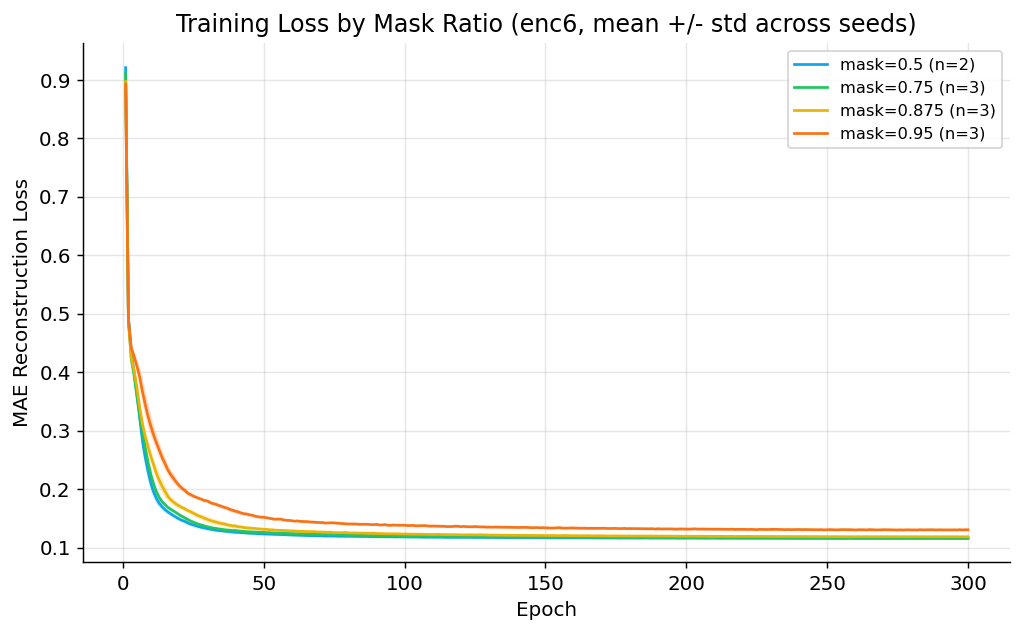

In [11]:
if ratio_enc6_groups:
    plot_loss_curve_by_group(
        ratio_enc6_groups, FIG_DIR, "ratio_loss_curve_enc6.png",
        title="Training Loss by Mask Ratio (enc6, mean +/- std across seeds)",
        colors=GROUP_COLORS, group_label_fmt="mask={k}",
    )

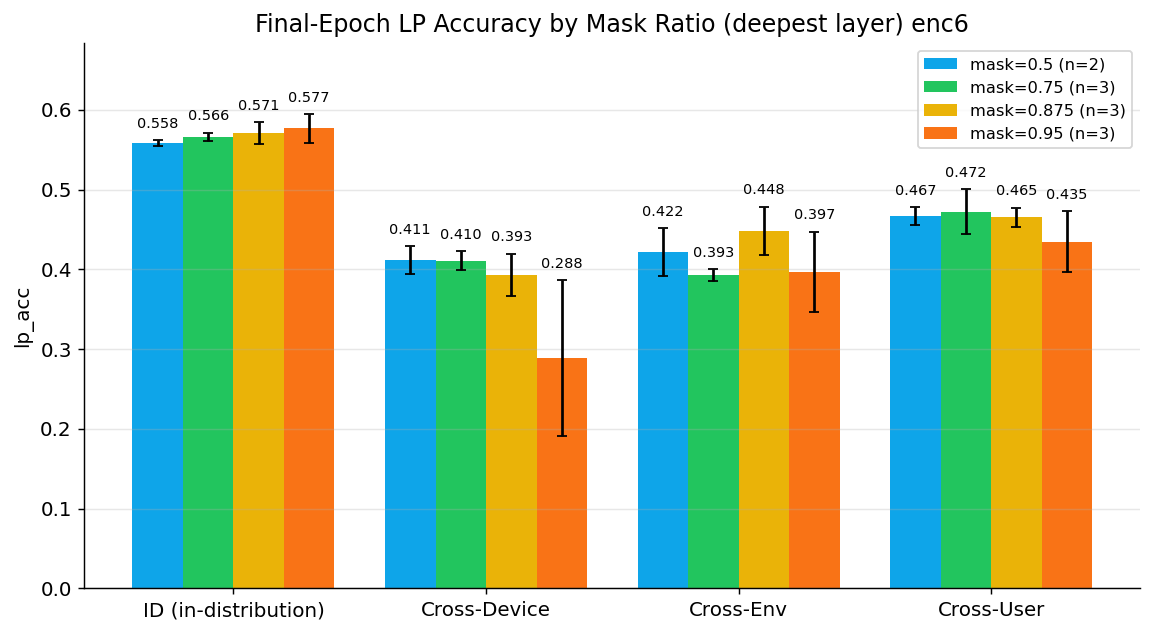

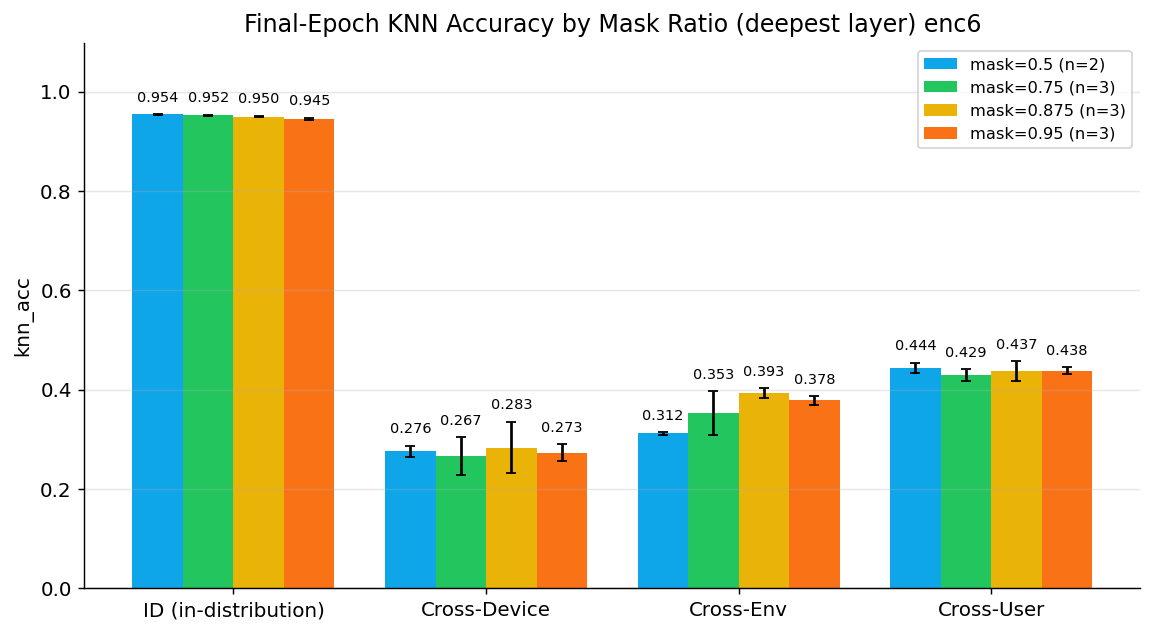

In [12]:
if ratio_enc6_groups:
    plot_final_accuracy_by_group(
        ratio_enc6_groups, FIG_DIR, "ratio_bar_lp_acc_enc6.png",
        title="Final-Epoch LP Accuracy by Mask Ratio (deepest layer) enc6",
        metric="lp_acc", colors=GROUP_COLORS, group_label_fmt="mask={k}",
    )
    plot_final_accuracy_by_group(
        ratio_enc6_groups, FIG_DIR, "ratio_bar_knn_acc_enc6.png",
        title="Final-Epoch KNN Accuracy by Mask Ratio (deepest layer) enc6",
        metric="knn_acc", colors=GROUP_COLORS, group_label_fmt="mask={k}",
    )

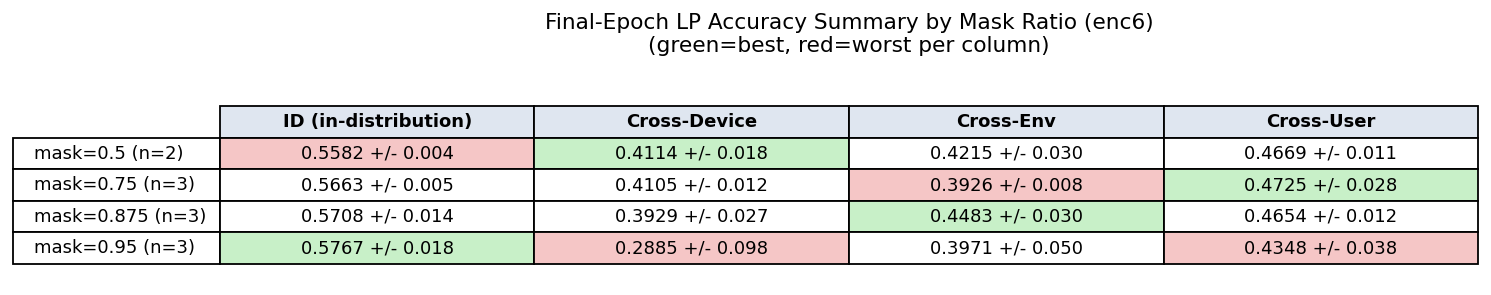

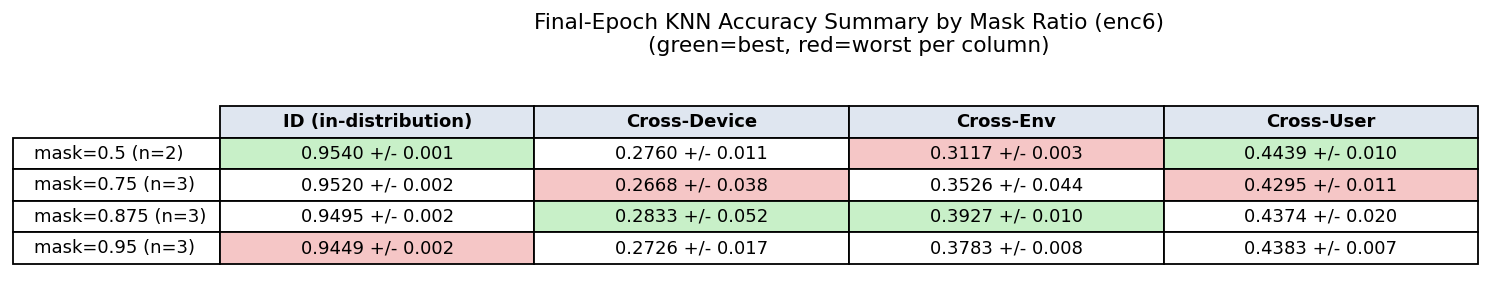


=== Summary: lp_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
mask=0.5              0.5582 +/- 0.004        0.4114 +/- 0.018        0.4215 +/- 0.030        0.4669 +/- 0.011
mask=0.75             0.5663 +/- 0.005        0.4105 +/- 0.012        0.3926 +/- 0.008        0.4725 +/- 0.028
mask=0.875            0.5708 +/- 0.014        0.3929 +/- 0.027        0.4483 +/- 0.030        0.4654 +/- 0.012
mask=0.95             0.5767 +/- 0.018        0.2885 +/- 0.098        0.3971 +/- 0.050        0.4348 +/- 0.038

=== Summary: knn_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
mask=0.5              0.9540 +/- 0.001        0.2760 +/- 0.011        0.3117 +/- 0.003        0.4439 +/- 0.010
mask=0.75             0.9520 +/- 0.002        0.2668 +/- 0.038        0.3526 +/- 0.044        0.4295 +/- 0.011
mask=0.875            0.9495 +/- 0.002 

In [13]:
if ratio_enc6_groups:
    plot_summary_table_image(
        ratio_enc6_groups, FIG_DIR, "ratio_table_lp_acc_enc6.png",
        title="Final-Epoch LP Accuracy Summary by Mask Ratio (enc6)",
        metric="lp_acc", group_label_fmt="mask={k}",
    )
    plot_summary_table_image(
        ratio_enc6_groups, FIG_DIR, "ratio_table_knn_enc6.png",
        title="Final-Epoch KNN Accuracy Summary by Mask Ratio (enc6)",
        metric="knn_acc", group_label_fmt="mask={k}",
    )
    print_summary_table(ratio_enc6_groups, metric="lp_acc", group_label_fmt="mask={k}")
    print_summary_table(ratio_enc6_groups, metric="knn_acc", group_label_fmt="mask={k}")

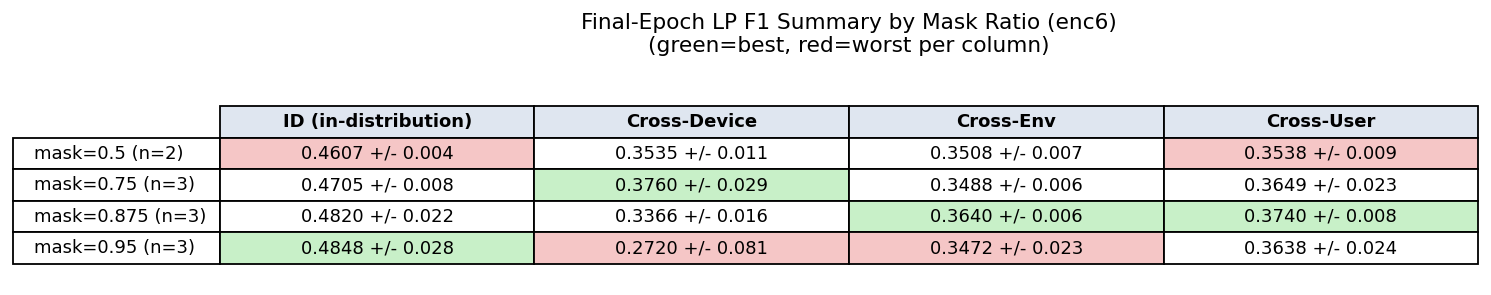

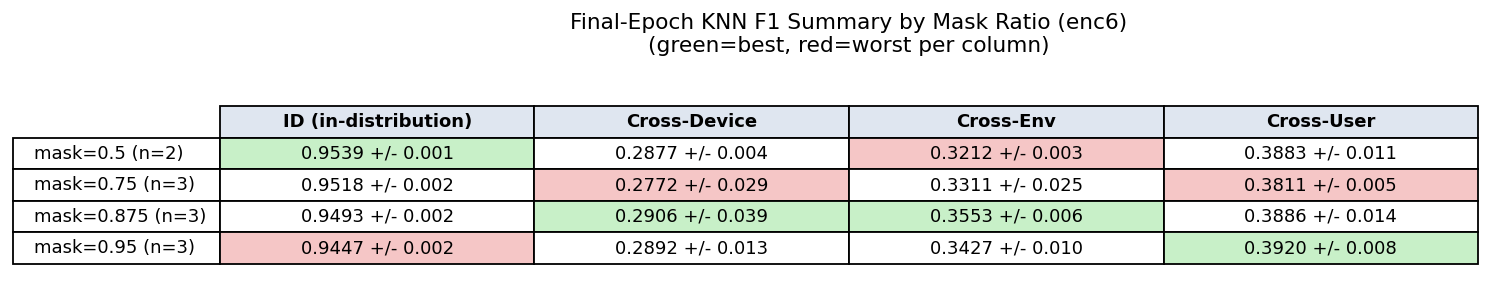


=== Summary: lp_f1 (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
mask=0.5              0.4607 +/- 0.004        0.3535 +/- 0.011        0.3508 +/- 0.007        0.3538 +/- 0.009
mask=0.75             0.4705 +/- 0.008        0.3760 +/- 0.029        0.3488 +/- 0.006        0.3649 +/- 0.023
mask=0.875            0.4820 +/- 0.022        0.3366 +/- 0.016        0.3640 +/- 0.006        0.3740 +/- 0.008
mask=0.95             0.4848 +/- 0.028        0.2720 +/- 0.081        0.3472 +/- 0.023        0.3638 +/- 0.024

=== Summary: knn_f1 (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
mask=0.5              0.9539 +/- 0.001        0.2877 +/- 0.004        0.3212 +/- 0.003        0.3883 +/- 0.011
mask=0.75             0.9518 +/- 0.002        0.2772 +/- 0.029        0.3311 +/- 0.025        0.3811 +/- 0.005
mask=0.875            0.9493 +/- 0.002   

In [14]:
if ratio_enc6_groups:
    plot_summary_table_image(
        ratio_enc6_groups, FIG_DIR, "ratio_table_lp_f1_enc6.png",
        title="Final-Epoch LP F1 Summary by Mask Ratio (enc6)",
        metric="lp_f1", group_label_fmt="mask={k}",
    )
    plot_summary_table_image(
        ratio_enc6_groups, FIG_DIR, "ratio_table_knn_f1_enc6.png",
        title="Final-Epoch KNN F1 Summary by Mask Ratio (enc6)",
        metric="knn_f1", group_label_fmt="mask={k}",
    )
    print_summary_table(ratio_enc6_groups, metric="lp_f1", group_label_fmt="mask={k}")
    print_summary_table(ratio_enc6_groups, metric="knn_f1", group_label_fmt="mask={k}")

**Per-ratio layer-wise probing.** For each mask ratio, plots KNN vs LP accuracy across encoder
layers 1/3/6 at the final checkpoint, using the first available seed as representative.

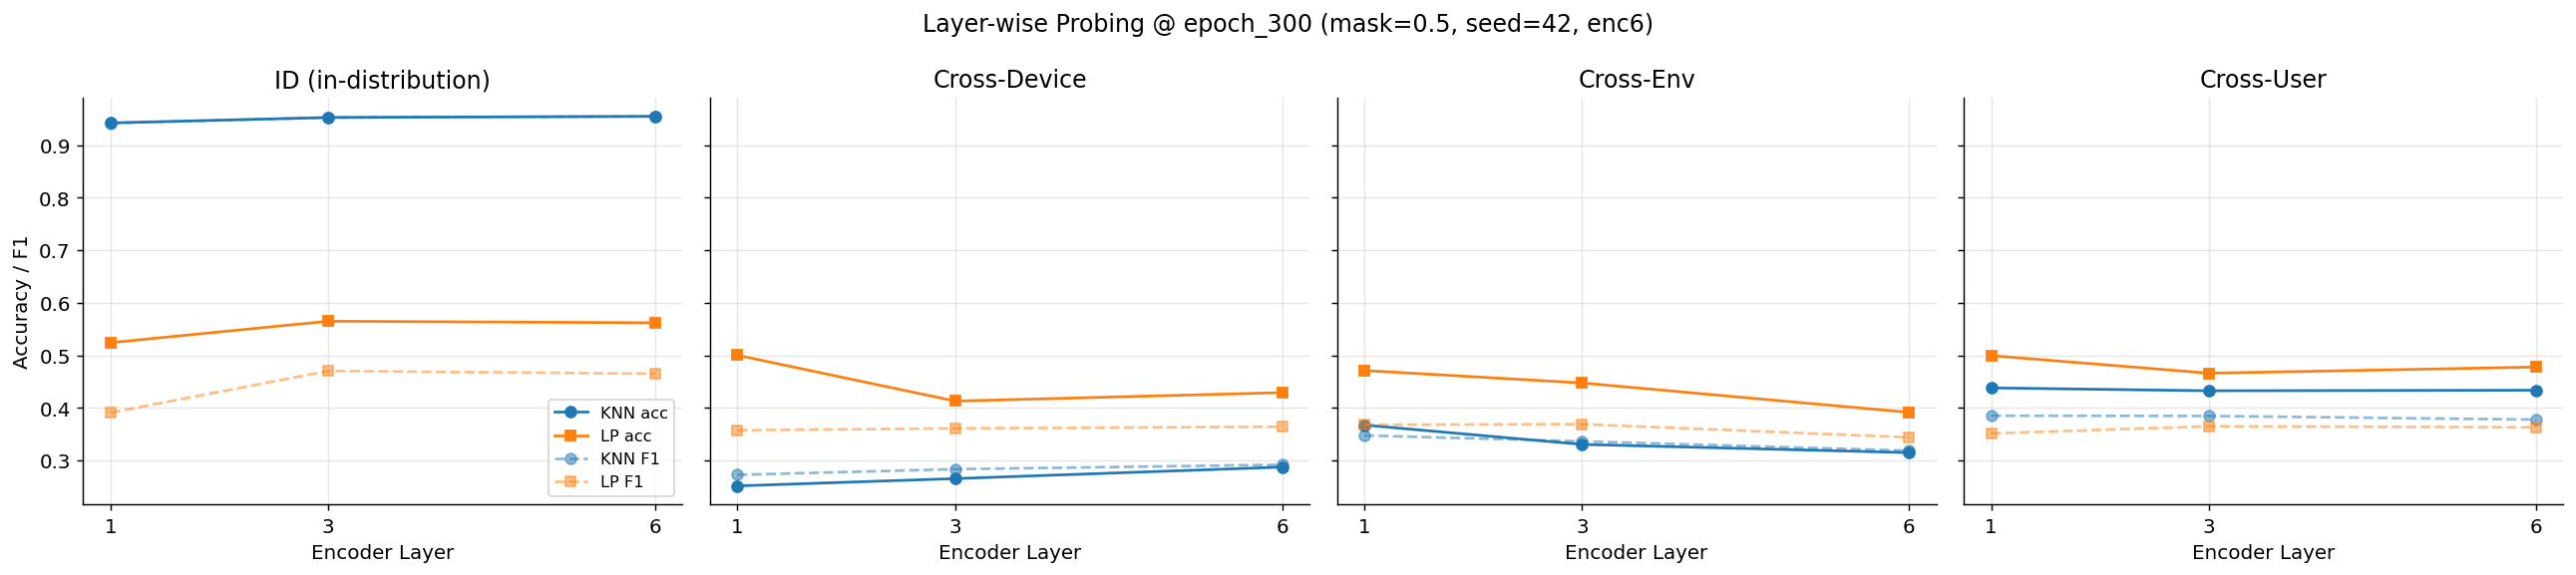

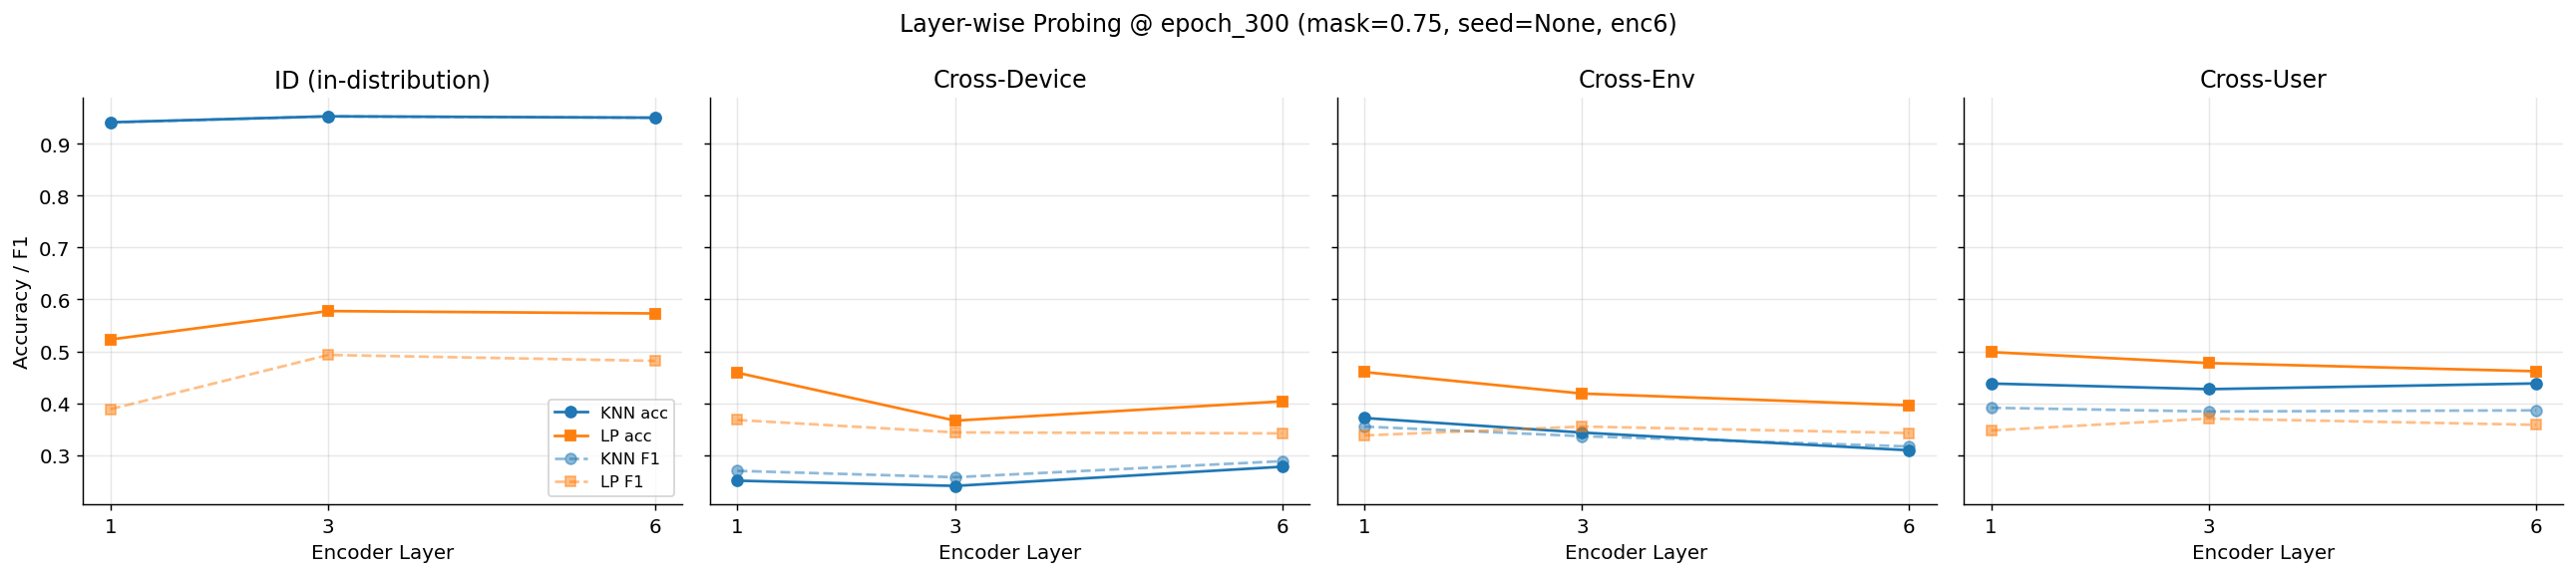

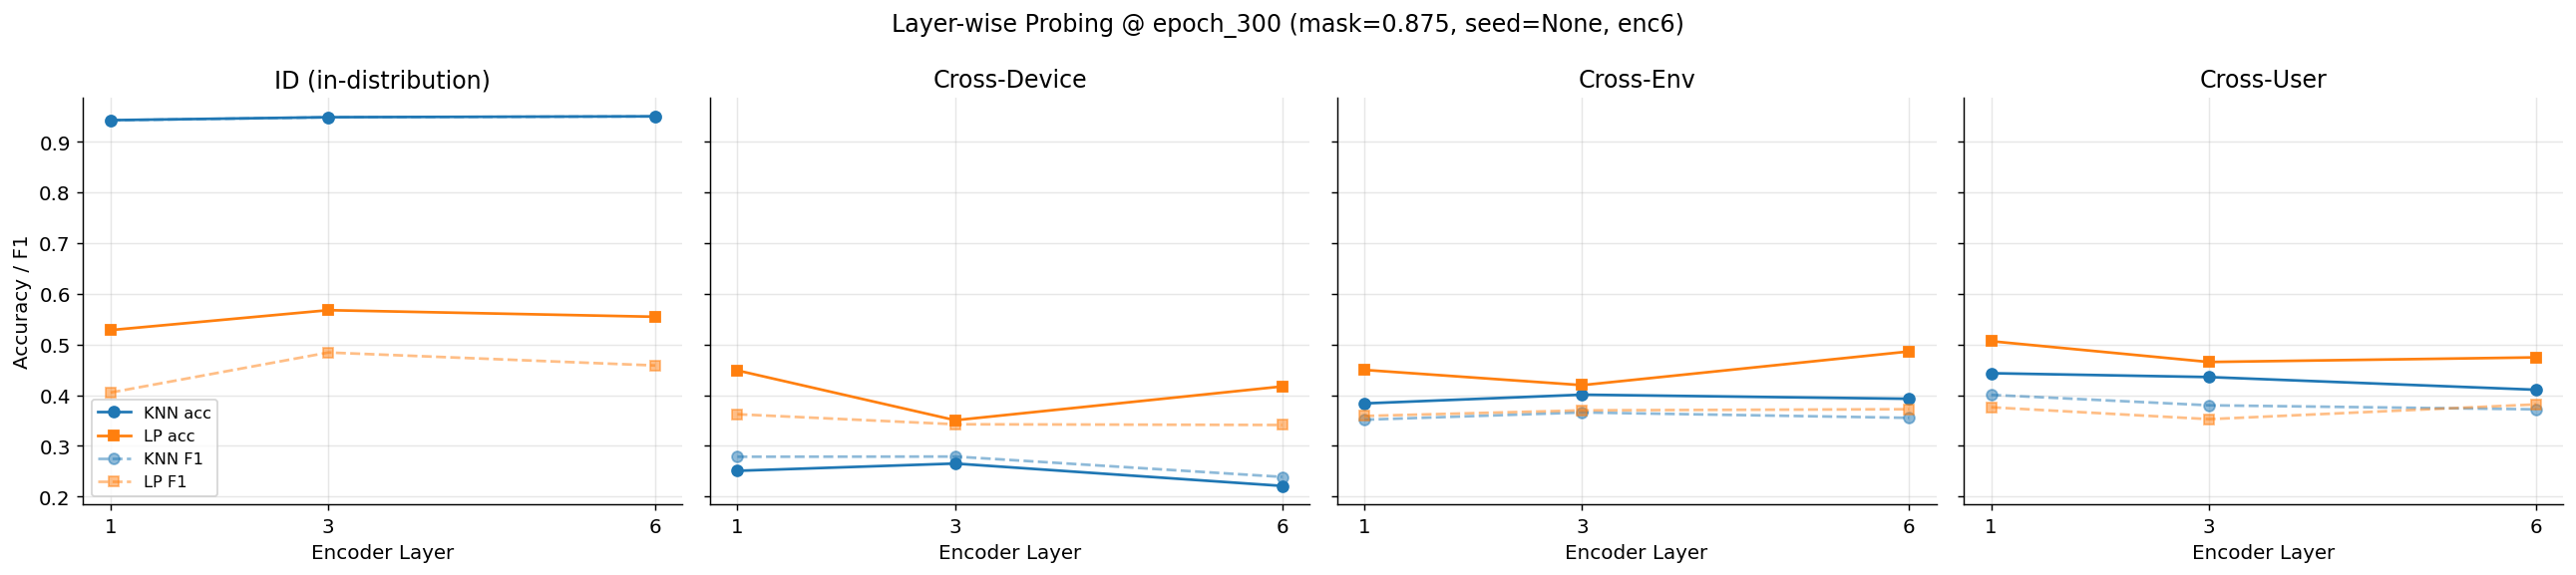

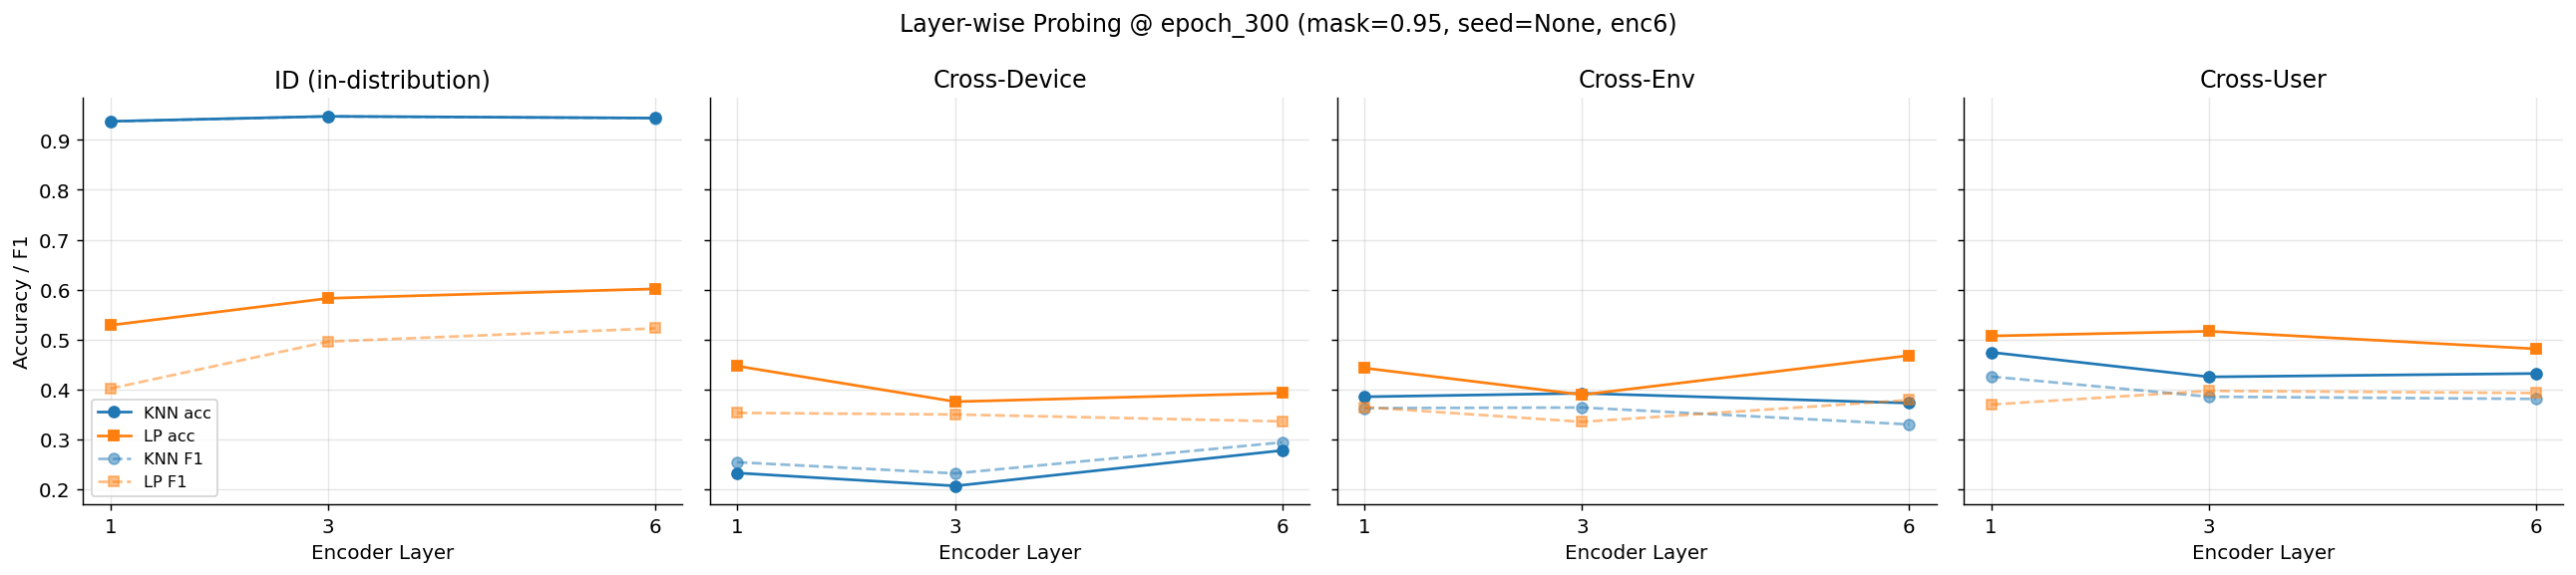

In [15]:
if ratio_enc6_groups:
    for ratio, runs in sorted(ratio_enc6_groups.items()):
        rep = runs[0]  # representative run (first available seed)
        plot_layer_probing(
            rep, FIG_DIR, f"ratio_layer_enc6_probing_mask{ratio}.png",
            title_suffix=f" (mask={ratio}, seed={rep['args'].get('seed')}, enc6)",
        )

**Epoch x layer heatmap** (mask_ratio=0.75, cross_device split) — shows whether LP saturation
happens at the same training epoch across layer depths, or whether deeper layers need longer to
converge, for enc6.

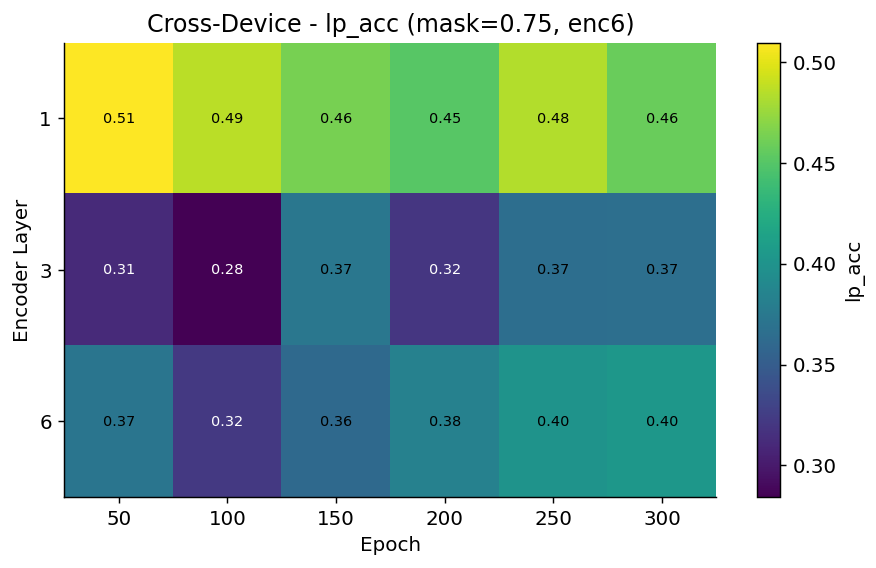

In [16]:
if 0.75 in ratio_enc6_groups:
    plot_epoch_layer_heatmap(
        ratio_enc6_groups[0.75][0], FIG_DIR, "ratio_heatmap_mask0.75_cross_device_enc6.png",
        split="test_cross_device", metric="lp_acc",
        title_suffix=" (mask=0.75, enc6)",
    )
else:
    print("mask_ratio=0.75 not found in ratio_enc6_groups -- skipping heatmap.")

## Section A — Mask Ratio Ablation (enc12 layer-probing)

Filters on `mask_strategy="random"`, `encoder_depth=12`, `patch_h=29`, `patch_w=25`, and groups by
`mask_ratio`. This is the currently-running enc12 layer-probing experiment (mask ratios x seeds x
eval_layers 1/3/6/9/12) — some (ratio, seed) combos may still be missing if that job hasn't finished yet,
which is expected and will just show up as a smaller `n` per ratio.

In [17]:
RATIO_FILTERS = {
    "mask_strategy": "random",
    "encoder_depth": 12,
    "patch_h": 29,
    "patch_w": 25,
}
DEBUG = False  # flip to True if 0 files match and you need to see why, per file

ratio_results = load_matching_results(RESULTS_DIR, RATIO_FILTERS, debug=DEBUG)
if not ratio_results:
    print("No mask-ratio-ablation (enc12) files matched. Set DEBUG=True above and re-run this cell.")
    ratio_groups = {}
else:
    ratio_groups = group_by(ratio_results, key_fn=lambda r: r["args"]["mask_ratio"])
    print(f"Found {len(ratio_results)} files across {len(ratio_groups)} mask ratios: "
          f"{ {k: len(v) for k, v in ratio_groups.items()} }")
    diagnose_incomplete_runs(ratio_results, "ratio")



Found 9 files across 4 mask ratios: {0.5: 2, 0.75: 3, 0.875: 2, 0.95: 2}
[ratio] all 9 run(s) have complete eval data across all checkpoints/layers/splits.


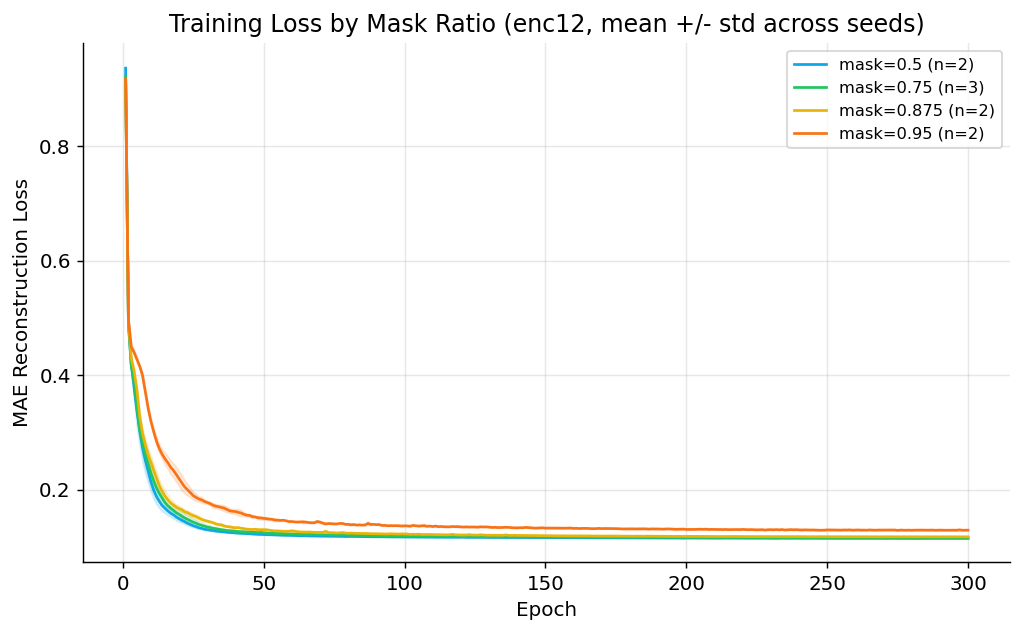

In [18]:
if ratio_groups:
    plot_loss_curve_by_group(
        ratio_groups, FIG_DIR, "ratio_loss_curve_enc12.png",
        title="Training Loss by Mask Ratio (enc12, mean +/- std across seeds)",
        colors=GROUP_COLORS, group_label_fmt="mask={k}",
    
    )

In [19]:
for ratio, runs in ratio_groups.items():
    for r in runs:
        final_ckpt = get_checkpoints(r)[-1]
        available_layers = list(r["evals"][final_ckpt].keys())
        if "layer_12" not in available_layers:
            print(f"[问题文件] mask_ratio={ratio}  exp={r['exp']}")
            print(f"  final_ckpt={final_ckpt}  实际有的layers={available_layers}")

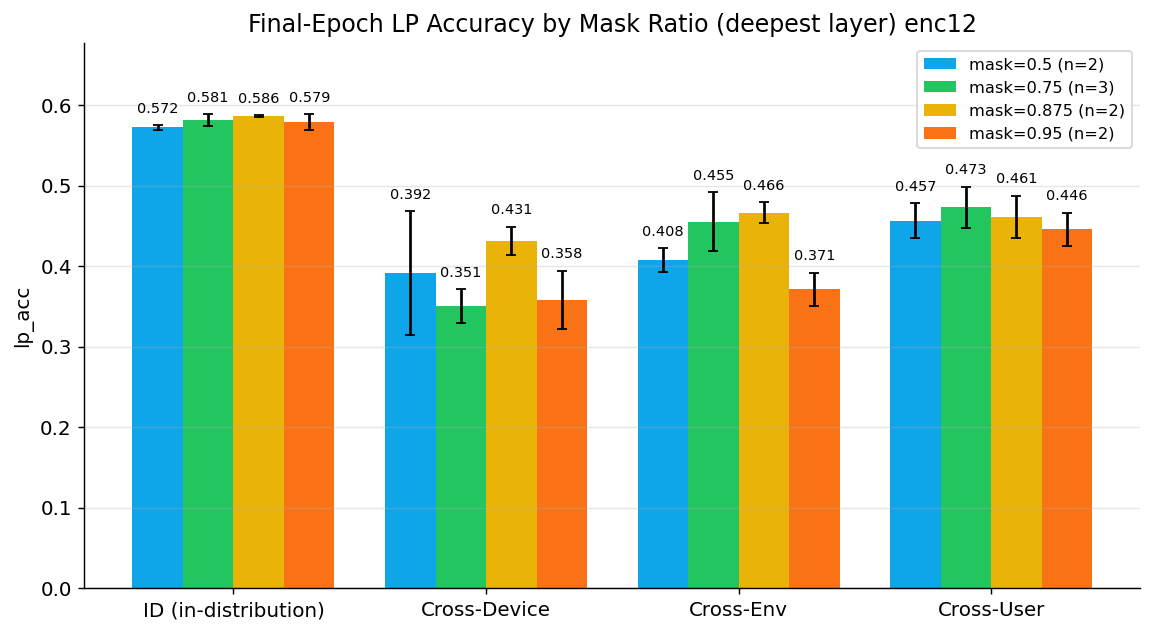

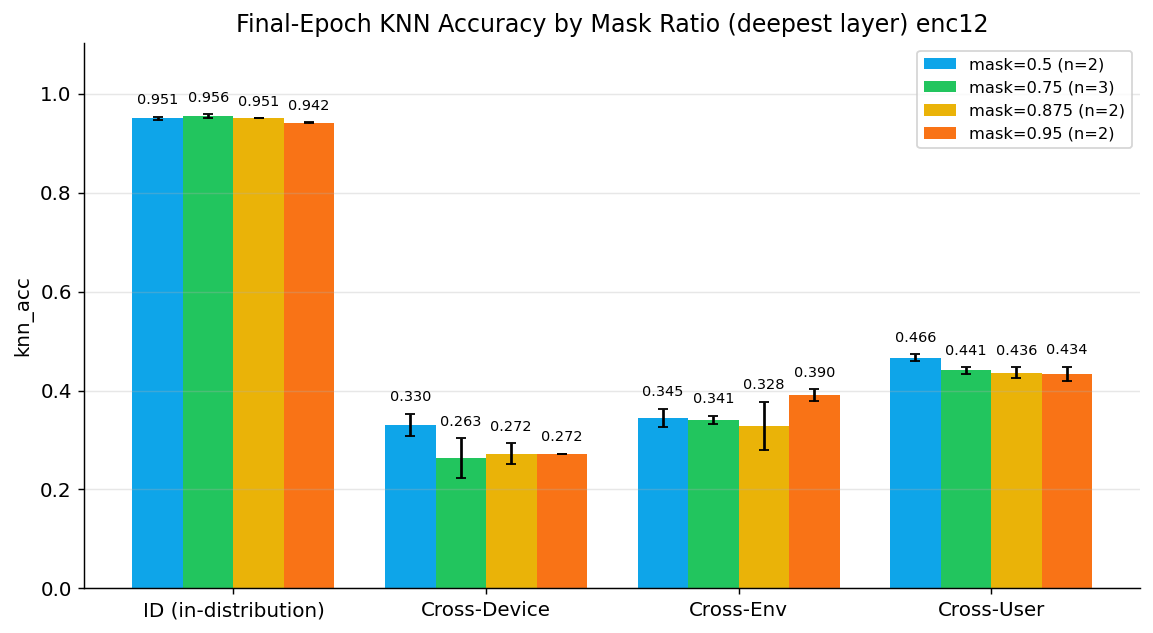

In [20]:
if ratio_groups:
    plot_final_accuracy_by_group(
        ratio_groups, FIG_DIR, "ratio_bar_lp_acc_enc12.png",
        title="Final-Epoch LP Accuracy by Mask Ratio (deepest layer) enc12",
        metric="lp_acc", colors=GROUP_COLORS, group_label_fmt="mask={k}",

    )
    plot_final_accuracy_by_group(
        ratio_groups, FIG_DIR, "ratio_bar_knn_acc_enc12.png",
        title="Final-Epoch KNN Accuracy by Mask Ratio (deepest layer) enc12",
        metric="knn_acc", colors=GROUP_COLORS, group_label_fmt="mask={k}",
    
    )

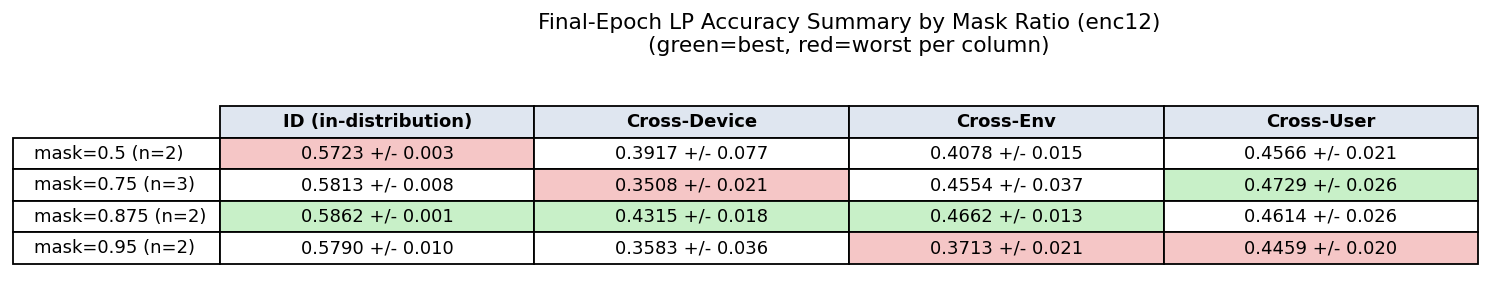

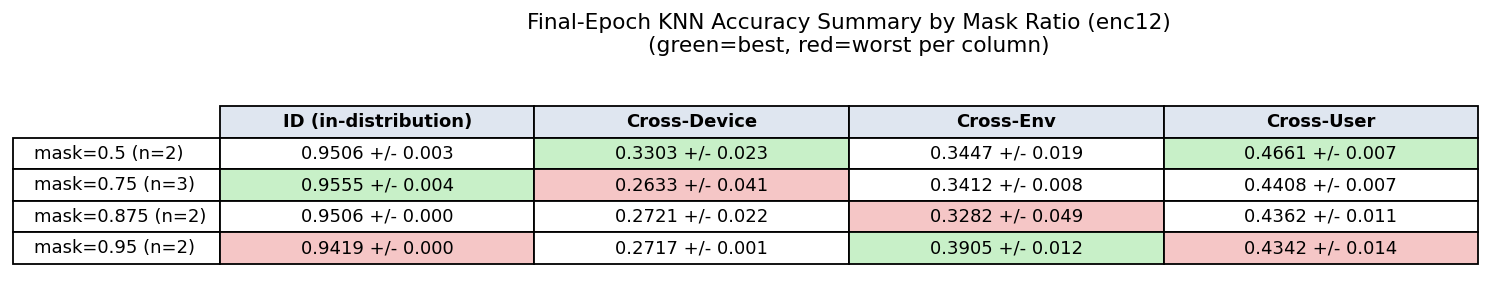


=== Summary: lp_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
mask=0.5              0.5723 +/- 0.003        0.3917 +/- 0.077        0.4078 +/- 0.015        0.4566 +/- 0.021
mask=0.75             0.5813 +/- 0.008        0.3508 +/- 0.021        0.4554 +/- 0.037        0.4729 +/- 0.026
mask=0.875            0.5862 +/- 0.001        0.4315 +/- 0.018        0.4662 +/- 0.013        0.4614 +/- 0.026
mask=0.95             0.5790 +/- 0.010        0.3583 +/- 0.036        0.3713 +/- 0.021        0.4459 +/- 0.020

=== Summary: knn_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
mask=0.5              0.9506 +/- 0.003        0.3303 +/- 0.023        0.3447 +/- 0.019        0.4661 +/- 0.007
mask=0.75             0.9555 +/- 0.004        0.2633 +/- 0.041        0.3412 +/- 0.008        0.4408 +/- 0.007
mask=0.875            0.9506 +/- 0.000 

In [21]:
if ratio_groups:
    plot_summary_table_image(
        ratio_groups, FIG_DIR, "ratio_table_lp_acc_enc12.png",
        title="Final-Epoch LP Accuracy Summary by Mask Ratio (enc12)",
        metric="lp_acc", group_label_fmt="mask={k}",
    )

    plot_summary_table_image(
        ratio_groups, FIG_DIR, "ratio_table_knn_enc12.png",
        title="Final-Epoch KNN Accuracy Summary by Mask Ratio (enc12)",
        metric="knn_acc", group_label_fmt="mask={k}",
    )
    print_summary_table(ratio_groups, metric="lp_acc", group_label_fmt="mask={k}")
    print_summary_table(ratio_groups, metric="knn_acc", group_label_fmt="mask={k}")

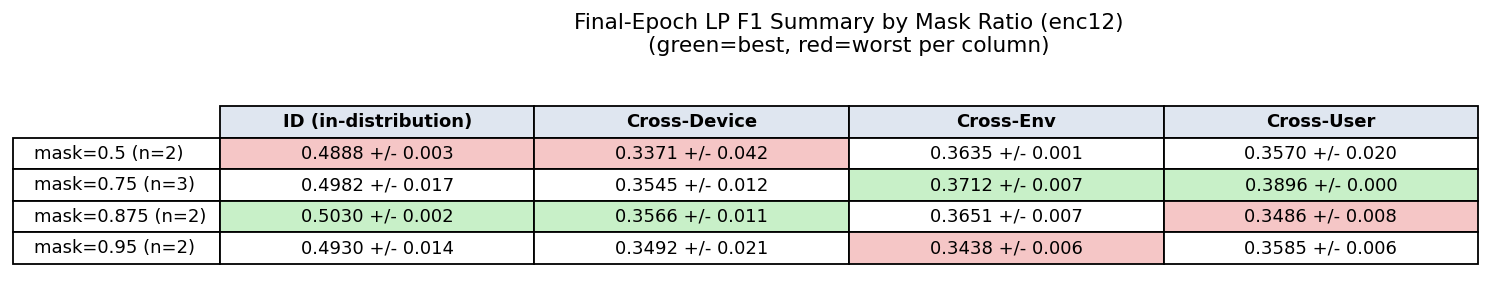

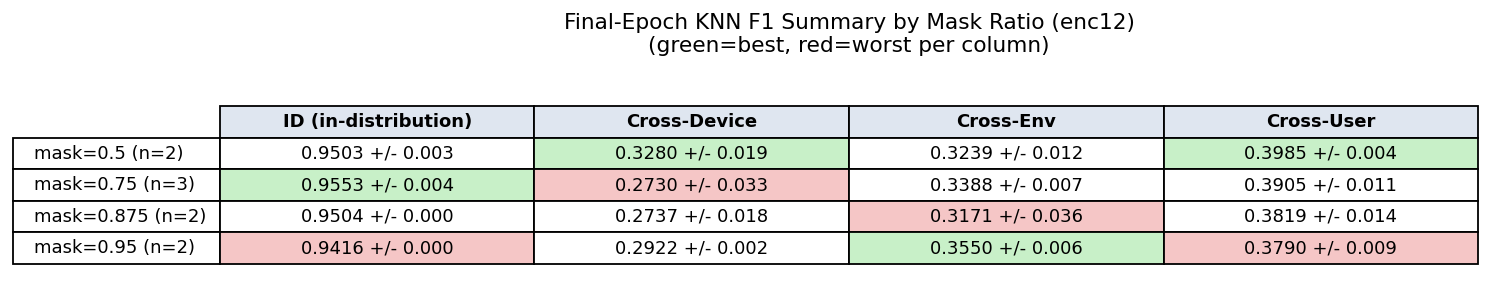


=== Summary: lp_f1 (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
mask=0.5              0.4888 +/- 0.003        0.3371 +/- 0.042        0.3635 +/- 0.001        0.3570 +/- 0.020
mask=0.75             0.4982 +/- 0.017        0.3545 +/- 0.012        0.3712 +/- 0.007        0.3896 +/- 0.000
mask=0.875            0.5030 +/- 0.002        0.3566 +/- 0.011        0.3651 +/- 0.007        0.3486 +/- 0.008
mask=0.95             0.4930 +/- 0.014        0.3492 +/- 0.021        0.3438 +/- 0.006        0.3585 +/- 0.006

=== Summary: knn_f1 (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
mask=0.5              0.9503 +/- 0.003        0.3280 +/- 0.019        0.3239 +/- 0.012        0.3985 +/- 0.004
mask=0.75             0.9553 +/- 0.004        0.2730 +/- 0.033        0.3388 +/- 0.007        0.3905 +/- 0.011
mask=0.875            0.9504 +/- 0.000   

In [22]:
if ratio_groups:
    plot_summary_table_image(
        ratio_groups, FIG_DIR, "ratio_table_lp_f1_enc12.png",
        title="Final-Epoch LP F1 Summary by Mask Ratio (enc12)",
        metric="lp_f1", group_label_fmt="mask={k}",
    )

    plot_summary_table_image(
        ratio_groups, FIG_DIR, "ratio_table_knn_f1_enc12.png",
        title="Final-Epoch KNN F1 Summary by Mask Ratio (enc12)",
        metric="knn_f1", group_label_fmt="mask={k}",
    )
    print_summary_table(ratio_groups, metric="lp_f1", group_label_fmt="mask={k}")
    print_summary_table(ratio_groups, metric="knn_f1", group_label_fmt="mask={k}")

**Per-ratio layer-wise probing.** For each mask ratio, plots KNN vs LP accuracy across encoder
layers 1/3/6/9/12 at the final checkpoint, using the first available seed as representative.

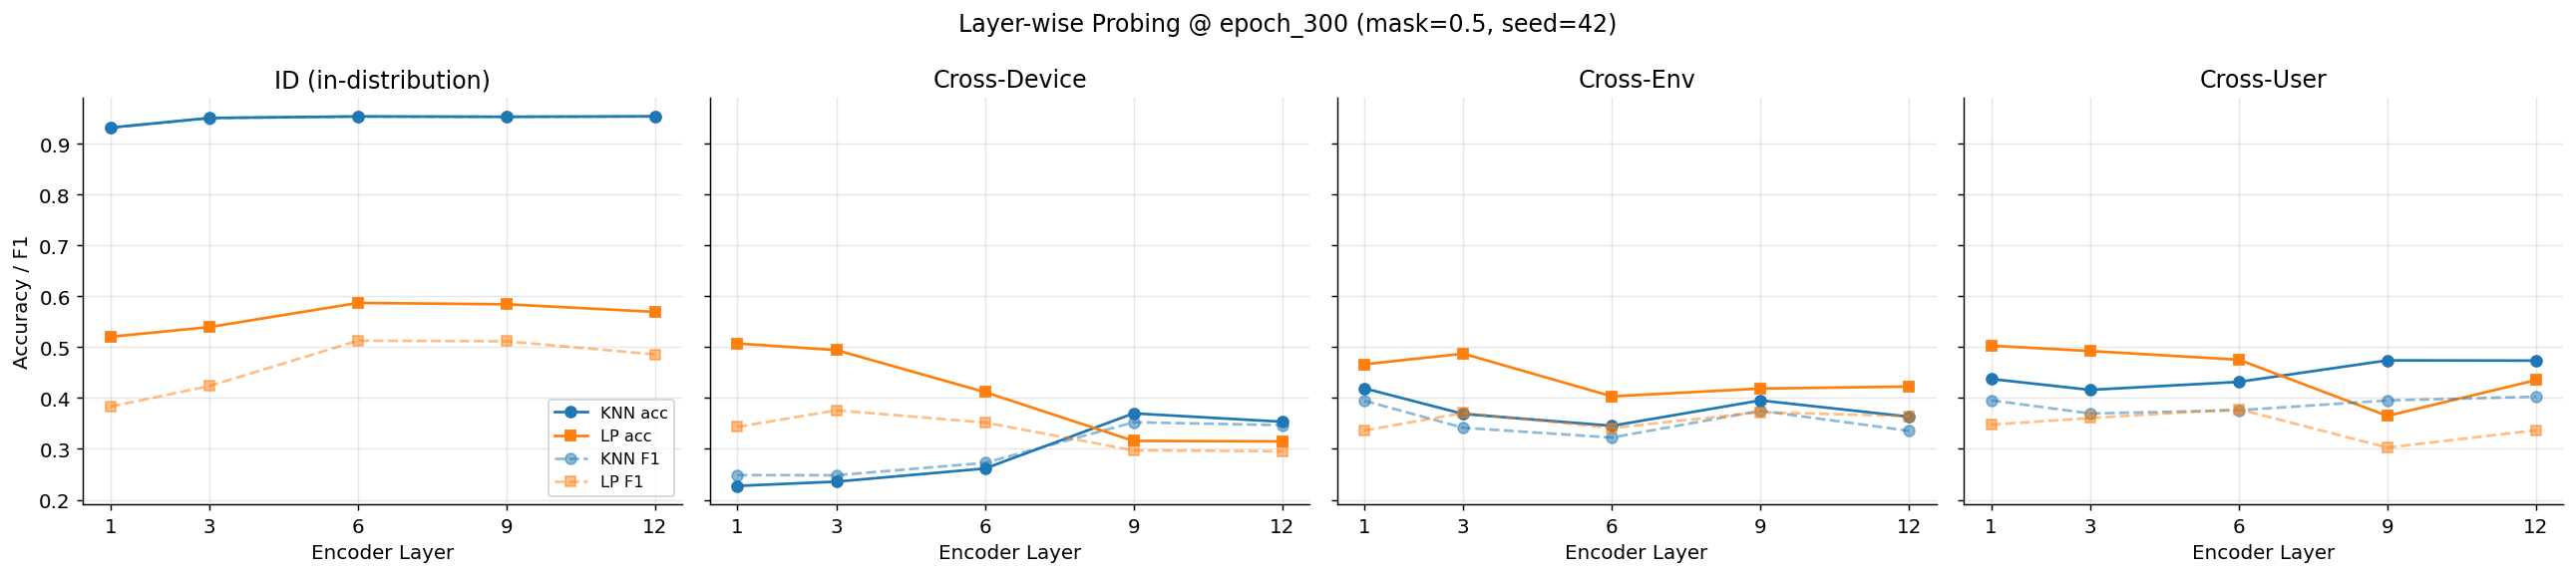

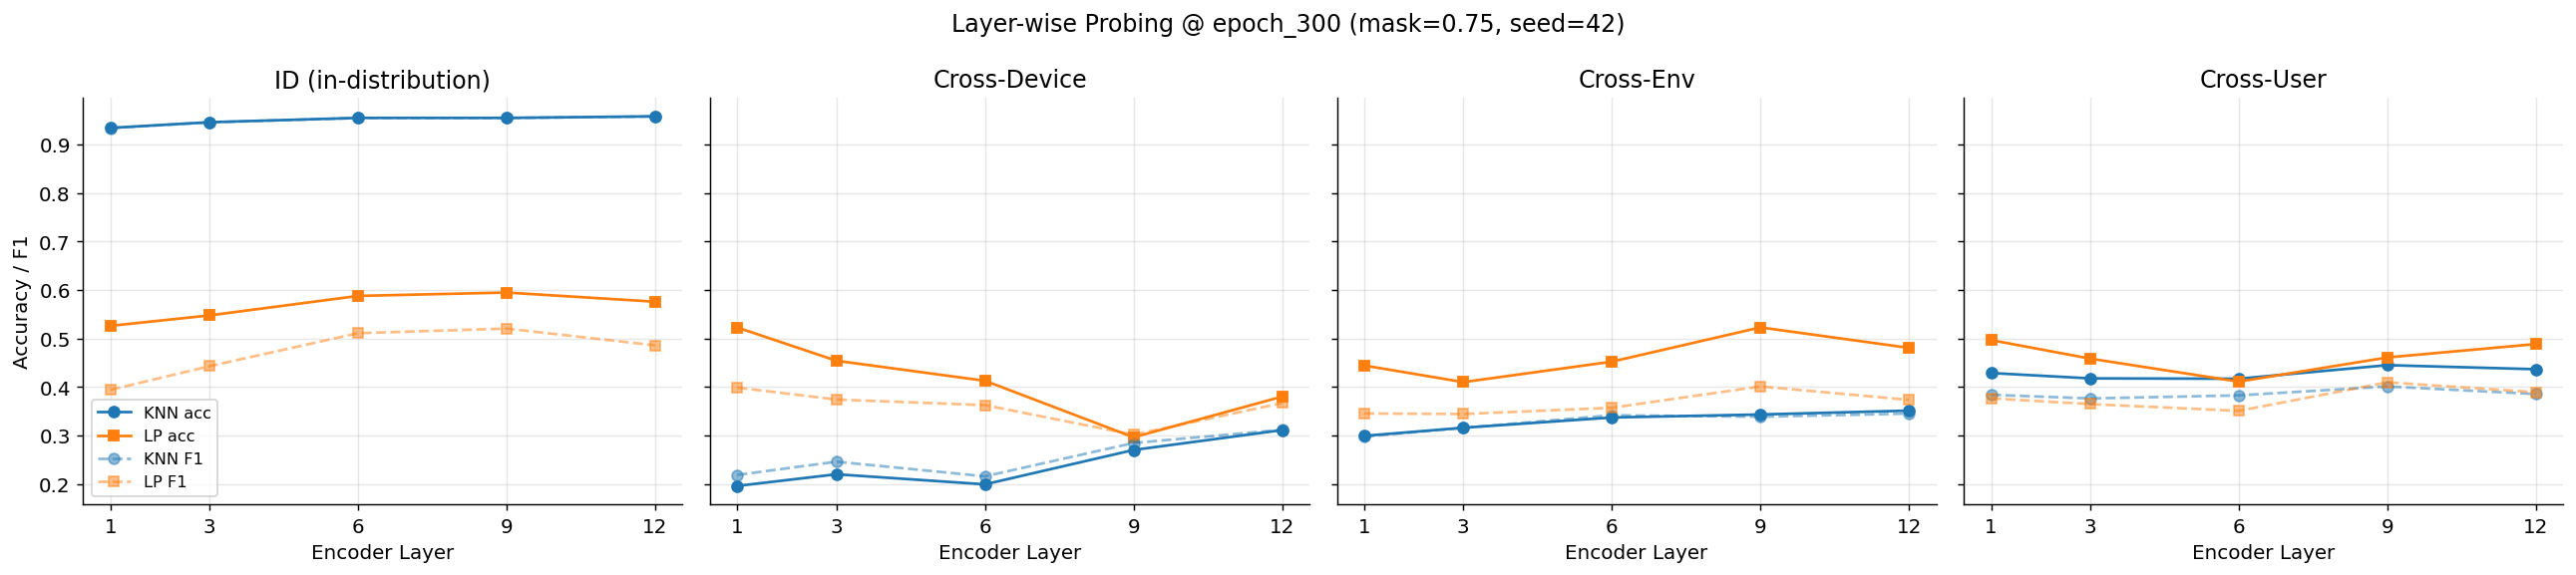

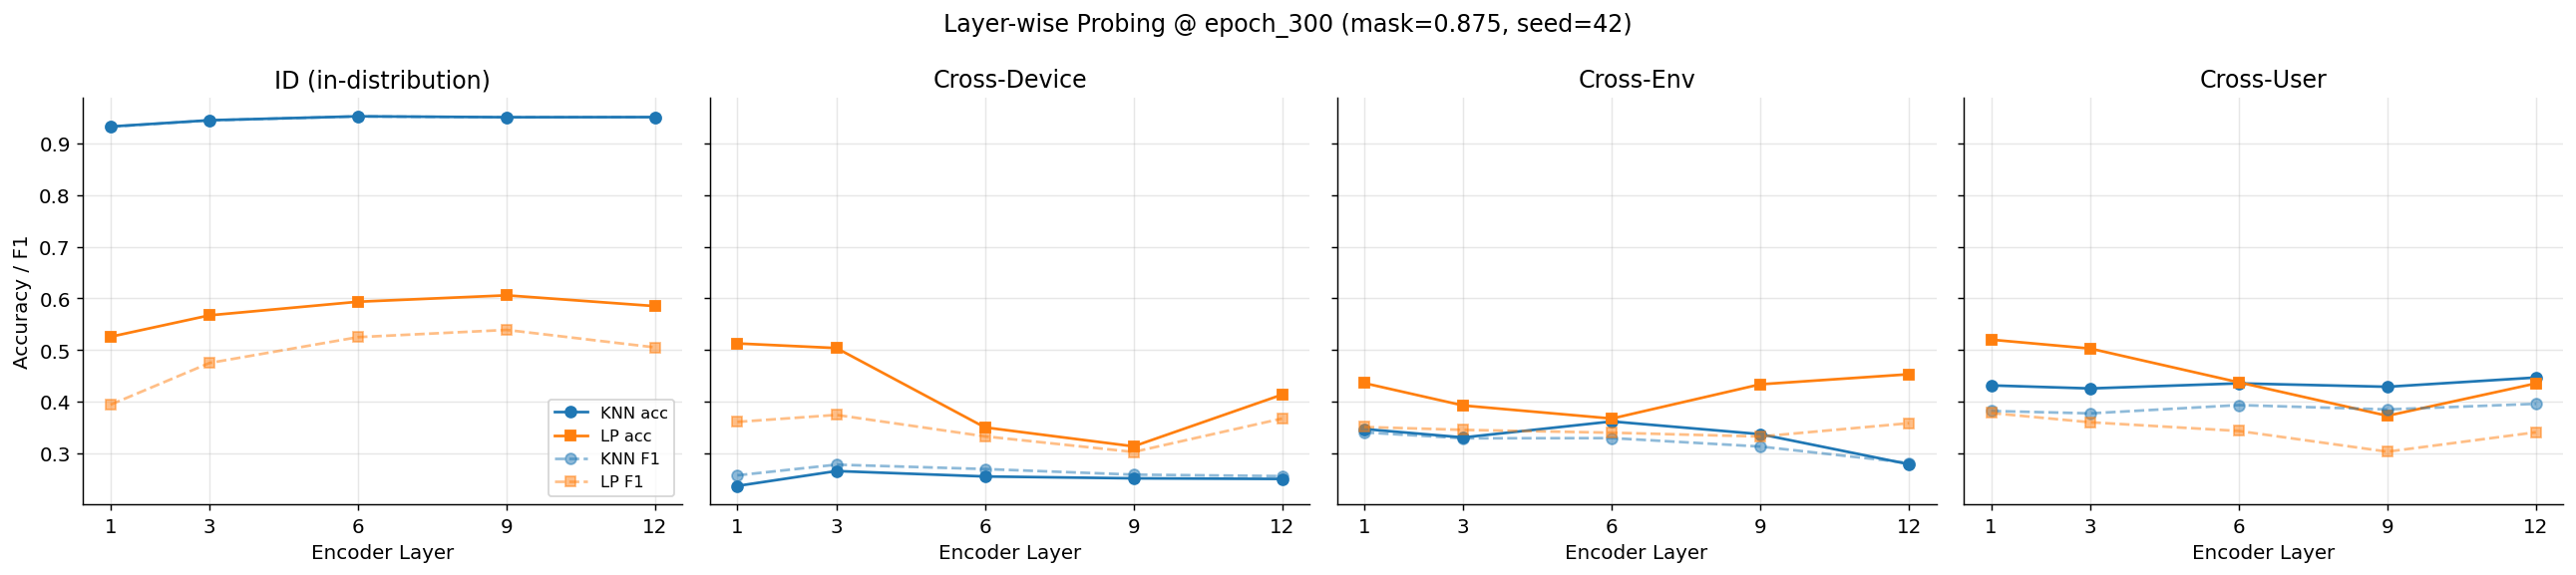

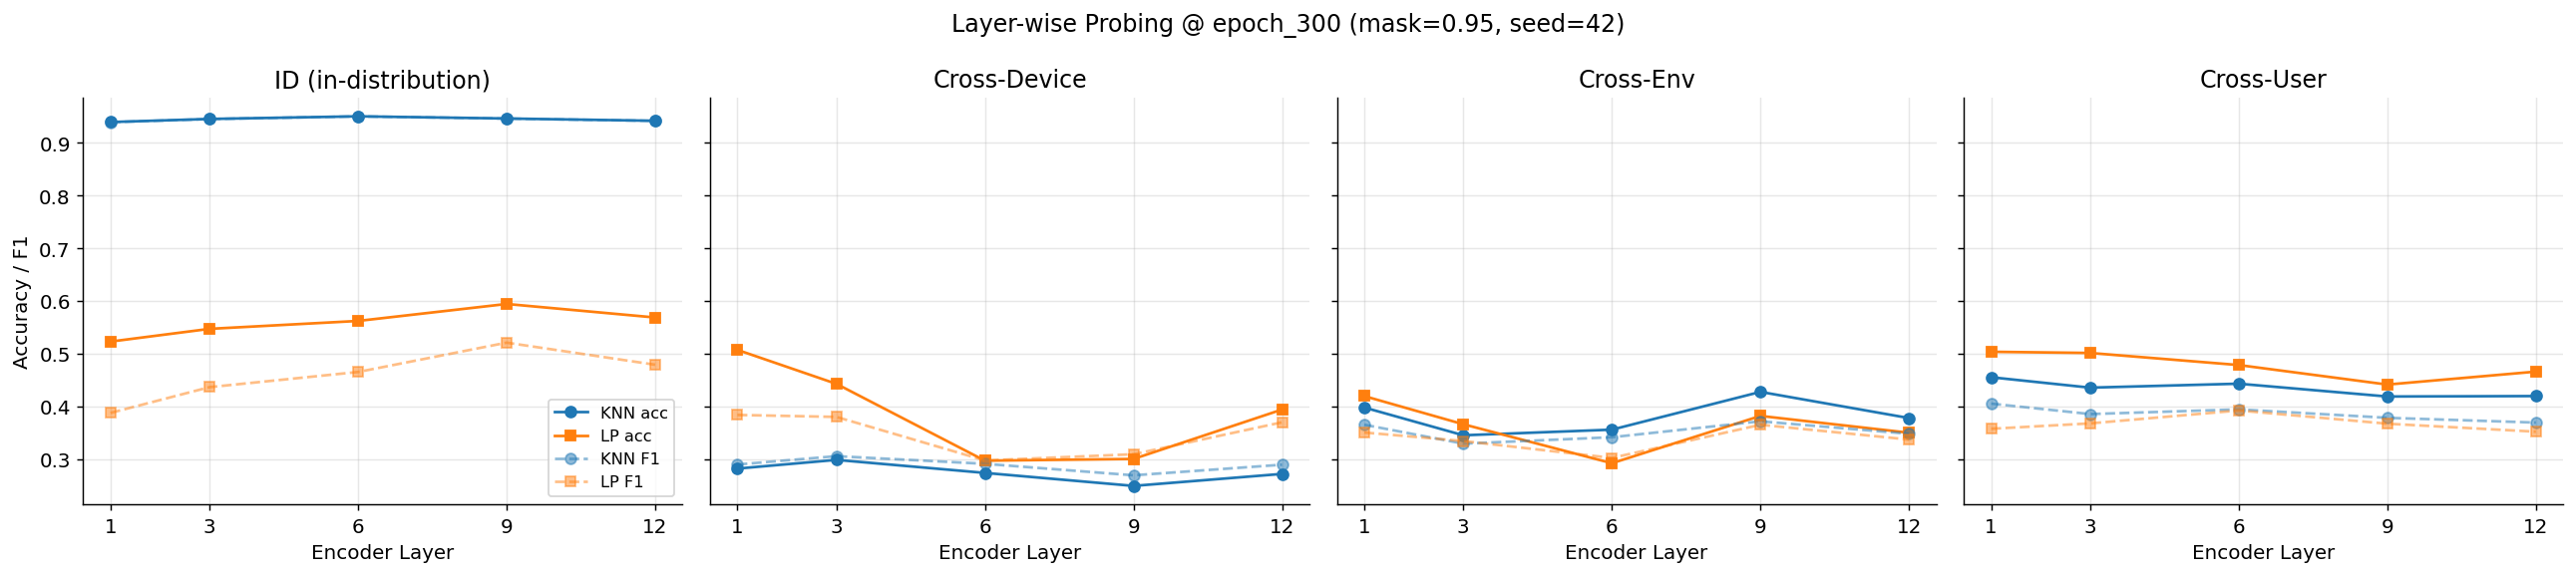

In [23]:
if ratio_groups:
    for ratio, runs in sorted(ratio_groups.items()):
        rep = runs[0]  # representative run (first available seed)
        plot_layer_probing(
            rep, FIG_DIR, f"ratio_layer_enc12_probing_mask{ratio}.png",
            title_suffix=f" (mask={ratio}, seed={rep['args'].get('seed')})",
        )

**Epoch x layer heatmap** (mask_ratio=0.75, cross_device split) — shows whether LP saturation
happens at the same training epoch across layer depths, or whether deeper layers need longer to converge.

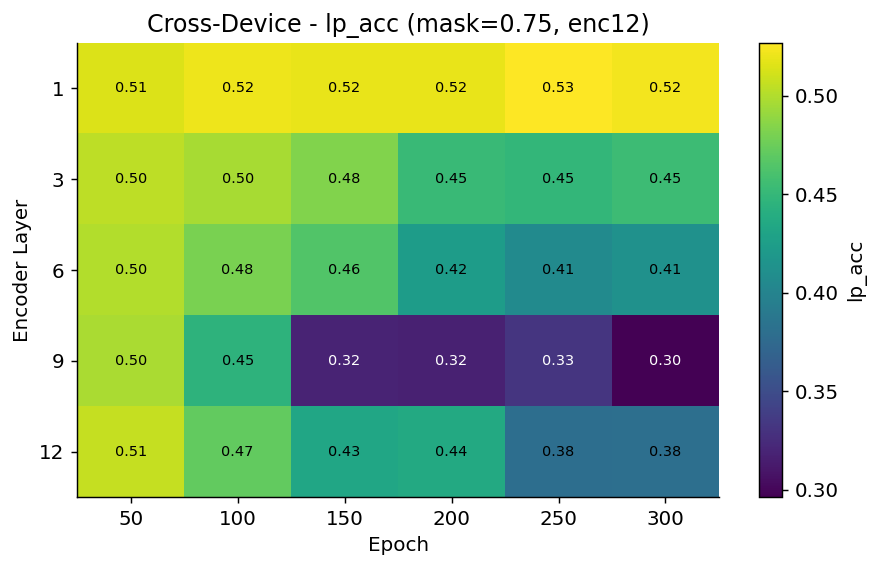

In [24]:
if 0.75 in ratio_groups:
    plot_epoch_layer_heatmap(
        ratio_groups[0.75][0], FIG_DIR, "ratio_heatmap_mask0.75_cross_device_enc12.png",
        split="test_cross_device", metric="lp_acc",
        title_suffix=" (mask=0.75, enc12)",
    )
else:
    print("mask_ratio=0.75 not found in ratio_groups -- skipping heatmap.")

## Section B — Mask Strategy Ablation (enc6, mask_ratio=0.75)

Filters on `mask_ratio=0.75`, `encoder_depth=6`, `patch_h=29`, `patch_w=25`, and groups by
`mask_strategy` (random / freq / mixed / time).

In [25]:
STRATEGY_FILTERS = {
    "mask_ratio": 0.75,
    "encoder_depth": 6,
    "patch_h": 29,
    "patch_w": 25,
}

strategy_results = load_matching_results(RESULTS_DIR, STRATEGY_FILTERS, debug=DEBUG)
if not strategy_results:
    print("No mask-strategy-ablation (enc6, mask=0.75) files matched. Set DEBUG=True above and re-run.")
    strategy_groups = {}
else:
    strategy_groups = group_by(strategy_results, key_fn=lambda r: r["args"]["mask_strategy"])
    print(f"Found {len(strategy_results)} files across {len(strategy_groups)} strategies: "
          f"{ {k: len(v) for k, v in strategy_groups.items()} }")
    diagnose_incomplete_runs(strategy_results, "strategy")

# STRATEGY_COLORS = {"random": "tab:blue", "freq": "tab:green", "mixed": "tab:orange", "time": "tab:red"}
STRATEGY_COLORS = {"random": "#0EA5E9", "freq": "#22C55E", "mixed": "#EAB308", "time": "#F97316"}

Found 11 files across 5 strategies: {'2d': 2, 'freq': 2, 'mixed': 2, 'random': 3, 'time': 2}
[strategy] all 11 run(s) have complete eval data across all checkpoints/layers/splits.


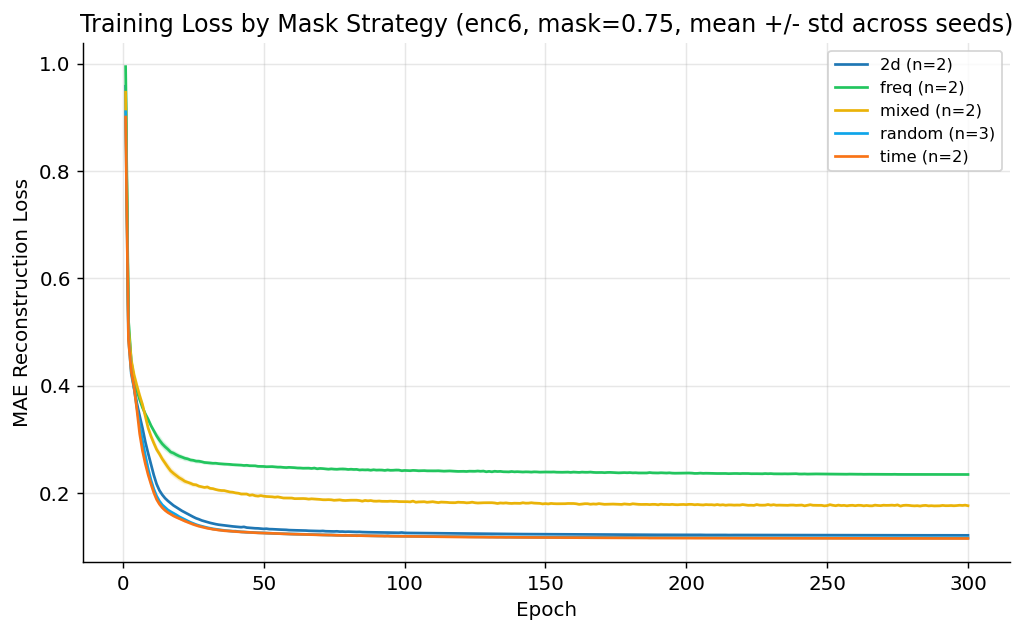

In [26]:
if strategy_groups:
    plot_loss_curve_by_group(
        strategy_groups, FIG_DIR, "strategy_loss_curve_enc6.png",
        title="Training Loss by Mask Strategy (enc6, mask=0.75, mean +/- std across seeds)",
        colors=STRATEGY_COLORS,
    )

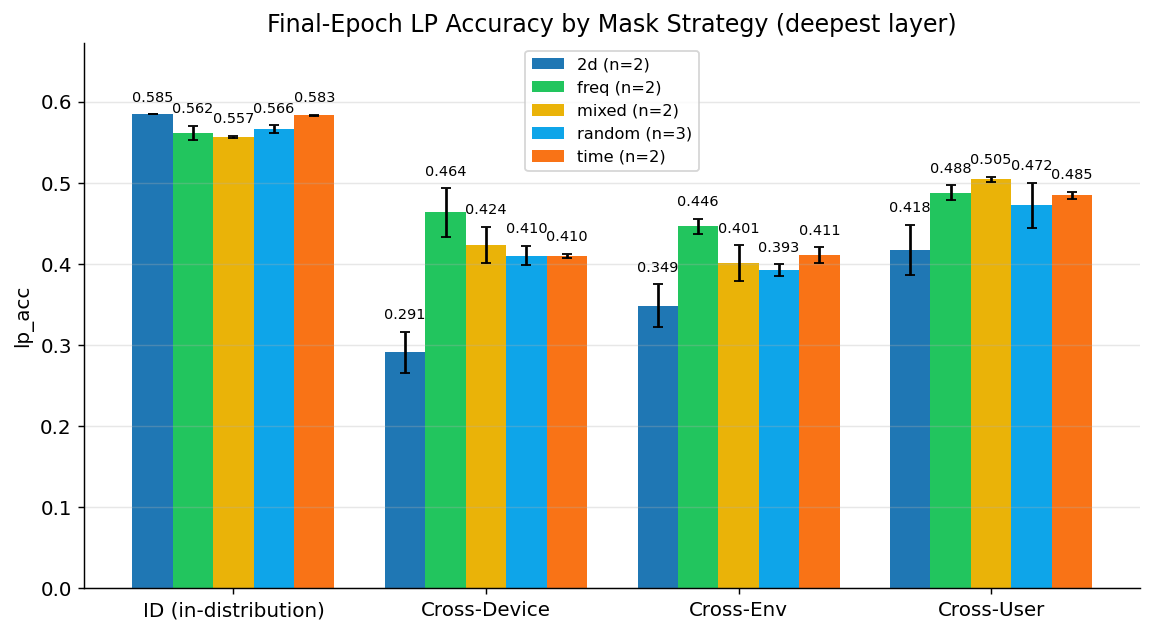

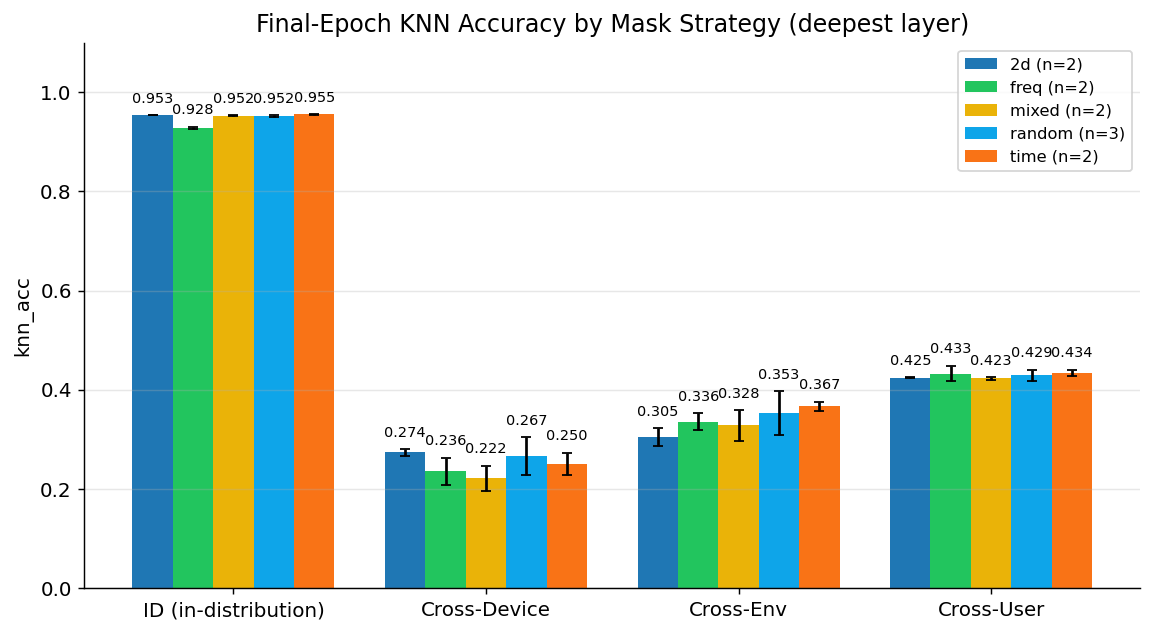

In [27]:
if strategy_groups:
    plot_final_accuracy_by_group(
        strategy_groups, FIG_DIR, "strategy_bar_lp_acc_enc6.png",
        title="Final-Epoch LP Accuracy by Mask Strategy (deepest layer)",
        metric="lp_acc", colors=STRATEGY_COLORS,
    )
    plot_final_accuracy_by_group(
        strategy_groups, FIG_DIR, "strategy_bar_knn_acc_enc6.png",
        title="Final-Epoch KNN Accuracy by Mask Strategy (deepest layer)",
        metric="knn_acc", colors=STRATEGY_COLORS,
    )

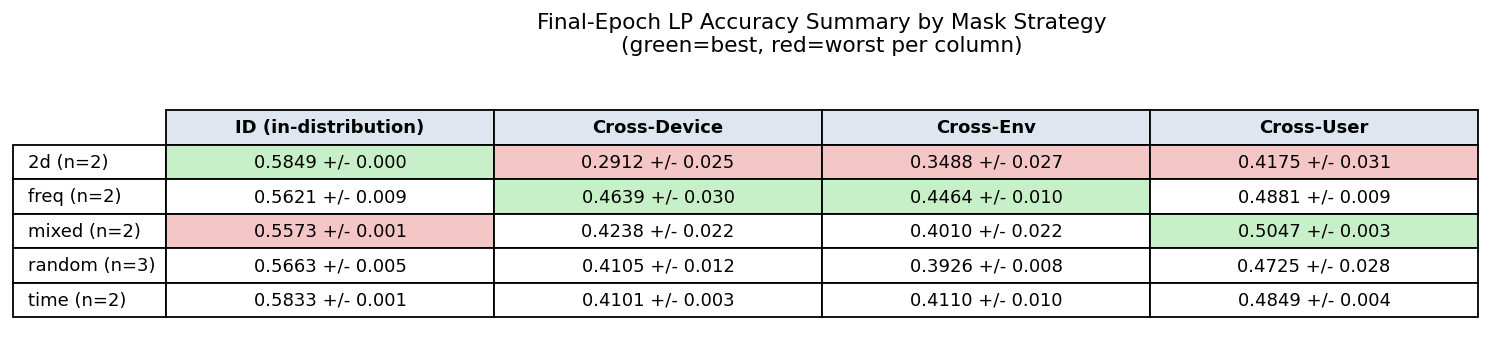

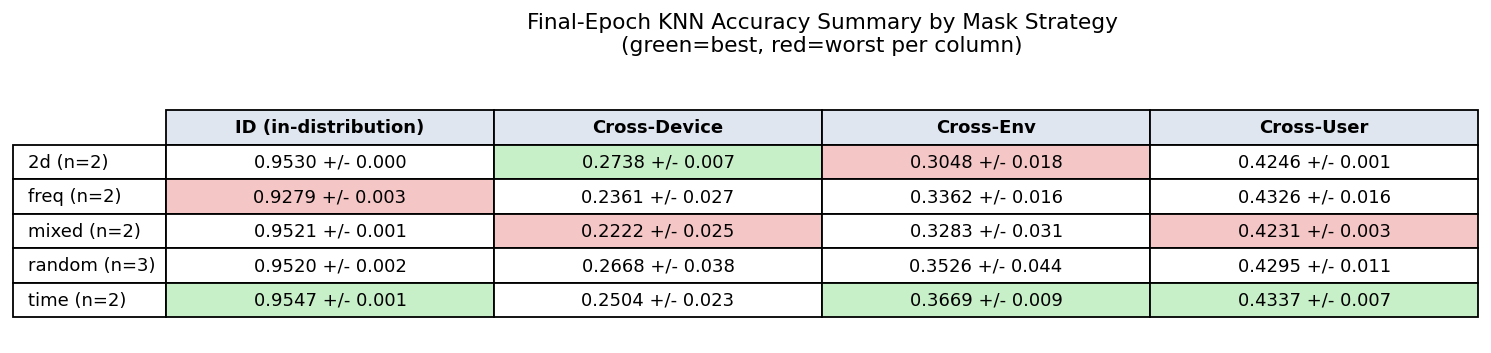


=== Summary: lp_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
2d                    0.5849 +/- 0.000        0.2912 +/- 0.025        0.3488 +/- 0.027        0.4175 +/- 0.031
freq                  0.5621 +/- 0.009        0.4639 +/- 0.030        0.4464 +/- 0.010        0.4881 +/- 0.009
mixed                 0.5573 +/- 0.001        0.4238 +/- 0.022        0.4010 +/- 0.022        0.5047 +/- 0.003
random                0.5663 +/- 0.005        0.4105 +/- 0.012        0.3926 +/- 0.008        0.4725 +/- 0.028
time                  0.5833 +/- 0.001        0.4101 +/- 0.003        0.4110 +/- 0.010        0.4849 +/- 0.004

=== Summary: knn_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
2d                    0.9530 +/- 0.000        0.2738 +/- 0.007        0.3048 +/- 0.018        0.4246 +/- 0.001
freq                  0.9279 +/- 0.003 

In [28]:
if strategy_groups:
    plot_summary_table_image(
        strategy_groups, FIG_DIR, "strategy_table_lp_acc_enc6.png",
        title="Final-Epoch LP Accuracy Summary by Mask Strategy",
        metric="lp_acc",
    )
    plot_summary_table_image(
        strategy_groups, FIG_DIR, "strategy_table_knn_acc_enc6.png",
        title="Final-Epoch KNN Accuracy Summary by Mask Strategy",
        metric="knn_acc",
    )
    print_summary_table(strategy_groups, metric="lp_acc")
    print_summary_table(strategy_groups, metric="knn_acc")

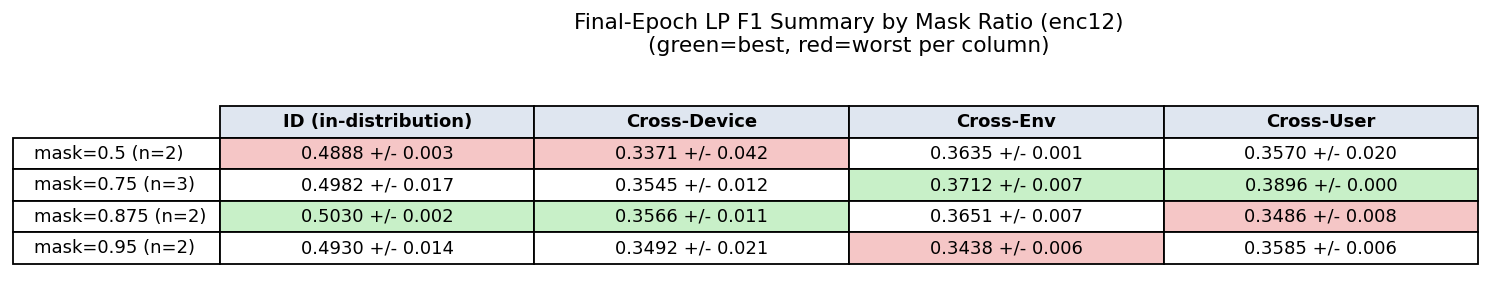

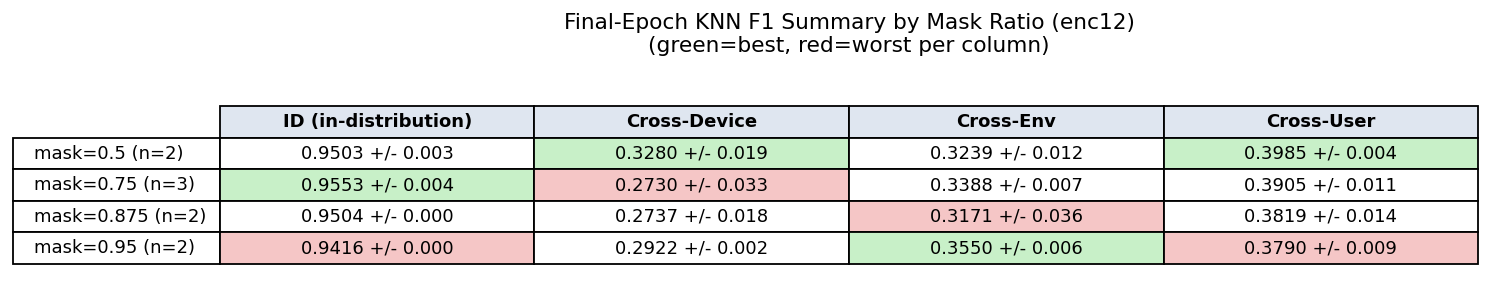


=== Summary: lp_f1 (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
mask=0.5              0.4888 +/- 0.003        0.3371 +/- 0.042        0.3635 +/- 0.001        0.3570 +/- 0.020
mask=0.75             0.4982 +/- 0.017        0.3545 +/- 0.012        0.3712 +/- 0.007        0.3896 +/- 0.000
mask=0.875            0.5030 +/- 0.002        0.3566 +/- 0.011        0.3651 +/- 0.007        0.3486 +/- 0.008
mask=0.95             0.4930 +/- 0.014        0.3492 +/- 0.021        0.3438 +/- 0.006        0.3585 +/- 0.006

=== Summary: knn_f1 (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
mask=0.5              0.9503 +/- 0.003        0.3280 +/- 0.019        0.3239 +/- 0.012        0.3985 +/- 0.004
mask=0.75             0.9553 +/- 0.004        0.2730 +/- 0.033        0.3388 +/- 0.007        0.3905 +/- 0.011
mask=0.875            0.9504 +/- 0.000   

In [29]:
if ratio_groups:
    plot_summary_table_image(
        ratio_groups, FIG_DIR, "ratio_table_lp_f1_enc12.png",
        title="Final-Epoch LP F1 Summary by Mask Ratio (enc12)",
        metric="lp_f1", group_label_fmt="mask={k}",
    )

    plot_summary_table_image(
        ratio_groups, FIG_DIR, "ratio_table_knn_f1_enc12.png",
        title="Final-Epoch KNN F1 Summary by Mask Ratio (enc12)",
        metric="knn_f1", group_label_fmt="mask={k}",
    )
    print_summary_table(ratio_groups, metric="lp_f1", group_label_fmt="mask={k}")
    print_summary_table(ratio_groups, metric="knn_f1", group_label_fmt="mask={k}")

## Section D — Mask Strategy Ablation (enc12, mask_ratio=0.75)

Same design as Section B, but rerun at `encoder_depth=12` instead of 6. Filters on
`mask_ratio=0.75`, `encoder_depth=12`, `patch_h=29`, `patch_w=25`, and groups by
`mask_strategy` (random / freq / mixed / time / 2d). Lets us check whether the
LP-vs-KNN divergence and the "2d is worst under LP" finding from the enc6 version
replicate at a deeper encoder.

In [30]:
STRATEGY_ENC12_FILTERS = {
    "mask_ratio": 0.75,
    "encoder_depth": 12,
    "patch_h": 29,
    "patch_w": 25,
}

strategy_enc12_results = load_matching_results(RESULTS_DIR, STRATEGY_ENC12_FILTERS, debug=DEBUG)
if not strategy_enc12_results:
    print("No mask-strategy-ablation (enc12, mask=0.75) files matched. Set DEBUG=True above and re-run.")
    strategy_enc12_groups = {}
else:
    strategy_enc12_groups = group_by(strategy_enc12_results, key_fn=lambda r: r["args"]["mask_strategy"])
    print(f"Found {len(strategy_enc12_results)} files across {len(strategy_enc12_groups)} strategies: "
          f"{ {k: len(v) for k, v in strategy_enc12_groups.items()} }")
    diagnose_incomplete_runs(strategy_enc12_results, "strategy_enc12")

Found 11 files across 5 strategies: {'2d': 2, 'freq': 2, 'mixed': 2, 'random': 3, 'time': 2}
[strategy_enc12] all 11 run(s) have complete eval data across all checkpoints/layers/splits.


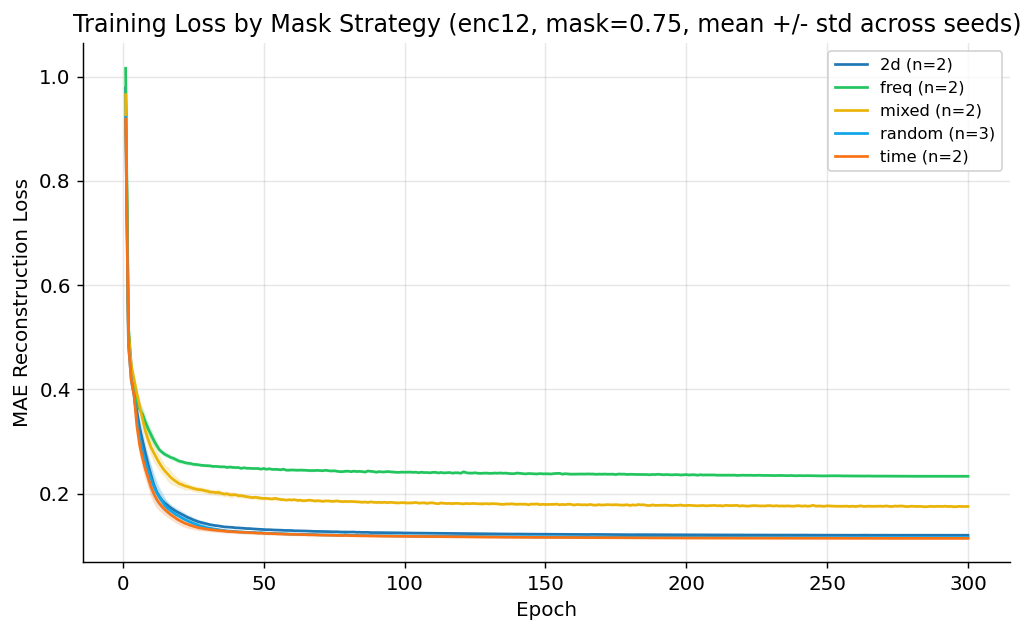

In [31]:
if strategy_enc12_groups:
    plot_loss_curve_by_group(
        strategy_enc12_groups, FIG_DIR, "strategy_enc12_loss_curve.png",
        title="Training Loss by Mask Strategy (enc12, mask=0.75, mean +/- std across seeds)",
        colors=STRATEGY_COLORS,
    )

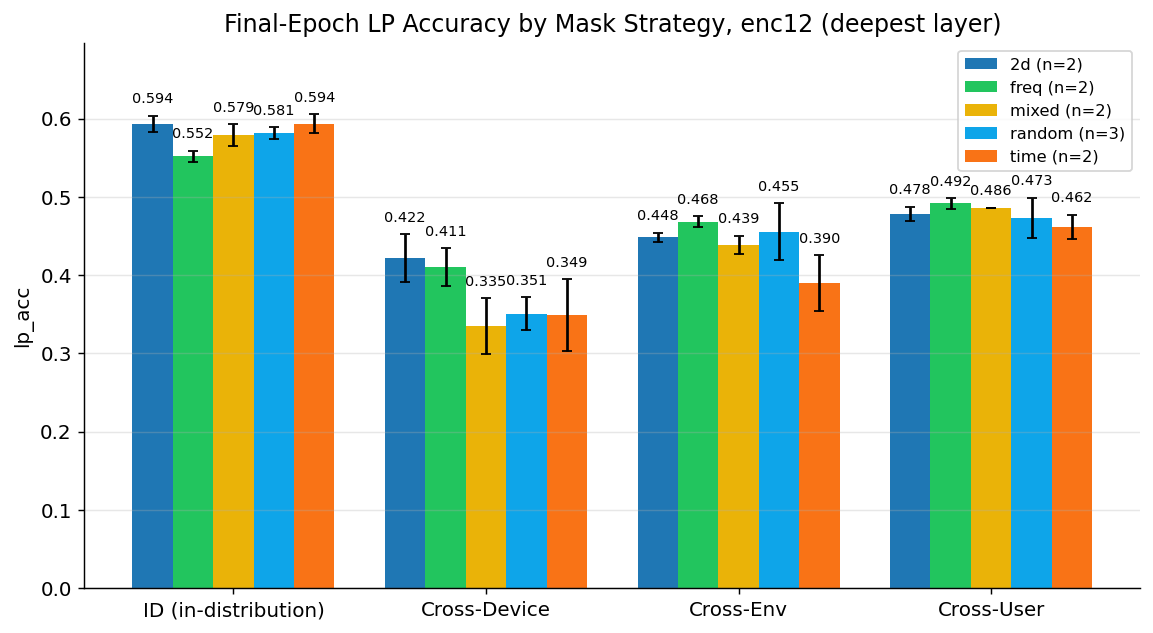

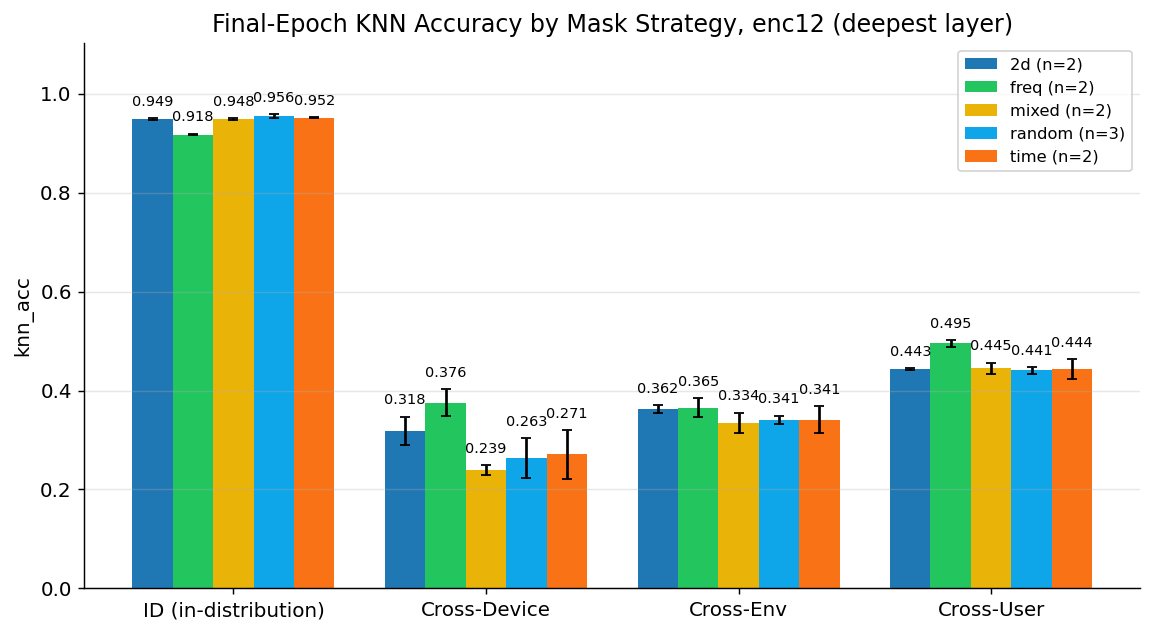

In [32]:
if strategy_enc12_groups:
    plot_final_accuracy_by_group(
        strategy_enc12_groups, FIG_DIR, "strategy_enc12_bar_lp_acc_enc12.png",
        title="Final-Epoch LP Accuracy by Mask Strategy, enc12 (deepest layer)",
        metric="lp_acc", colors=STRATEGY_COLORS,
    )
    plot_final_accuracy_by_group(
        strategy_enc12_groups, FIG_DIR, "strategy_enc12_bar_knn_acc_enc12.png",
        title="Final-Epoch KNN Accuracy by Mask Strategy, enc12 (deepest layer)",
        metric="knn_acc", colors=STRATEGY_COLORS,
    )

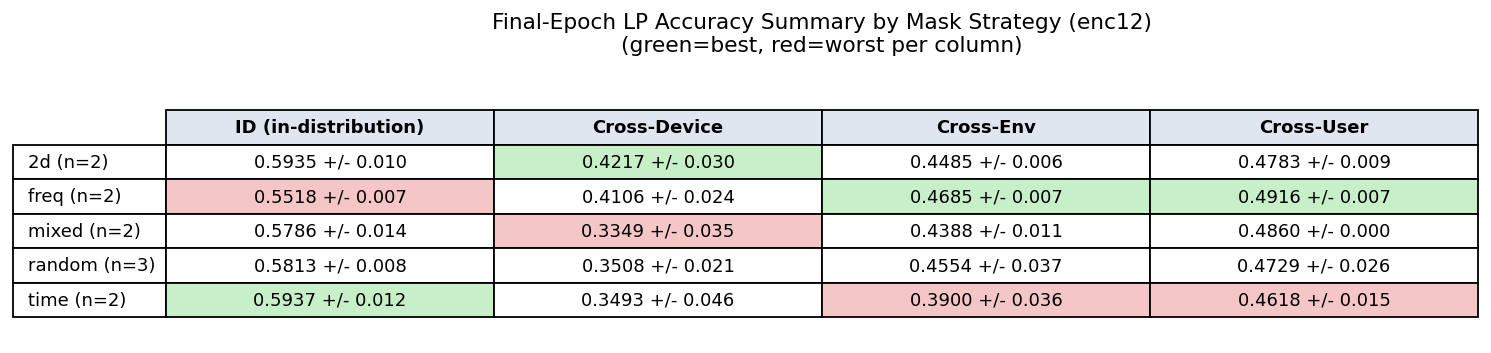

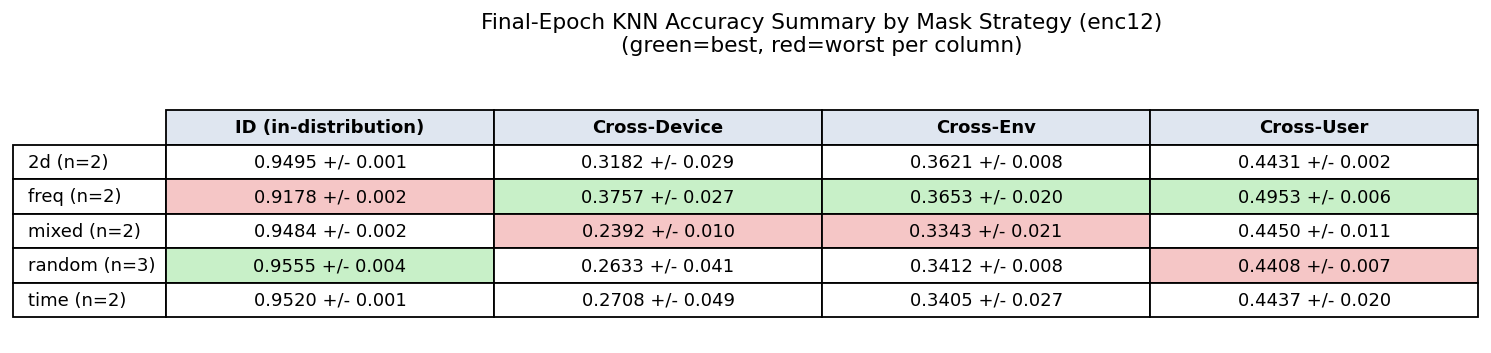


=== Summary: lp_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
2d                    0.5935 +/- 0.010        0.4217 +/- 0.030        0.4485 +/- 0.006        0.4783 +/- 0.009
freq                  0.5518 +/- 0.007        0.4106 +/- 0.024        0.4685 +/- 0.007        0.4916 +/- 0.007
mixed                 0.5786 +/- 0.014        0.3349 +/- 0.035        0.4388 +/- 0.011        0.4860 +/- 0.000
random                0.5813 +/- 0.008        0.3508 +/- 0.021        0.4554 +/- 0.037        0.4729 +/- 0.026
time                  0.5937 +/- 0.012        0.3493 +/- 0.046        0.3900 +/- 0.036        0.4618 +/- 0.015

=== Summary: knn_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
2d                    0.9495 +/- 0.001        0.3182 +/- 0.029        0.3621 +/- 0.008        0.4431 +/- 0.002
freq                  0.9178 +/- 0.002 

In [33]:
if strategy_enc12_groups:
    plot_summary_table_image(
        strategy_enc12_groups, FIG_DIR, "strategy_enc12_table_lp_acc_enc12.png",
        title="Final-Epoch LP Accuracy Summary by Mask Strategy (enc12)",
        metric="lp_acc",
    )
    plot_summary_table_image(
        strategy_enc12_groups, FIG_DIR, "strategy_enc12_table_knn_acc_enc12.png",
        title="Final-Epoch KNN Accuracy Summary by Mask Strategy (enc12)",
        metric="knn_acc",
    )
    print_summary_table(strategy_enc12_groups, metric="lp_acc")
    print_summary_table(strategy_enc12_groups, metric="knn_acc")

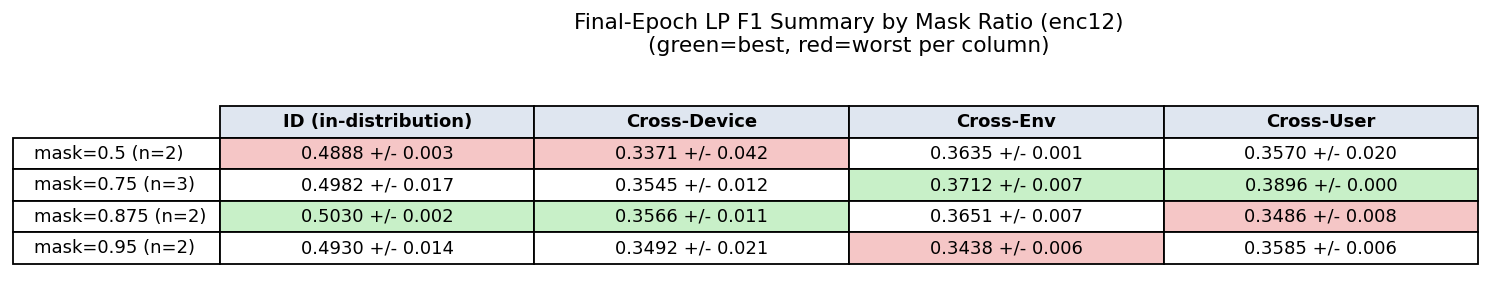

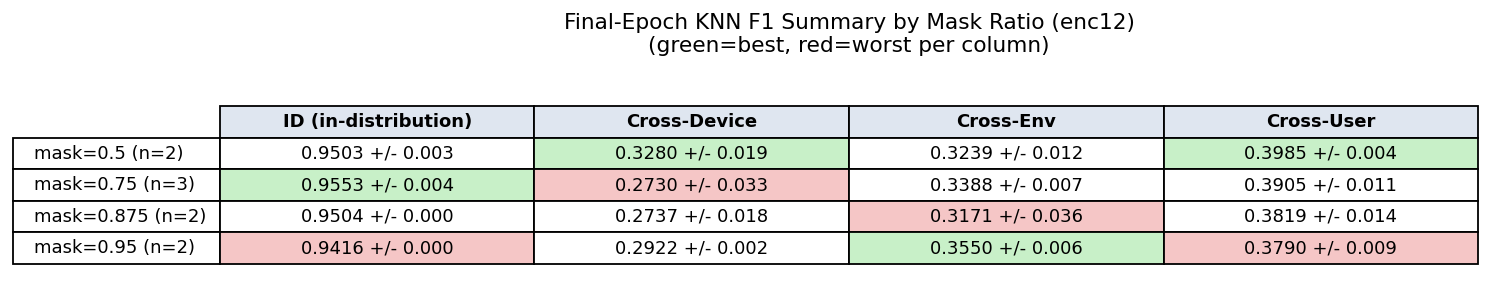


=== Summary: lp_f1 (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
mask=0.5              0.4888 +/- 0.003        0.3371 +/- 0.042        0.3635 +/- 0.001        0.3570 +/- 0.020
mask=0.75             0.4982 +/- 0.017        0.3545 +/- 0.012        0.3712 +/- 0.007        0.3896 +/- 0.000
mask=0.875            0.5030 +/- 0.002        0.3566 +/- 0.011        0.3651 +/- 0.007        0.3486 +/- 0.008
mask=0.95             0.4930 +/- 0.014        0.3492 +/- 0.021        0.3438 +/- 0.006        0.3585 +/- 0.006

=== Summary: knn_f1 (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
mask=0.5              0.9503 +/- 0.003        0.3280 +/- 0.019        0.3239 +/- 0.012        0.3985 +/- 0.004
mask=0.75             0.9553 +/- 0.004        0.2730 +/- 0.033        0.3388 +/- 0.007        0.3905 +/- 0.011
mask=0.875            0.9504 +/- 0.000   

In [34]:
if ratio_groups:
    plot_summary_table_image(
        ratio_groups, FIG_DIR, "ratio_table_lp_f1_enc12.png",
        title="Final-Epoch LP F1 Summary by Mask Ratio (enc12)",
        metric="lp_f1", group_label_fmt="mask={k}",
    )

    plot_summary_table_image(
        ratio_groups, FIG_DIR, "ratio_table_knn_f1_enc12.png",
        title="Final-Epoch KNN F1 Summary by Mask Ratio (enc12)",
        metric="knn_f1", group_label_fmt="mask={k}",
    )
    print_summary_table(ratio_groups, metric="lp_f1", group_label_fmt="mask={k}")
    print_summary_table(ratio_groups, metric="knn_f1", group_label_fmt="mask={k}")

**Cross-check against the enc6 version.** If `strategy_groups` (Section B) is already loaded in this
kernel session, the cell below prints both encoder depths side by side for `lp_acc`, so you can see at a
glance whether the enc6 ranking (e.g. "2d worst on Cross-Device") replicates at enc12, or whether it was
partly an artifact of depth-6 specifically.

In [35]:
if strategy_groups and strategy_enc12_groups:
    print("=== enc6 (Section B) ===")
    print_summary_table(strategy_groups, metric="lp_acc")
    print("\n=== enc12 (Section D) ===")
    print_summary_table(strategy_enc12_groups, metric="lp_acc")
else:
    print("Run Section B\'s cells first in this kernel session to enable the enc6-vs-enc12 comparison.")

=== enc6 (Section B) ===

=== Summary: lp_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
2d                    0.5849 +/- 0.000        0.2912 +/- 0.025        0.3488 +/- 0.027        0.4175 +/- 0.031
freq                  0.5621 +/- 0.009        0.4639 +/- 0.030        0.4464 +/- 0.010        0.4881 +/- 0.009
mixed                 0.5573 +/- 0.001        0.4238 +/- 0.022        0.4010 +/- 0.022        0.5047 +/- 0.003
random                0.5663 +/- 0.005        0.4105 +/- 0.012        0.3926 +/- 0.008        0.4725 +/- 0.028
time                  0.5833 +/- 0.001        0.4101 +/- 0.003        0.4110 +/- 0.010        0.4849 +/- 0.004

=== enc12 (Section D) ===

=== Summary: lp_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
2d                    0.5935 +/- 0.010        0.4217 +/- 0.030        0.4485 +/- 0.006        0.478

## Section C — Patch Size Ablation (enc6, mask_ratio=0.75)

Filters on `mask_ratio=0.75`, `encoder_depth=6`, `mask_strategy="random"`, and requires
`patch_h == patch_w` (square patches), grouping by patch size. Patch sizes 3/5/7/11/13 require
the input to be zero-padded to a size divisible by the patch size (since none of them evenly
divide the standard 232x500 input) -- see the padded-size table in the writeup for what each
patch size actually pads to.

In [36]:
PATCH_FILTERS = {
    "mask_ratio": 0.75,
    "encoder_depth": 6,
    "mask_strategy": "random",
}

patch_results_all = load_matching_results(RESULTS_DIR, PATCH_FILTERS, debug=DEBUG)
patch_results = [r for r in patch_results_all
                  if r["args"].get("patch_h") is not None
                  and r["args"].get("patch_h") == r["args"].get("patch_w")]

if not patch_results:
    print("No patch-size-ablation (enc6, mask=0.75, random, square patch) files matched. "
          "Set DEBUG=True above and re-run.")
    patch_groups = {}
else:
    patch_groups = group_by(patch_results, key_fn=lambda r: r["args"]["patch_h"])
    print(f"Found {len(patch_results)} files across {len(patch_groups)} patch sizes: "
          f"{ {k: len(v) for k, v in patch_groups.items()} }")
    diagnose_incomplete_runs(patch_results, "patch")

PATCH_COLORS = {11: "#0EA5E9", 13: "#22C55E", 15: "#EAB308", 17: "#F97316", 19: "#DC2626"}

Found 10 files across 5 patch sizes: {11: 2, 13: 2, 15: 2, 17: 2, 19: 2}
[patch] all 10 run(s) have complete eval data across all checkpoints/layers/splits.


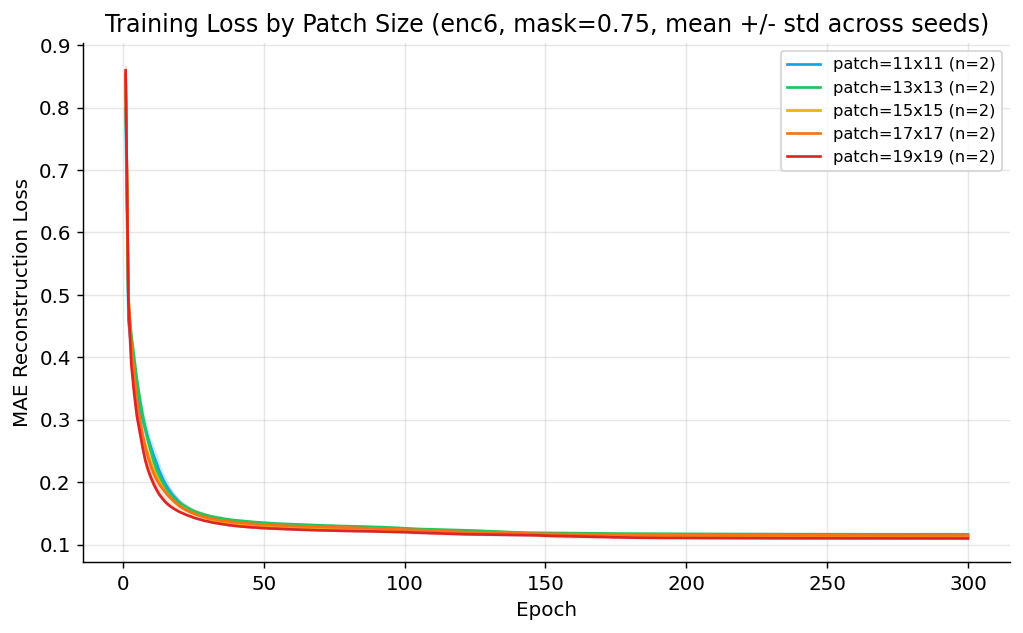

In [37]:
if patch_groups:
    plot_loss_curve_by_group(
        patch_groups, FIG_DIR, "patch_loss_curve_enc6.png",
        title="Training Loss by Patch Size (enc6, mask=0.75, mean +/- std across seeds)",
        colors=PATCH_COLORS, group_label_fmt="patch={k}x{k}",
    )

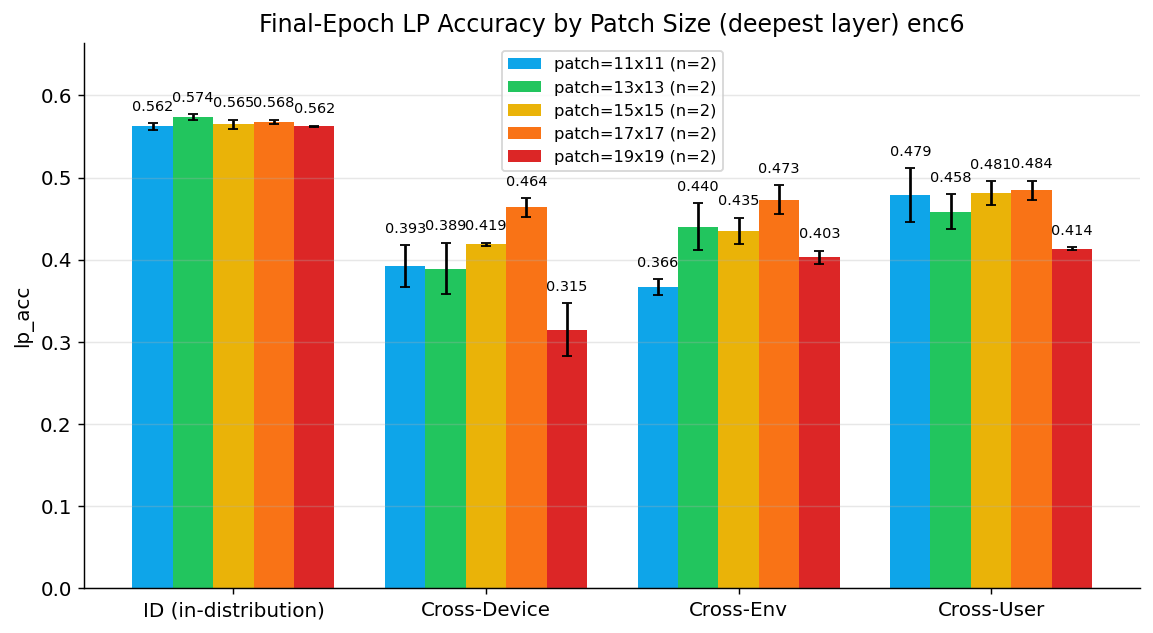

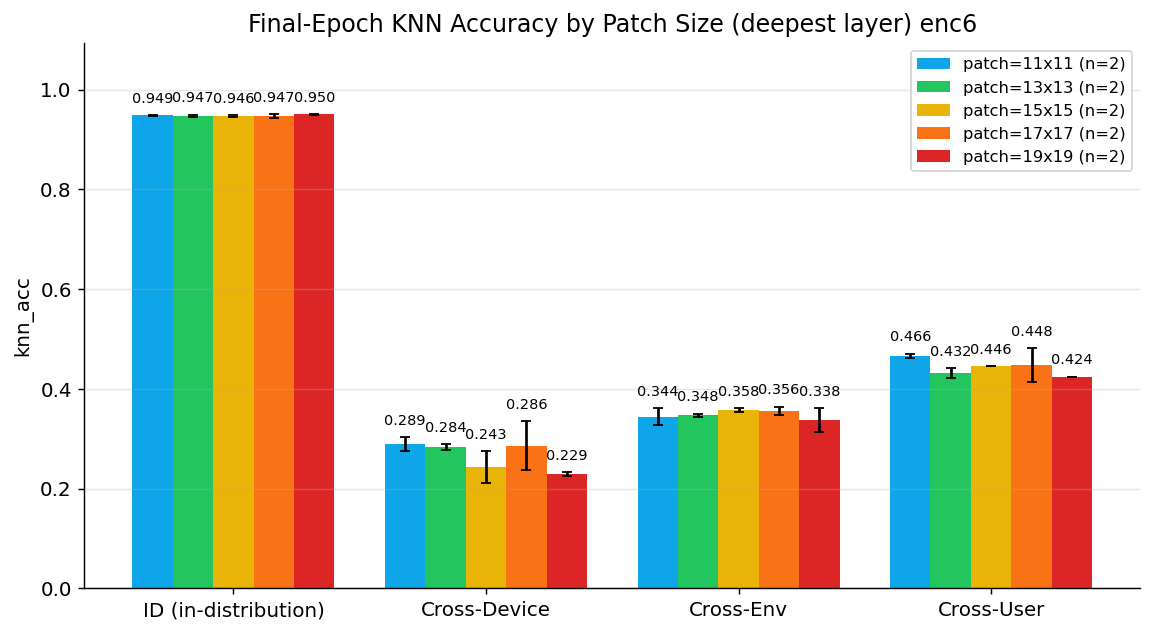

In [38]:
if patch_groups:
    plot_final_accuracy_by_group(
        patch_groups, FIG_DIR, "patch_bar_lp_acc_enc6.png",
        title="Final-Epoch LP Accuracy by Patch Size (deepest layer) enc6",
        metric="lp_acc", colors=PATCH_COLORS, group_label_fmt="patch={k}x{k}",
    )
    plot_final_accuracy_by_group(
        patch_groups, FIG_DIR, "patch_bar_knn_acc_enc6.png",
        title="Final-Epoch KNN Accuracy by Patch Size (deepest layer) enc6",
        metric="knn_acc", colors=PATCH_COLORS, group_label_fmt="patch={k}x{k}",
    )

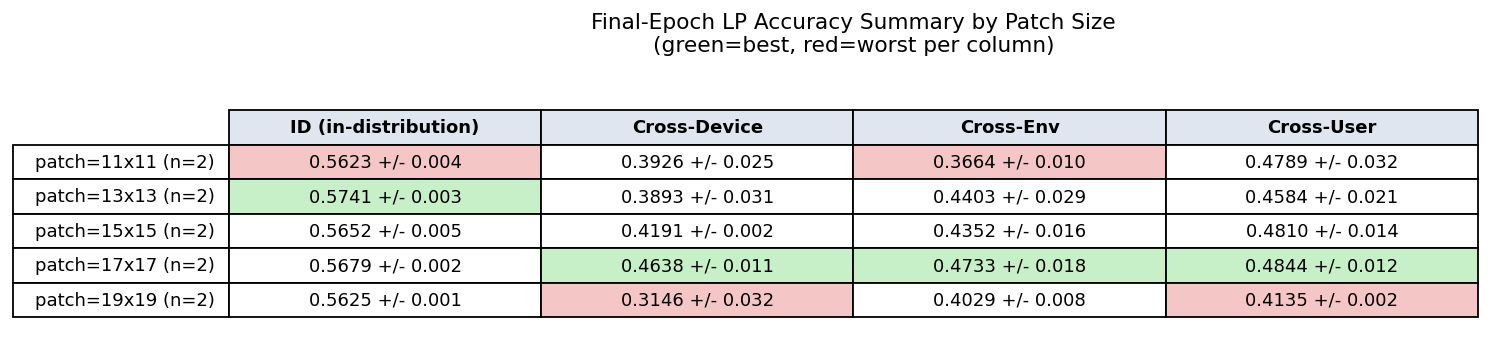

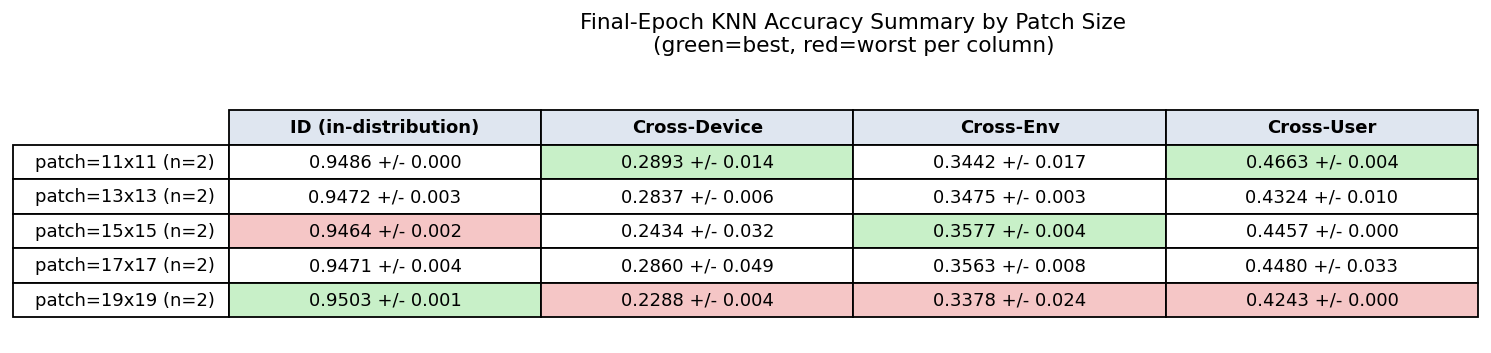


=== Summary: lp_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
patch=11x11           0.5623 +/- 0.004        0.3926 +/- 0.025        0.3664 +/- 0.010        0.4789 +/- 0.032
patch=13x13           0.5741 +/- 0.003        0.3893 +/- 0.031        0.4403 +/- 0.029        0.4584 +/- 0.021
patch=15x15           0.5652 +/- 0.005        0.4191 +/- 0.002        0.4352 +/- 0.016        0.4810 +/- 0.014
patch=17x17           0.5679 +/- 0.002        0.4638 +/- 0.011        0.4733 +/- 0.018        0.4844 +/- 0.012
patch=19x19           0.5625 +/- 0.001        0.3146 +/- 0.032        0.4029 +/- 0.008        0.4135 +/- 0.002

=== Summary: knn_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
patch=11x11           0.9486 +/- 0.000        0.2893 +/- 0.014        0.3442 +/- 0.017        0.4663 +/- 0.004
patch=13x13           0.9472 +/- 0.003 

In [39]:
if patch_groups:
    plot_summary_table_image(
        patch_groups, FIG_DIR, "patch_table_lp_acc_enc6.png",
        title="Final-Epoch LP Accuracy Summary by Patch Size",
        metric="lp_acc", group_label_fmt="patch={k}x{k}",
    )

    plot_summary_table_image(
        patch_groups, FIG_DIR, "patch_table_knn_acc_enc6.png",
        title="Final-Epoch KNN Accuracy Summary by Patch Size",
        metric="knn_acc", group_label_fmt="patch={k}x{k}",
    )

    print_summary_table(patch_groups, metric="lp_acc", group_label_fmt="patch={k}x{k}")
    print_summary_table(patch_groups, metric="knn_acc", group_label_fmt="patch={k}x{k}")

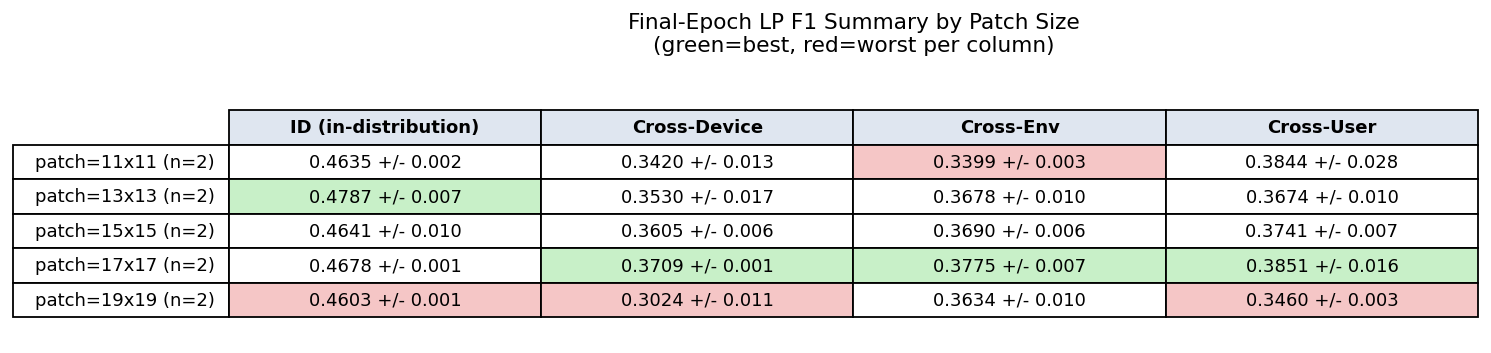

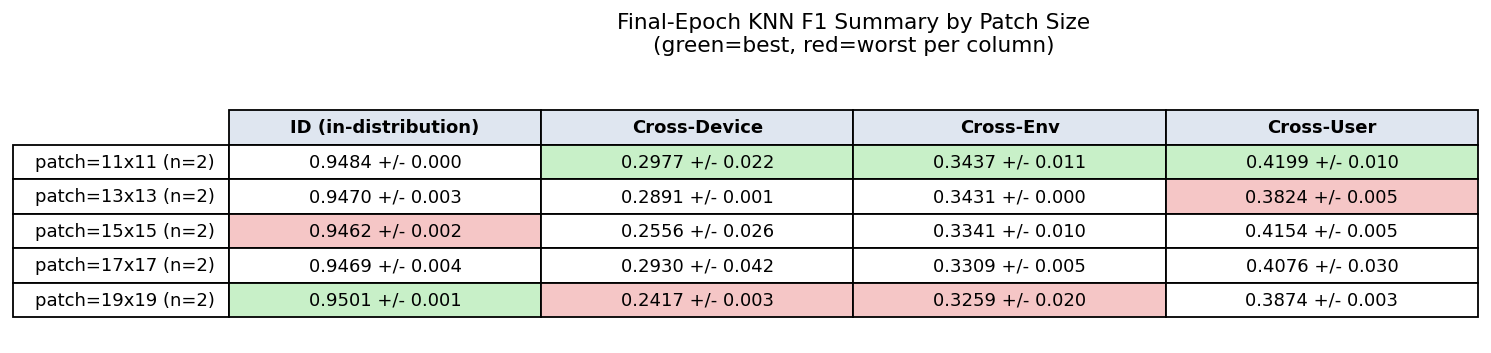


=== Summary: lp_f1 (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
patch=11x11           0.4635 +/- 0.002        0.3420 +/- 0.013        0.3399 +/- 0.003        0.3844 +/- 0.028
patch=13x13           0.4787 +/- 0.007        0.3530 +/- 0.017        0.3678 +/- 0.010        0.3674 +/- 0.010
patch=15x15           0.4641 +/- 0.010        0.3605 +/- 0.006        0.3690 +/- 0.006        0.3741 +/- 0.007
patch=17x17           0.4678 +/- 0.001        0.3709 +/- 0.001        0.3775 +/- 0.007        0.3851 +/- 0.016
patch=19x19           0.4603 +/- 0.001        0.3024 +/- 0.011        0.3634 +/- 0.010        0.3460 +/- 0.003

=== Summary: knn_f1 (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
patch=11x11           0.9484 +/- 0.000        0.2977 +/- 0.022        0.3437 +/- 0.011        0.4199 +/- 0.010
patch=13x13           0.9470 +/- 0.003   

In [40]:
if patch_groups:
    plot_summary_table_image(
        patch_groups, FIG_DIR, "patch_table_lp_f1_enc6.png",
        title="Final-Epoch LP F1 Summary by Patch Size",
        metric="lp_f1", group_label_fmt="patch={k}x{k}",
    )

    plot_summary_table_image(
        patch_groups, FIG_DIR, "patch_table_knn_f1_enc6.png",
        title="Final-Epoch KNN F1 Summary by Patch Size",
        metric="knn_f1", group_label_fmt="patch={k}x{k}",
    )

    print_summary_table(patch_groups, metric="lp_f1", group_label_fmt="patch={k}x{k}")
    print_summary_table(patch_groups, metric="knn_f1", group_label_fmt="patch={k}x{k}")

## Section E — Patch Size Ablation (enc12, mask_ratio=0.75)

Same design as Section C, but rerun at `encoder_depth=12`. Filters on `mask_ratio=0.75`,
`encoder_depth=12`, `mask_strategy="random"`, requires `patch_h == patch_w`, groups by patch size.

**Note `patch=11` uses a different `batch_size` than the rest of this sweep.** Doubling
`encoder_depth` doubles the cumulative attention memory (all layers' attention scores are
retained simultaneously during backward), so `patch=11` at `batch_size=128` is UNSAFE at
`encoder_depth=12` (23.4 GB cumulative, over the 20GB budget) even though it was fine at
`encoder_depth=6` (11.7 GB). To keep this sweep directly comparable to Section C's
11x11/13x13/15x15/17x17/19x19 (rather than dropping patch=11 and losing the overlap), the
launch script runs `patch=11` alone at `batch_size=96` (17.6 GB cumulative, safe) while
13x13/15x15/17x17/19x19 use the standard `batch_size=128`. This grouping logic (by `mask_ratio`,
`encoder_depth`, `mask_strategy`) does not care about `batch_size`, so the mixed-batch-size
files are grouped together with the rest exactly as if they all used the same batch_size --
if you want to sanity-check that the smaller batch_size for patch=11 isn't itself a
confound, compare its loss curve (Section E's loss-curve plot) to the others for a similar
convergence shape.

In [41]:

PATCH_ENC12_FILTERS = {
    "mask_ratio": 0.75,
    "encoder_depth": 12,
    "mask_strategy": "random",
}

patch_enc12_results_all = load_matching_results(RESULTS_DIR, PATCH_ENC12_FILTERS, debug=DEBUG)
# Same is-not-None guard as Section C -- do not simplify this back to a bare .get()==.get()
# comparison, or legacy files missing both keys will silently pass and crash group_by later.
patch_enc12_results = [r for r in patch_enc12_results_all
                        if r["args"].get("patch_h") is not None
                        and r["args"].get("patch_h") == r["args"].get("patch_w")]

if not patch_enc12_results:
    print("No patch-size-ablation (enc12, mask=0.75, random, square patch) files matched. "
          "Set DEBUG=True above and re-run.")
    patch_enc12_groups = {}
else:
    patch_enc12_groups = group_by(patch_enc12_results, key_fn=lambda r: r["args"]["patch_h"])
    print(f"Found {len(patch_enc12_results)} files across {len(patch_enc12_groups)} patch sizes: "
          f"{ {k: len(v) for k, v in patch_enc12_groups.items()} }")
    diagnose_incomplete_runs(patch_enc12_results, "patch_enc12")

_patch_enc12_keys_sorted = sorted(patch_enc12_groups.keys()) if patch_enc12_groups else []
_patch_enc12_cmap = matplotlib.colormaps["plasma"]
_n_patch_enc12 = max(len(_patch_enc12_keys_sorted) - 1, 1)
PATCH_ENC12_COLORS = {k: _patch_enc12_cmap(i / _n_patch_enc12) for i, k in enumerate(_patch_enc12_keys_sorted)}

Found 12 files across 6 patch sizes: {11: 2, 13: 2, 15: 2, 17: 2, 19: 2, 21: 2}
[patch_enc12] all 12 run(s) have complete eval data across all checkpoints/layers/splits.


[warn] group=19: loss_log lengths differ [250, 300] -- truncating all runs to the shortest (250 epochs) for this curve


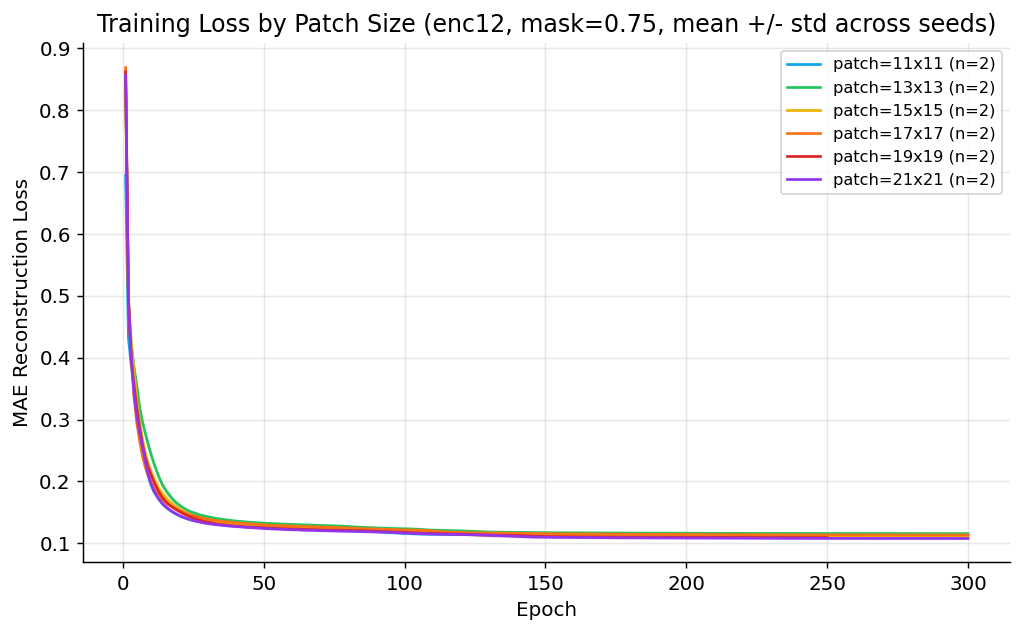

In [42]:
if patch_enc12_groups:
    plot_loss_curve_by_group(
        patch_enc12_groups, FIG_DIR, "patch_enc12_loss_curve.png",
        title="Training Loss by Patch Size (enc12, mask=0.75, mean +/- std across seeds)",
        colors=GROUP_COLORS, group_label_fmt="patch={k}x{k}",
    )

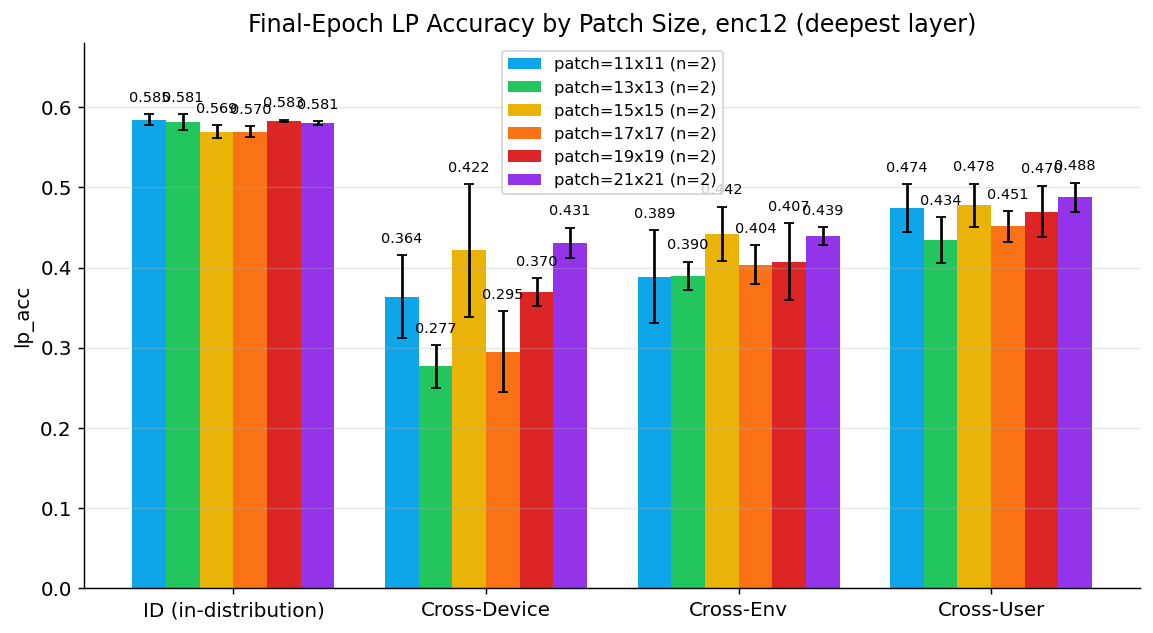

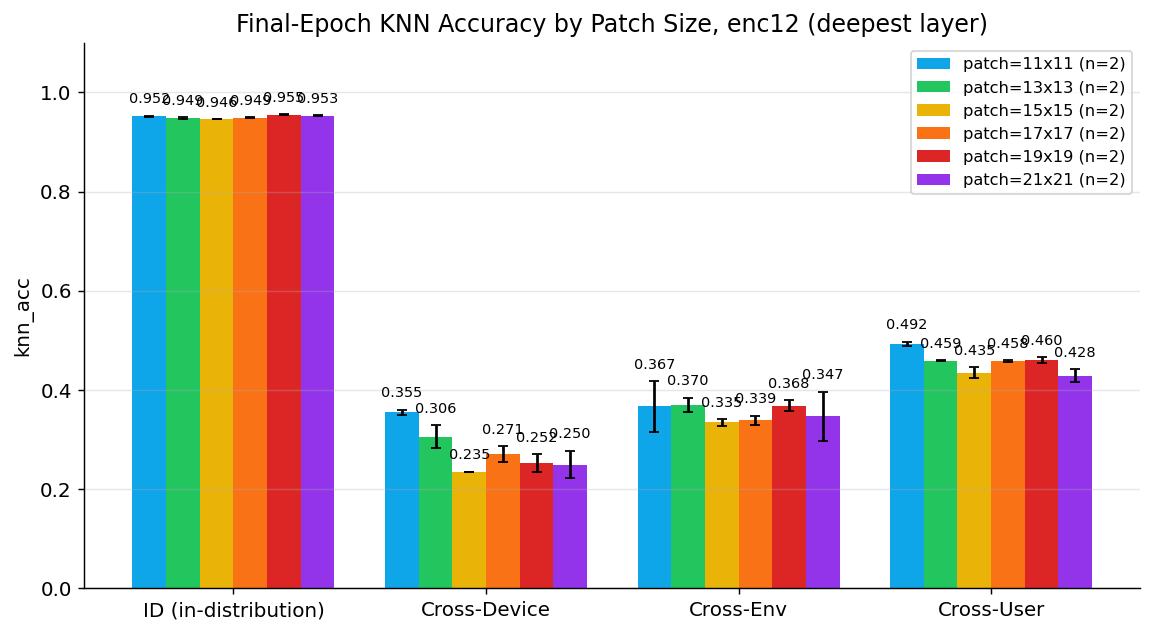

In [43]:
if patch_enc12_groups:
    plot_final_accuracy_by_group(
        patch_enc12_groups, FIG_DIR, "patch_enc12_bar_lp_acc.png",
        title="Final-Epoch LP Accuracy by Patch Size, enc12 (deepest layer)",
        metric="lp_acc", colors=GROUP_COLORS, group_label_fmt="patch={k}x{k}",
    )
    plot_final_accuracy_by_group(
        patch_enc12_groups, FIG_DIR, "patch_enc12_bar_knn_acc.png",
        title="Final-Epoch KNN Accuracy by Patch Size, enc12 (deepest layer)",
        metric="knn_acc", colors=GROUP_COLORS, group_label_fmt="patch={k}x{k}",
    )

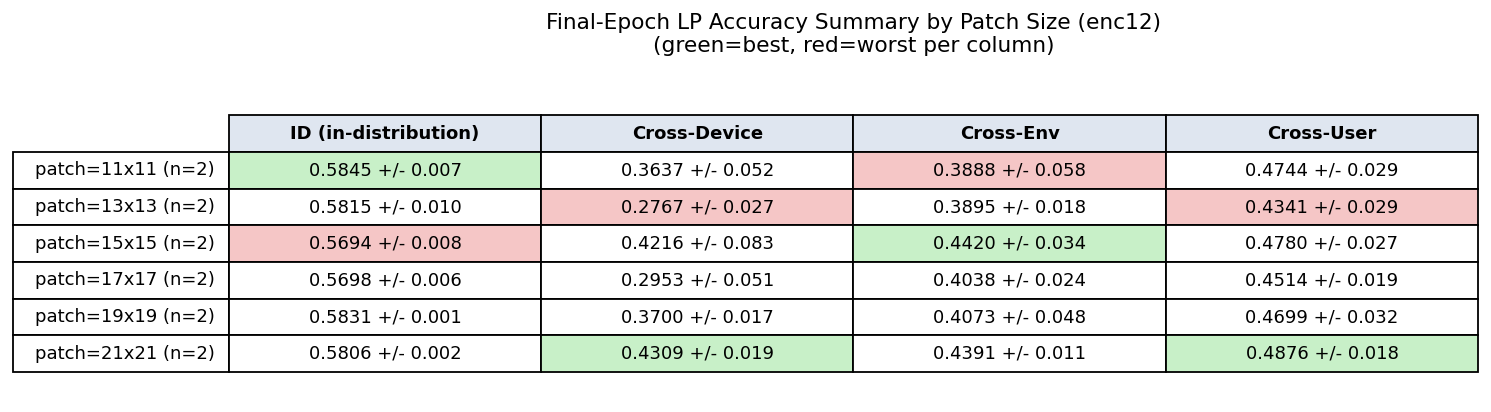

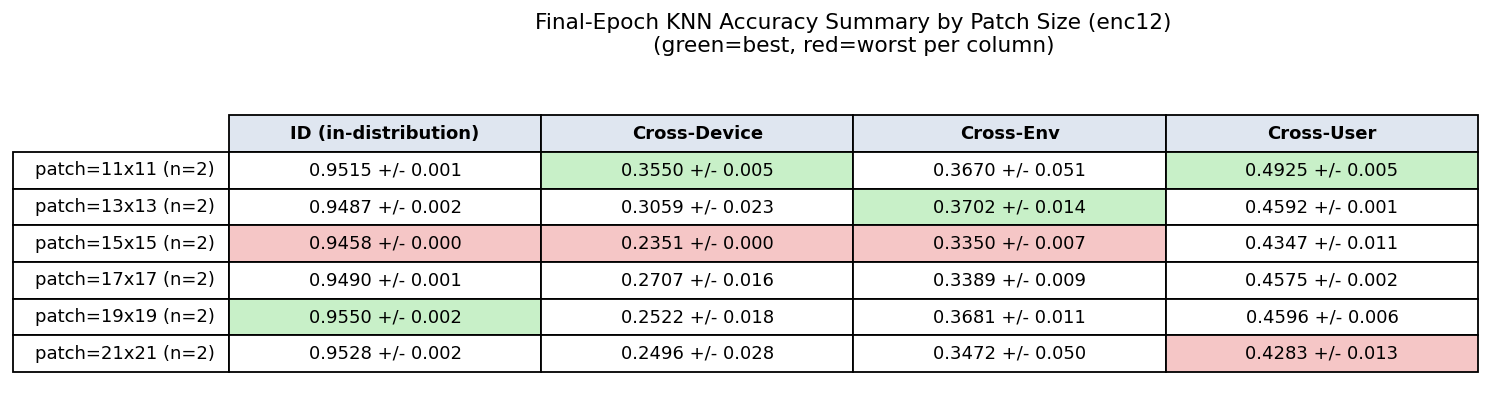


=== Summary: lp_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
patch=11x11           0.5845 +/- 0.007        0.3637 +/- 0.052        0.3888 +/- 0.058        0.4744 +/- 0.029
patch=13x13           0.5815 +/- 0.010        0.2767 +/- 0.027        0.3895 +/- 0.018        0.4341 +/- 0.029
patch=15x15           0.5694 +/- 0.008        0.4216 +/- 0.083        0.4420 +/- 0.034        0.4780 +/- 0.027
patch=17x17           0.5698 +/- 0.006        0.2953 +/- 0.051        0.4038 +/- 0.024        0.4514 +/- 0.019
patch=19x19           0.5831 +/- 0.001        0.3700 +/- 0.017        0.4073 +/- 0.048        0.4699 +/- 0.032
patch=21x21           0.5806 +/- 0.002        0.4309 +/- 0.019        0.4391 +/- 0.011        0.4876 +/- 0.018

=== Summary: knn_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
patch=11x11           0.9515 +/- 0.001 

In [44]:
if patch_enc12_groups:
    plot_summary_table_image(
        patch_enc12_groups, FIG_DIR, "patch_enc12_table_lp_acc.png",
        title="Final-Epoch LP Accuracy Summary by Patch Size (enc12)",
        metric="lp_acc", group_label_fmt="patch={k}x{k}",
    )

    plot_summary_table_image(
        patch_enc12_groups, FIG_DIR, "patch_enc12_table_knn_acc.png",
        title="Final-Epoch KNN Accuracy Summary by Patch Size (enc12)",
        metric="knn_acc", group_label_fmt="patch={k}x{k}",
    )

    print_summary_table(patch_enc12_groups, metric="lp_acc", group_label_fmt="patch={k}x{k}")
    print_summary_table(patch_enc12_groups, metric="knn_acc", group_label_fmt="patch={k}x{k}")

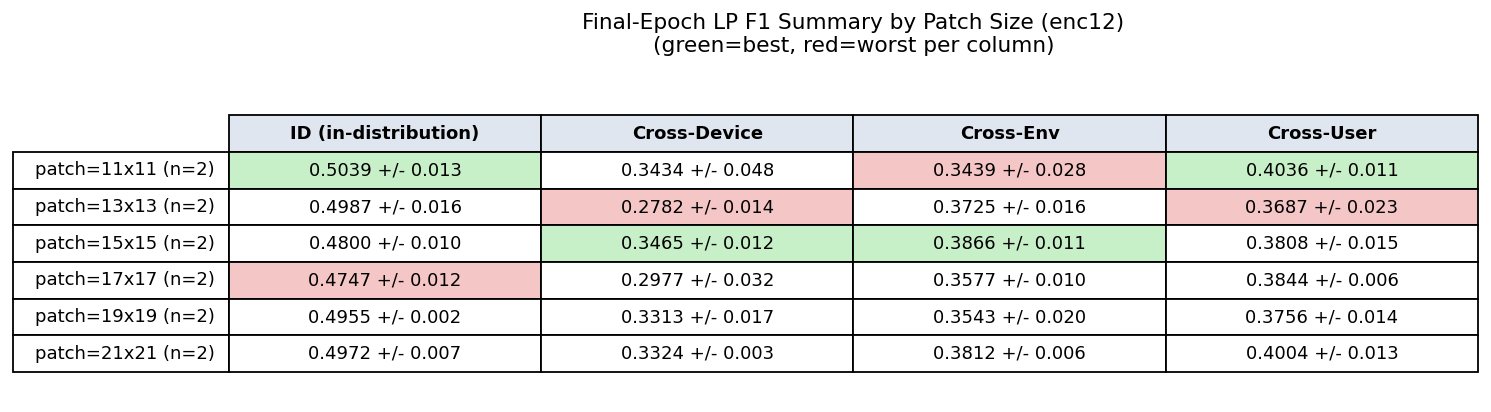

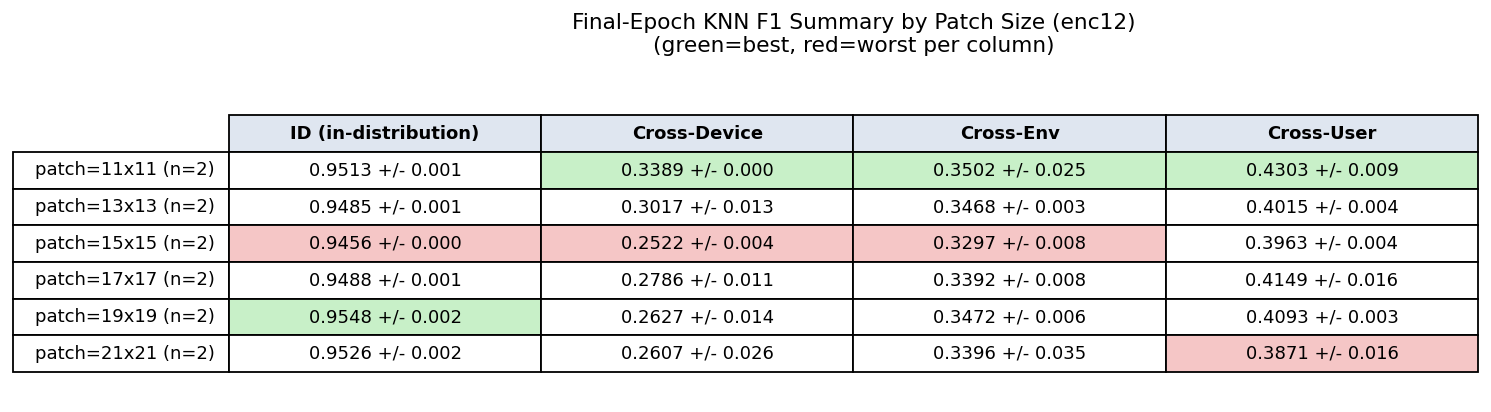


=== Summary: lp_f1 (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
patch=11x11           0.5039 +/- 0.013        0.3434 +/- 0.048        0.3439 +/- 0.028        0.4036 +/- 0.011
patch=13x13           0.4987 +/- 0.016        0.2782 +/- 0.014        0.3725 +/- 0.016        0.3687 +/- 0.023
patch=15x15           0.4800 +/- 0.010        0.3465 +/- 0.012        0.3866 +/- 0.011        0.3808 +/- 0.015
patch=17x17           0.4747 +/- 0.012        0.2977 +/- 0.032        0.3577 +/- 0.010        0.3844 +/- 0.006
patch=19x19           0.4955 +/- 0.002        0.3313 +/- 0.017        0.3543 +/- 0.020        0.3756 +/- 0.014
patch=21x21           0.4972 +/- 0.007        0.3324 +/- 0.003        0.3812 +/- 0.006        0.4004 +/- 0.013

=== Summary: knn_f1 (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
patch=11x11           0.9513 +/- 0.001   

In [45]:
if patch_enc12_groups:
    plot_summary_table_image(
        patch_enc12_groups, FIG_DIR, "patch_enc12_table_lp_f1.png",
        title="Final-Epoch LP F1 Summary by Patch Size (enc12)",
        metric="lp_f1", group_label_fmt="patch={k}x{k}",
    )

    plot_summary_table_image(
        patch_enc12_groups, FIG_DIR, "patch_enc12_table_knn_f1.png",
        title="Final-Epoch KNN F1 Summary by Patch Size (enc12)",
        metric="knn_f1", group_label_fmt="patch={k}x{k}",
    )

    print_summary_table(patch_enc12_groups, metric="lp_f1", group_label_fmt="patch={k}x{k}")
    print_summary_table(patch_enc12_groups, metric="knn_f1", group_label_fmt="patch={k}x{k}")

**Cross-check against the enc6 version.** If `patch_groups` (Section C) is already loaded in this
kernel session, this compares both encoder depths side by side for `lp_acc` -- note the enc6 sweep
includes `patch=11` which has no enc12 counterpart (unsafe at that depth), so the two series only
overlap at `patch=13`.

In [46]:
if patch_groups and patch_enc12_groups:
    print("=== enc6 (Section C) ===")
    print_summary_table(patch_groups, metric="lp_acc", group_label_fmt="patch={k}x{k}")
    print("\n=== enc12 (Section E) ===")
    print_summary_table(patch_enc12_groups, metric="lp_acc", group_label_fmt="patch={k}x{k}")
else:
    print("Run Section C\'s cells first in this kernel session to enable the enc6-vs-enc12 comparison.")

=== enc6 (Section C) ===

=== Summary: lp_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
patch=11x11           0.5623 +/- 0.004        0.3926 +/- 0.025        0.3664 +/- 0.010        0.4789 +/- 0.032
patch=13x13           0.5741 +/- 0.003        0.3893 +/- 0.031        0.4403 +/- 0.029        0.4584 +/- 0.021
patch=15x15           0.5652 +/- 0.005        0.4191 +/- 0.002        0.4352 +/- 0.016        0.4810 +/- 0.014
patch=17x17           0.5679 +/- 0.002        0.4638 +/- 0.011        0.4733 +/- 0.018        0.4844 +/- 0.012
patch=19x19           0.5625 +/- 0.001        0.3146 +/- 0.032        0.4029 +/- 0.008        0.4135 +/- 0.002

=== enc12 (Section E) ===

=== Summary: lp_acc (mean +/- std across runs) ===
group         ID (in-distribution)        Cross-Device           Cross-Env          Cross-User
patch=11x11           0.5845 +/- 0.007        0.3637 +/- 0.052        0.3888 +/- 0.058        0.474

## Section F — Head Capacity Comparison (LP vs MLP Probe vs Attentive Probe)

Compares accuracy across probe types on `test_id` vs the three OOD splits, for a single
checkpoint/config. Answers: does more head capacity (LP -> MLP -> Attentive) help or hurt
OOD generalization, even though it consistently helps in-distribution accuracy?

Uses the same `load_matching_results` / `RESULTS_DIR` / `TEST_SPLITS` / `SPLIT_LABELS`
utilities as the sections above -- set `HEAD_CAP_FILTERS` below to pick the config to
inspect (defaults to the "random" enc12 baseline used throughout this project).

Attentive-probe columns (`attn_light_acc` / `attn_heavy_acc`) only exist in JSONs produced
by a run with `--run_attentive_probe` enabled. If missing, this section automatically skips
them and compares whatever protocols ARE present (KNN/LP/MLP exist in every run).

In [47]:
HEAD_CAP_FILTERS = {
    "mask_strategy": "random",
    "encoder_depth": 12,
    "patch_h": 29,
    "patch_w": 25,
    "seed": 42,
}
HEAD_CAP_LAYER = 12  # encoder layer to visualize
DEBUG = False  # flip to True if 0 files match and you need to see why, per file

head_cap_results = load_matching_results(RESULTS_DIR, HEAD_CAP_FILTERS, debug=DEBUG)
if not head_cap_results:
    print("No files matched HEAD_CAP_FILTERS. Set DEBUG=True above and re-run this cell.")
    layer_evals = None
else:
    if len(head_cap_results) > 1:
        print(f"[warn] {len(head_cap_results)} files matched HEAD_CAP_FILTERS -- "
              f"using the first one. Narrow HEAD_CAP_FILTERS (e.g. add a seed) if this "
              f"isn't the file you expected.")
    result = head_cap_results[0]
    final_ckpt = get_checkpoints(result)[-1]
    layer_key = f"layer_{HEAD_CAP_LAYER}"
    layer_evals = result["evals"][final_ckpt].get(layer_key)
    if layer_evals is None:
        print(f"[warn] layer {HEAD_CAP_LAYER} not found in {final_ckpt} -- "
              f"available layers: {get_layers(result)}")
    else:
        print(f"Config: {result['exp']}")
        print(f"Using checkpoint: {final_ckpt}, layer: {HEAD_CAP_LAYER}")

[warn] 5 files matched HEAD_CAP_FILTERS -- using the first one. Narrow HEAD_CAP_FILTERS (e.g. add a seed) if this isn't the file you expected.
Config: mae_har_ep300_mask0.5_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128
Using checkpoint: epoch_300, layer: 12


In [48]:
PROTOCOL_KEYS = {
    "LP": "lp_acc",
    "MLP probe": "mlp_acc",
    "Attentive (light)": "attn_light_acc",
    "Attentive (heavy)": "attn_heavy_acc",
}
PROTOCOL_COLORS = {
    "LP": "#64748B", "MLP probe": "#0891B2",
    "Attentive (light)": "#7C3AED", "Attentive (heavy)": "#D97706",
}

if layer_evals is not None:
    available_protocols = {}
    for name, key in PROTOCOL_KEYS.items():
        values = [layer_evals[s].get(key) for s in TEST_SPLITS]
        if all(v is not None for v in values):
            available_protocols[name] = values
        else:
            print(f"[skip] '{name}' ({key}) not found -- likely this run didn't use "
                  f"--run_attentive_probe.")

    if len(available_protocols) < 2:
        print("Need at least 2 protocols with data for a meaningful comparison.")
    else:
        fig, ax = plt.subplots(figsize=(9, 6))
        n_protocols = len(available_protocols)
        width = 0.8 / n_protocols
        x = np.arange(len(TEST_SPLITS))

        for i, (name, values) in enumerate(available_protocols.items()):
            offset = (i - (n_protocols - 1) / 2) * width
            ax.bar(x + offset, values, width=width, label=name,
                   color=PROTOCOL_COLORS.get(name))

        ax.set_xticks(x)
        ax.set_xticklabels([SPLIT_LABELS[s] for s in TEST_SPLITS])
        ax.set_ylabel("Accuracy")
        ax.set_ylim(0, 1.0)
        ax.set_title(f"Head Capacity Comparison \u2014 {result['exp']}, layer {HEAD_CAP_LAYER}\n"
                     f"(ID gain vs. OOD cost as head capacity increases)")
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3, axis="y")
        fig.tight_layout()
        fig.savefig(FIG_DIR / f"head_capacity_{result['exp']}_layer{HEAD_CAP_LAYER}.png",
                    dpi=150, bbox_inches="tight")
        plt.show()

[skip] 'MLP probe' (mlp_acc) not found -- likely this run didn't use --run_attentive_probe.
[skip] 'Attentive (light)' (attn_light_acc) not found -- likely this run didn't use --run_attentive_probe.
[skip] 'Attentive (heavy)' (attn_heavy_acc) not found -- likely this run didn't use --run_attentive_probe.
Need at least 2 protocols with data for a meaningful comparison.


In [49]:
if layer_evals is not None and len(available_protocols) >= 2:
    print(f"{'Protocol':<20}{'ID':>8}{'OOD avg':>10}{'ID-OOD gap':>12}")
    gap_rows = []
    for name, values in available_protocols.items():
        id_acc = values[0]
        ood_avg = np.mean(values[1:])
        gap = id_acc - ood_avg
        gap_rows.append((name, id_acc, ood_avg, gap))
        print(f"{name:<20}{id_acc:>8.3f}{ood_avg:>10.3f}{gap:>12.3f}")

    print("\nRanked by generalization (smallest gap = most generalizable):")
    for name, id_acc, ood_avg, gap in sorted(gap_rows, key=lambda r: r[3]):
        print(f"  {gap:.3f}  {name}")

## Section G — MAE SSL vs. Supervised Baselines (Table 12) — OOD Generalization

Compares your pretrained MAE (best layer/protocol per split, at the final checkpoint) against the
Table 12 supervised multitask-LoRA baselines (transformer / patchtst / timesformer1d) on HAR
cross-device / cross-env / cross-user splits.

Reuses `load_matching_results` / `get_layers` / `get_checkpoints` / `TEST_SPLITS` / `SPLIT_LABELS`
from the config cell above — nothing new to define there.

**Per our discussion:**
1. Compares against your MAE runs — both with and without `exclude_devices=AmazonPlug` load below
   so you can see both and judge which is the fair comparison against Table 12 (which most likely
   used the full dataset).
2. **Best layer per split** — for each split, scans every (protocol, layer) combo at the final
   checkpoint and takes the max-accuracy one. Printed explicitly below before anything is plotted.
3. **F1 included** — pulled from the same JSON (`{protocol}_f1` keys) alongside accuracy, with a
   scale-mismatch guard (see the comparison-table cell) in case your F1 is stored as 0-1 instead
   of 0-100 like Table 12.

**Before running:** confirm the two filter dicts below actually match your files — set `DEBUG=True`
in the loader cell if either returns 0 matches. The `exclude_devices` key/value is a guess based on
your training log (`[exclude-devices] dropping device='AmazonPlug'`) — fix it once you've checked a
real `args` dump (`DEBUG=True` prints per-file skip reasons, which will show you the actual key).


In [50]:

G_TEST_SPLITS = ["test_cross_device", "test_cross_env", "test_cross_user"]  # OOD-only for this comparison
G_SPLIT_LABELS = {
    "test_cross_device": "Cross-Device",
    "test_cross_env": "Cross-Env\n(different environment)",
    "test_cross_user": "Cross-User",
}
G_PROTOCOLS = ["knn", "lp", "mlp"]  # extend with "attn_light"/"attn_heavy" if your JSON has them


def best_layer_per_split(result, protocols=G_PROTOCOLS, splits=G_TEST_SPLITS, checkpoint=None):
    # For each split, scan every (protocol, layer) combo at `checkpoint` (default: final)
    # and return the max-accuracy one, along with its matching F1 if present.
    # Returns {split: {"protocol": p, "layer": layer_name, "acc": v, "f1": v_or_None}}.
    ckpts = get_checkpoints(result)
    checkpoint = checkpoint or ckpts[-1]
    layers = get_layers(result)

    out = {}
    for split in splits:
        best = None
        for layer in layers:
            layer_evals = result["evals"][checkpoint][layer][split]
            for p in protocols:
                acc = layer_evals.get(f"{p}_acc")
                if acc is None:
                    continue
                if best is None or acc > best["acc"]:
                    f1 = layer_evals.get(f"{p}_f1")
                    best = {"protocol": p, "layer": layer, "acc": acc, "f1": f1}
        out[split] = best
    return out


In [51]:

G_DEBUG = False  # flip to True if either filter below returns 0 matches

FILTERS_WITH_AMAZONPLUG = {
    "mask_ratio": 0.75,
    "mask_strategy": "random",
    "patch_h": 29,
    "patch_w": 25,
    "encoder_depth": 12,
    "seed": 42,
    "exclude_devices": None,  # TODO: set to the real "no exclusion" value once confirmed (e.g. "" or [])
}

FILTERS_EXCL_AMAZONPLUG = {
    "mask_ratio": 0.75,
    "mask_strategy": "random",
    "patch_h": 29,
    "patch_w": 25,
    "encoder_depth": 12,
    "seed": 42,
    "exclude_devices": None,  # TODO: set to e.g. "AmazonPlug" or ["AmazonPlug"] once confirmed
}

g_runs_with = load_matching_results(RESULTS_DIR, FILTERS_WITH_AMAZONPLUG, debug=G_DEBUG)
g_runs_excl = load_matching_results(RESULTS_DIR, FILTERS_EXCL_AMAZONPLUG, debug=G_DEBUG)

print(f"With-AmazonPlug matches: {len(g_runs_with)}")
print(f"Excl-AmazonPlug matches: {len(g_runs_excl)}")

if not g_runs_with:
    print("[!] 0 matches for FILTERS_WITH_AMAZONPLUG -- set G_DEBUG=True above and re-run, "
          "or this run may not exist yet (only the excl-AmazonPlug log has been shared so far).")
if not g_runs_excl:
    print("[!] 0 matches for FILTERS_EXCL_AMAZONPLUG -- set G_DEBUG=True above and re-run.")


With-AmazonPlug matches: 2
Excl-AmazonPlug matches: 2


**Compute best-layer-per-split for each available MAE run.** Prints the exact
(protocol, layer, acc, f1) chosen for every split, for every run found, so you can eyeball it
before anything goes into the comparison table/figure below.


In [52]:

mae_variants = {}  # label -> {split: {...}}

for label, runs in [("MAE (with AmazonPlug)", g_runs_with), ("MAE (excl. AmazonPlug)", g_runs_excl)]:
    if not runs:
        continue
    if len(runs) > 1:
        print(f"[warn] {len(runs)} files matched for '{label}' -- using the first one "
              f"(narrow the filter, e.g. add exact seed/exp name, if this isn't the right file).")
    result = runs[0]
    best = best_layer_per_split(result)
    mae_variants[label] = best

    print(f"\n=== {label} ({result.get('exp', '?')}) ===")
    for split in G_TEST_SPLITS:
        b = best[split]
        if b is None:
            print(f"  {G_SPLIT_LABELS[split]:<30} no data")
        else:
            f1_str = f"{b['f1']:.3f}" if b["f1"] is not None else "N/A"
            print(f"  {G_SPLIT_LABELS[split]:<30} best={b['protocol'].upper():<5} "
                  f"layer={b['layer']:<10} acc={b['acc']:.3f}  f1={f1_str}")

if not mae_variants:
    print("\nNo MAE runs loaded yet -- fix the filters above before continuing.")


[warn] 2 files matched for 'MAE (with AmazonPlug)' -- using the first one (narrow the filter, e.g. add exact seed/exp name, if this isn't the right file).

=== MAE (with AmazonPlug) (mae_har_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128) ===
  Cross-Device                   best=LP    layer=layer_1    acc=0.523  f1=0.399
  Cross-Env
(different environment) best=LP    layer=layer_9    acc=0.523  f1=0.401
  Cross-User                     best=LP    layer=layer_1    acc=0.497  f1=0.376
[warn] 2 files matched for 'MAE (excl. AmazonPlug)' -- using the first one (narrow the filter, e.g. add exact seed/exp name, if this isn't the right file).

=== MAE (excl. AmazonPlug) (mae_har_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128) ===
  Cross-Device                   best=LP    layer=layer_1    acc=0.523  f1=0.399
  Cross-Env
(different environment) best=LP    layer=layer_9    acc=0.523  f1=0.401
  Cross-User                     best=LP    layer=layer_1    acc=

**Table 12 baseline** (supervised multitask-LoRA, hardcoded from the paper). Mean ± std as
reported. Transcribed directly from the table you pasted — double check against the source if you
spot a transcription error.


In [53]:

TABLE12_BASELINE = {
    "transformer": {
        "test_cross_device": {"acc": (0.3514, 0.0411), "f1": (0.2645, 0.0277)},
        "test_cross_env":    {"acc": (0.3709, 0.0460), "f1": (0.4007, 0.0379)},
        "test_cross_user":   {"acc": (0.4874, 0.0045), "f1": (0.2967, 0.0294)},
    },
    "patchtst": {
        "test_cross_device": {"acc": (0.3458, 0.0210), "f1": (0.2295, 0.0223)},
        "test_cross_env":    {"acc": (0.3584, 0.0557), "f1": (0.3430, 0.0553)},
        "test_cross_user":   {"acc": (0.4858, 0.0125), "f1": (0.2706, 0.0801)},
    },
    "timesformer1d": {
        "test_cross_device": {"acc": (0.4209, 0.0321), "f1": (0.2769, 0.0387)},
        "test_cross_env":    {"acc": (0.3920, 0.0147), "f1": (0.3183, 0.1026)},
        "test_cross_user":   {"acc": (0.5077, 0.0168), "f1": (0.2688, 0.0774)},
    },
}
BASELINE_LABELS = {"transformer": "Transformer", "patchtst": "PatchTST", "timesformer1d": "TimesFormer-1D"}


**Build the comparison table.** Combines the Table 12 baselines with whichever MAE
variant(s) loaded successfully above. Prints as a plain table first — review before the plotting
cell runs.


In [54]:

import pandas as pd

g_rows = []
for model_key, per_split in TABLE12_BASELINE.items():
    for split in G_TEST_SPLITS:
        acc_mean, acc_std = per_split[split]["acc"]
        f1_mean, f1_std = per_split[split]["f1"]
        g_rows.append(dict(model=BASELINE_LABELS[model_key], split=split,
                            acc_mean=acc_mean * 100, acc_std=acc_std * 100,
                            f1_mean=f1_mean * 100, f1_std=f1_std * 100,
                            layer="-", protocol="-", n_seeds=None))

for label, best in mae_variants.items():
    for split in G_TEST_SPLITS:
        b = best[split]
        if b is None:
            continue
        f1_val = b["f1"]
        if f1_val is not None and f1_val <= 1.0:
            # Guard against scale mismatch: Table 12 F1 is on a 0-100 scale (e.g. 26.45).
            # If your JSON's f1 is stored as 0-1 (e.g. 0.2645), normalize it here so the
            # bars are actually comparable. If your JSON already stores 0-100, this branch
            # won't trigger (values > 1) and nothing changes.
            f1_val = f1_val * 100
        g_rows.append(dict(model=label, split=split,
                            acc_mean=b["acc"], acc_std=0.0,   # single seed -> no std
                            f1_mean=(f1_val if f1_val is not None else float("nan")), f1_std=0.0,
                            layer=b["layer"], protocol=b["protocol"], n_seeds=1))

comparison_df = pd.DataFrame(g_rows)
print("[check] MAE f1 values normalized to 0-100 scale if they came in as 0-1 -- "
      "verify against a raw JSON value that this assumption is correct for your files.")
with pd.option_context("display.max_rows", None, "display.width", 140):
    print(comparison_df.to_string(index=False))


[check] MAE f1 values normalized to 0-100 scale if they came in as 0-1 -- verify against a raw JSON value that this assumption is correct for your files.
                 model             split  acc_mean  acc_std   f1_mean  f1_std   layer protocol  n_seeds
           Transformer test_cross_device 35.140000     4.11 26.450000    2.77       -        -      NaN
           Transformer    test_cross_env 37.090000     4.60 40.070000    3.79       -        -      NaN
           Transformer   test_cross_user 48.740000     0.45 29.670000    2.94       -        -      NaN
              PatchTST test_cross_device 34.580000     2.10 22.950000    2.23       -        -      NaN
              PatchTST    test_cross_env 35.840000     5.57 34.300000    5.53       -        -      NaN
              PatchTST   test_cross_user 48.580000     1.25 27.060000    8.01       -        -      NaN
        TimesFormer-1D test_cross_device 42.090000     3.21 27.690000    3.87       -        -      NaN
        TimesF

**Plot: Accuracy + F1, OOD splits, MAE vs. supervised baselines.**

- `test_cross_env` ("different environment") is highlighted since that's the target claim.
- Baseline bars get error bars from the paper's reported std; MAE bars do not (n=1 — labeled as such).
- Caveats are printed as figure footnotes rather than buried in code: dataset alignment
  (with/without AmazonPlug) and per-split best-layer selection are both stated explicitly.
- No figure numbering — title is left generic so it's easy to renumber/reposition later.


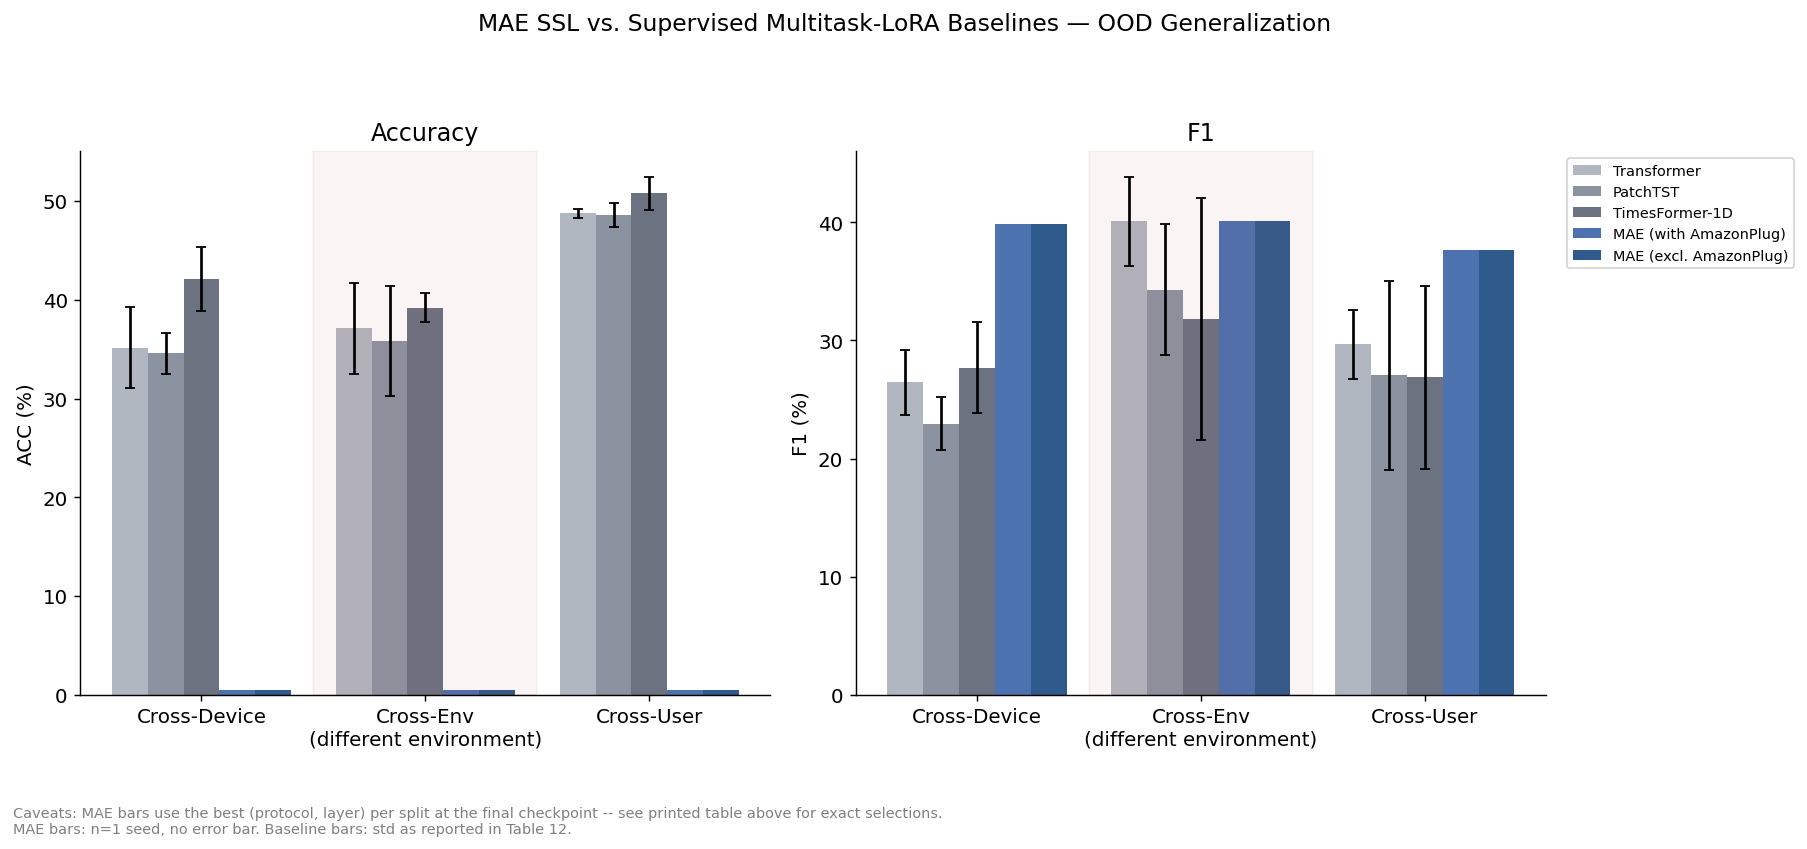

In [55]:

if not mae_variants:
    print("Skipping plot -- no MAE runs loaded. Fix the filters above first.")
else:
    g_model_order = ["Transformer", "PatchTST", "TimesFormer-1D"] + list(mae_variants.keys())
    g_model_colors = {
        "Transformer": "#B0B7C0", "PatchTST": "#8C93A0", "TimesFormer-1D": "#6B7280",
        "MAE (with AmazonPlug)": "#4C72B0", "MAE (excl. AmazonPlug)": "#2E5A8C",
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    for ax, metric in zip(axes, ["acc", "f1"]):
        x = np.arange(len(G_TEST_SPLITS))
        width = 0.8 / len(g_model_order)
        for i, model in enumerate(g_model_order):
            means, stds = [], []
            for split in G_TEST_SPLITS:
                row = comparison_df[(comparison_df.model == model) & (comparison_df.split == split)]
                if row.empty or pd.isna(row[f"{metric}_mean"].values[0]):
                    means.append(0)
                    stds.append(0)
                else:
                    means.append(row[f"{metric}_mean"].values[0])
                    stds.append(row[f"{metric}_std"].values[0])
            offset = (i - (len(g_model_order) - 1) / 2) * width
            yerr = stds if any(s > 0 for s in stds) else None
            ax.bar(x + offset, means, width=width, yerr=yerr, capsize=3,
                   label=model, color=g_model_colors.get(model))

        ax.axvspan(x[G_TEST_SPLITS.index("test_cross_env")] - 0.5,
                    x[G_TEST_SPLITS.index("test_cross_env")] + 0.5, color="#C44E52", alpha=0.06)
        ax.set_xticks(x)
        ax.set_xticklabels([G_SPLIT_LABELS[s] for s in G_TEST_SPLITS])
        ax.set_ylabel(f"{metric.upper()} (%)")
        ax.set_title("Accuracy" if metric == "acc" else "F1")

    axes[1].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")

    g_caveat_lines = [
        "Caveats: MAE bars use the best (protocol, layer) per split at the final checkpoint -- see printed table above for exact selections.",
    ]
    if "MAE (with AmazonPlug)" not in mae_variants:
        g_caveat_lines.append("Only the AmazonPlug-excluded MAE run was available -- baseline numbers "
                               "(Table 12) may use the full dataset, so this is not a fully controlled comparison.")
    g_caveat_lines.append("MAE bars: n=1 seed, no error bar. Baseline bars: std as reported in Table 12.")

    fig.suptitle("MAE SSL vs. Supervised Multitask-LoRA Baselines — OOD Generalization", y=1.06, fontsize=13)
    fig.text(0.01, -0.05, "\n".join(g_caveat_lines), fontsize=8, color="gray", ha="left", va="top")

    fig.tight_layout()
    fig.savefig(FIG_DIR / "mae_vs_table12_baseline_ood.png", dpi=150, bbox_inches="tight")
    plt.show()


## Section H — Best-Performing Layer, Per Group, Per Split

Grounded in the real file audit: for every group already loaded above (`ratio_enc6_groups`,
`ratio_groups`, `strategy_groups`, `strategy_enc12_groups`, `patch_groups`, `patch_enc12_groups`),
and for every group key (a mask ratio value, a strategy name, a patch size), this scans every
(layer, protocol) combination **averaged across the group's seeds** at the final checkpoint, and
picks the single best-performing one per split.

This directly answers "which layer actually wins" per ablation axis — rather than assuming the
deepest layer or a fixed layer is best, which your own memory notes is *not* a safe assumption
(rankings reverse across encoder depth / seed).

Run the loading cells for whichever sections you care about above first (A0/A/B/D/C/E) — this
section only uses groups that already exist in the kernel; any group not yet loaded is skipped
with a message rather than erroring.


In [56]:

H_PROTOCOLS = ("knn", "lp")  # extend with "mlp" if you want it considered too


def best_layer_across_seeds(runs, splits=TEST_SPLITS, protocols=H_PROTOCOLS, checkpoint=None):
    # For a list of runs sharing one group key (e.g. all seeds at mask_ratio=0.75), and for
    # each split: average each (layer, protocol) combination's accuracy across the group's seeds
    # at the final checkpoint, then return the single best-averaged (layer, protocol).
    # Returns {split: {"protocol", "layer", "mean_acc", "std_acc", "n_seeds", "mean_f1"}}.
    if not runs:
        return {}
    checkpoint = checkpoint or get_checkpoints(runs[0])[-1]
    layers = get_layers(runs[0])

    out = {}
    for split in splits:
        best = None
        for layer in layers:
            for p in protocols:
                accs, f1s = [], []
                for r in runs:
                    ckpts = get_checkpoints(r)
                    ckpt = checkpoint if checkpoint in ckpts else ckpts[-1]
                    entry = r["evals"].get(ckpt, {}).get(layer, {}).get(split)
                    if entry is None:
                        continue
                    acc = entry.get(f"{p}_acc")
                    if acc is None:
                        continue
                    accs.append(acc)
                    f1s.append(entry.get(f"{p}_f1"))
                if not accs:
                    continue
                mean_acc = float(np.mean(accs))
                if best is None or mean_acc > best["mean_acc"]:
                    valid_f1 = [f for f in f1s if f is not None]
                    best = {
                        "protocol": p, "layer": layer,
                        "mean_acc": mean_acc, "std_acc": float(np.std(accs)),
                        "n_seeds": len(accs),
                        "mean_f1": float(np.mean(valid_f1)) if valid_f1 else None,
                    }
        out[split] = best
    return out


def build_best_layer_table(groups, axis_name, group_label_fmt="{k}"):
    # Applies best_layer_across_seeds() to every key in `groups`, returns a tidy DataFrame:
    # one row per (group key, split), with the winning protocol/layer and its accuracy.
    rows = []
    for key in sorted(groups.keys(), key=str):
        runs = groups[key]
        best = best_layer_across_seeds(runs)
        for split, b in best.items():
            if b is None:
                continue
            rows.append(dict(
                axis=axis_name, group_key=key, group_label=group_label_fmt.format(k=key),
                split=split, protocol=b["protocol"], layer=b["layer"],
                mean_acc=b["mean_acc"], std_acc=b["std_acc"], n_seeds=b["n_seeds"],
                mean_f1=b["mean_f1"],
            ))
    return pd.DataFrame(rows)


**Build the table for every section that's currently loaded.** Prints each one as plain
text first, so you can eyeball the winning (protocol, layer) per split before anything gets
plotted — consistent with how Section G's comparison table was reviewed before plotting.


In [57]:

import pandas as pd

H_SECTION_SPECS = [
    ("ratio_enc6_groups", "A0: mask ratio (enc6)", "mask={k}"),
    ("ratio_groups", "A: mask ratio (enc12)", "mask={k}"),
    ("strategy_groups", "B: mask strategy (enc6)", "{k}"),
    ("strategy_enc12_groups", "D: mask strategy (enc12)", "{k}"),
    ("patch_groups", "C: patch size (enc6)", "{k}x{k}"),
    ("patch_enc12_groups", "E: patch size (enc12)", "{k}x{k}"),
]

best_layer_tables = {}  # axis_name -> DataFrame, kept for the plotting cell below

for var_name, axis_name, label_fmt in H_SECTION_SPECS:
    groups = globals().get(var_name)
    if not groups:
        print(f"[skip] '{var_name}' not loaded (empty or not run yet) -- run that section's "
              f"loading cell above first if you want it included here.")
        continue
    df = build_best_layer_table(groups, axis_name, group_label_fmt=label_fmt)
    best_layer_tables[axis_name] = df
    print(f"\n=== {axis_name} ===")
    with pd.option_context("display.max_rows", None, "display.width", 140):
        print(df[["group_label", "split", "protocol", "layer", "mean_acc", "std_acc", "n_seeds"]]
              .to_string(index=False))

if not best_layer_tables:
    print("\nNo sections loaded yet -- run at least one of A0/A/B/D/C/E's loading cells above, "
          "then re-run this cell.")



=== A0: mask ratio (enc6) ===
group_label             split protocol   layer  mean_acc  std_acc  n_seeds
   mask=0.5           test_id      knn layer_6  0.954042 0.000978        2
   mask=0.5 test_cross_device       lp layer_1  0.508566 0.008410        2
   mask=0.5    test_cross_env       lp layer_1  0.484662 0.013534        2
   mask=0.5   test_cross_user       lp layer_1  0.506235 0.006772        2
  mask=0.75           test_id      knn layer_3  0.952195 0.002046        3
  mask=0.75 test_cross_device       lp layer_1  0.490569 0.022638        3
  mask=0.75    test_cross_env       lp layer_1  0.471579 0.008199        3
  mask=0.75   test_cross_user       lp layer_1  0.498500 0.001180        3
 mask=0.875           test_id      knn layer_3  0.950674 0.001626        3
 mask=0.875 test_cross_device       lp layer_1  0.482677 0.024606        3
 mask=0.875    test_cross_env       lp layer_1  0.463158 0.011259        3
 mask=0.875   test_cross_user       lp layer_1  0.501225 0.008686    

**Plot: best-layer accuracy per group key, one panel per loaded section.** Each point is
annotated with the winning (protocol, layer) so the figure doubles as the "which layer wins"
answer, not just "what's the accuracy". `test_id` and OOD splits are both shown — OOD splits are
what actually matters for the generalization claim, `test_id` is shown for contrast.


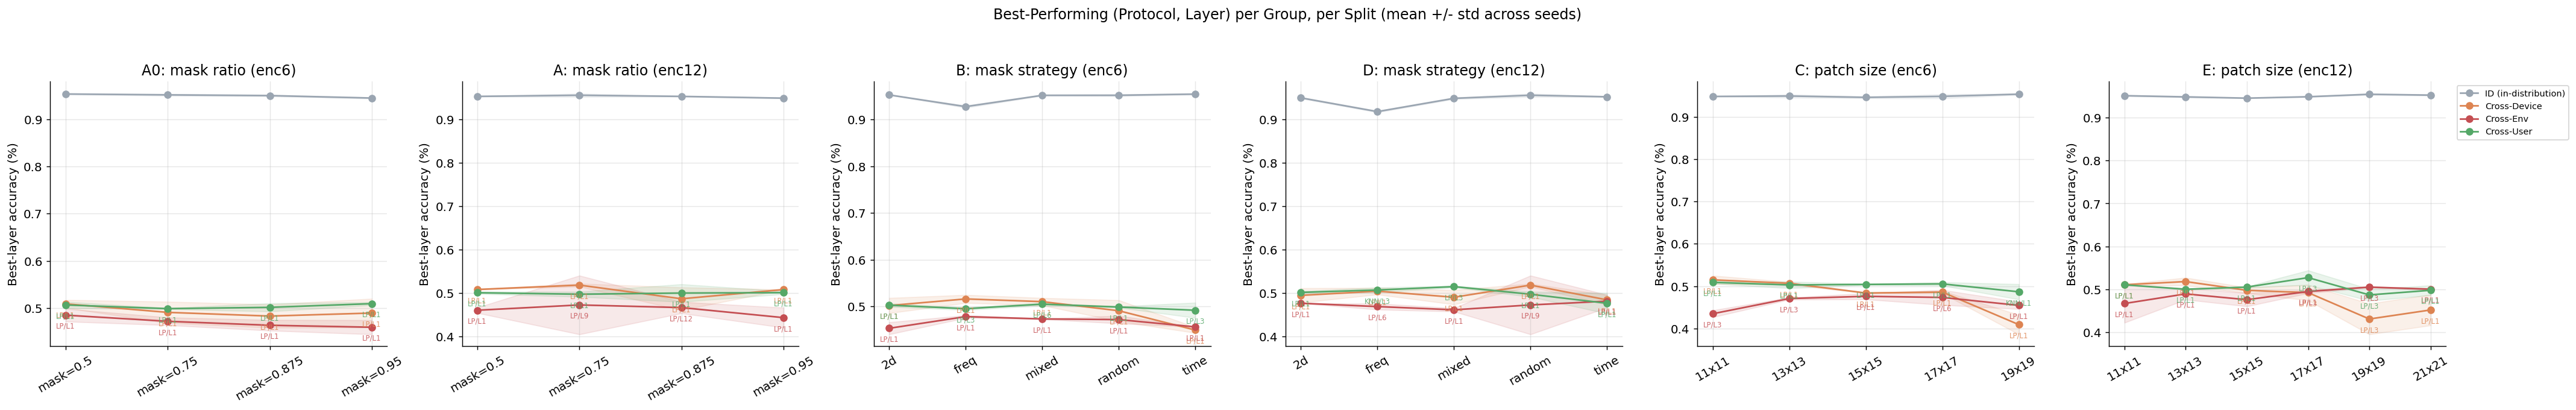

In [58]:

if best_layer_tables:
    n_sections = len(best_layer_tables)
    fig, axes = plt.subplots(1, n_sections, figsize=(5.5 * n_sections, 5), squeeze=False)
    axes = axes[0]

    split_colors = {"test_id": "#9AA5B1", "test_cross_device": "#DD8452",
                     "test_cross_env": "#C44E52", "test_cross_user": "#55A868"}

    for ax, (axis_name, df) in zip(axes, best_layer_tables.items()):
        group_labels_ordered = list(dict.fromkeys(df.sort_values("group_key")["group_label"]))
        x = np.arange(len(group_labels_ordered))

        for split in TEST_SPLITS:
            sub = df[df.split == split].set_index("group_label").reindex(group_labels_ordered)
            ax.plot(x, sub["mean_acc"], marker="o", label=SPLIT_LABELS.get(split, split),
                    color=split_colors.get(split))
            ax.fill_between(x, sub["mean_acc"] - sub["std_acc"], sub["mean_acc"] + sub["std_acc"],
                             color=split_colors.get(split), alpha=0.12)
            # annotate the winning (protocol, layer) at each point for the OOD-relevant splits only
            if split != "test_id":
                for xi, (_, row) in zip(x, sub.iterrows()):
                    if pd.isna(row["mean_acc"]):
                        continue
                    ax.annotate(f"{row['protocol'].upper()}/{row['layer'].replace('layer_', 'L')}",
                                (xi, row["mean_acc"]), textcoords="offset points", xytext=(0, -12),
                                fontsize=6.5, ha="center", color=split_colors.get(split), alpha=0.85)

        ax.set_xticks(x)
        ax.set_xticklabels(group_labels_ordered, rotation=30 if n_sections > 1 else 0)
        ax.set_title(axis_name)
        ax.set_ylabel("Best-layer accuracy (%)")
        ax.grid(alpha=0.3)

    axes[-1].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.suptitle("Best-Performing (Protocol, Layer) per Group, per Split "
                 "(mean +/- std across seeds)", y=1.04)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "best_layer_summary_all_sections.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Nothing to plot -- see the message(s) above.")


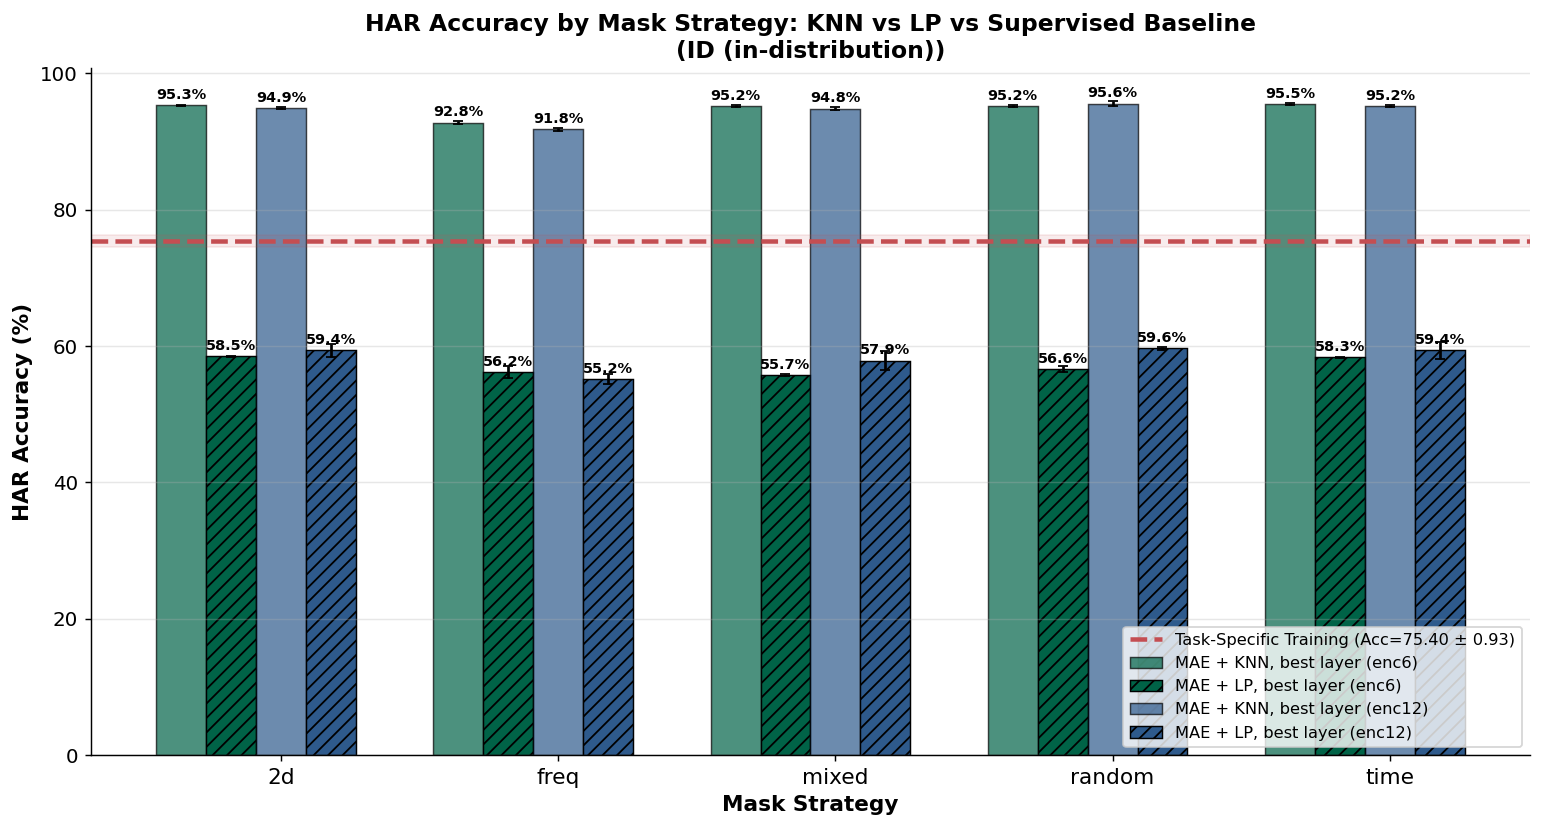

In [59]:
# ============================================================
# COMPARE HAR ACCURACY ACROSS MASK STRATEGIES -- REAL KNN vs REAL LP
# ============================================================
# Fix for the previous bug: LP bars were literally re-plotting the KNN/best-layer series
# (see the "Replace with actual LP data if available" comment in the old code -- that TODO
# was never done). This version calls best_layer_across_seeds() with a FIXED protocol
# ("knn" only, or "lp" only) so the two series are genuinely independent, not the same
# array plotted twice.
# Uses strategy_groups / strategy_enc12_groups directly (the raw groups from Section B/D's
# loading cell) -- NOT best_layer_tables, since best_layer_tables already collapsed the
# protocol choice down to "whichever won" and can't be un-mixed after the fact.

BASELINE_ACC = 75.40
BASELINE_STD = 0.93
SPLIT_TO_PLOT = "test_id"

assert 'strategy_groups' in globals() and strategy_groups, "Run Section B's loading cell first."
assert 'strategy_enc12_groups' in globals() and strategy_enc12_groups, "Run Section D's loading cell first."

strategy_order = ["2d", "freq", "mixed", "random", "time"]

def _fixed_protocol_series(groups, protocol, split):
    means, stds, layers = [], [], []
    for strat in strategy_order:
        runs = groups.get(strat, [])
        best = best_layer_across_seeds(runs, protocols=(protocol,))  # <<< locked to one protocol
        b = best.get(split)
        if b is None:
            means.append(np.nan); stds.append(np.nan); layers.append(None)
        else:
            means.append(b["mean_acc"] * 100)   # 0-1 fraction -> percent, same as before
            stds.append(b["std_acc"] * 100)
            layers.append(b["layer"])
    return np.array(means), np.array(stds), layers

acc6_knn,  std6_knn,  layer6_knn  = _fixed_protocol_series(strategy_groups,       "knn", SPLIT_TO_PLOT)
acc6_lp,   std6_lp,   layer6_lp   = _fixed_protocol_series(strategy_groups,       "lp",  SPLIT_TO_PLOT)
acc12_knn, std12_knn, layer12_knn = _fixed_protocol_series(strategy_enc12_groups, "knn", SPLIT_TO_PLOT)
acc12_lp,  std12_lp,  layer12_lp  = _fixed_protocol_series(strategy_enc12_groups, "lp",  SPLIT_TO_PLOT)

x = np.arange(len(strategy_order))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 6.5))

bars6_knn  = ax.bar(x - width*2, acc6_knn,  width, yerr=std6_knn,  capsize=3,
                     label="MAE + KNN, best layer (enc6)",  color="#006347", alpha=0.7,
                     edgecolor="black", linewidth=0.8)
bars6_lp   = ax.bar(x - width,   acc6_lp,   width, yerr=std6_lp,   capsize=3,
                     label="MAE + LP, best layer (enc6)",   color="#006347", alpha=1.0,
                     edgecolor="black", linewidth=0.8, hatch="///")
bars12_knn = ax.bar(x,           acc12_knn, width, yerr=std12_knn, capsize=3,
                     label="MAE + KNN, best layer (enc12)", color="#2E5A8C", alpha=0.7,
                     edgecolor="black", linewidth=0.8)
bars12_lp  = ax.bar(x + width,   acc12_lp,  width, yerr=std12_lp,  capsize=3,
                     label="MAE + LP, best layer (enc12)",  color="#2E5A8C", alpha=1.0,
                     edgecolor="black", linewidth=0.8, hatch="///")

ax.axhline(BASELINE_ACC, color="#C44E52", linestyle="--", linewidth=2.5,
           label=f"Task-Specific Training (Acc={BASELINE_ACC:.2f} ± {BASELINE_STD:.2f})")
ax.axhspan(BASELINE_ACC - BASELINE_STD, BASELINE_ACC + BASELINE_STD, color="#C44E52", alpha=0.10)

for bars in [bars6_knn, bars6_lp, bars12_knn, bars12_lp]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}%",
                    ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(strategy_order, fontsize=12)
ax.set_xlabel("Mask Strategy", fontsize=12, fontweight="bold")
ax.set_ylabel("HAR Accuracy (%)", fontsize=12, fontweight="bold")
ax.set_title(f"HAR Accuracy by Mask Strategy: KNN vs LP vs Supervised Baseline\n"
             f"({SPLIT_LABELS.get(SPLIT_TO_PLOT, SPLIT_TO_PLOT)})", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3, axis="y")

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, max(ymax, BASELINE_ACC + BASELINE_STD + 12))
plt.tight_layout()
plt.show()

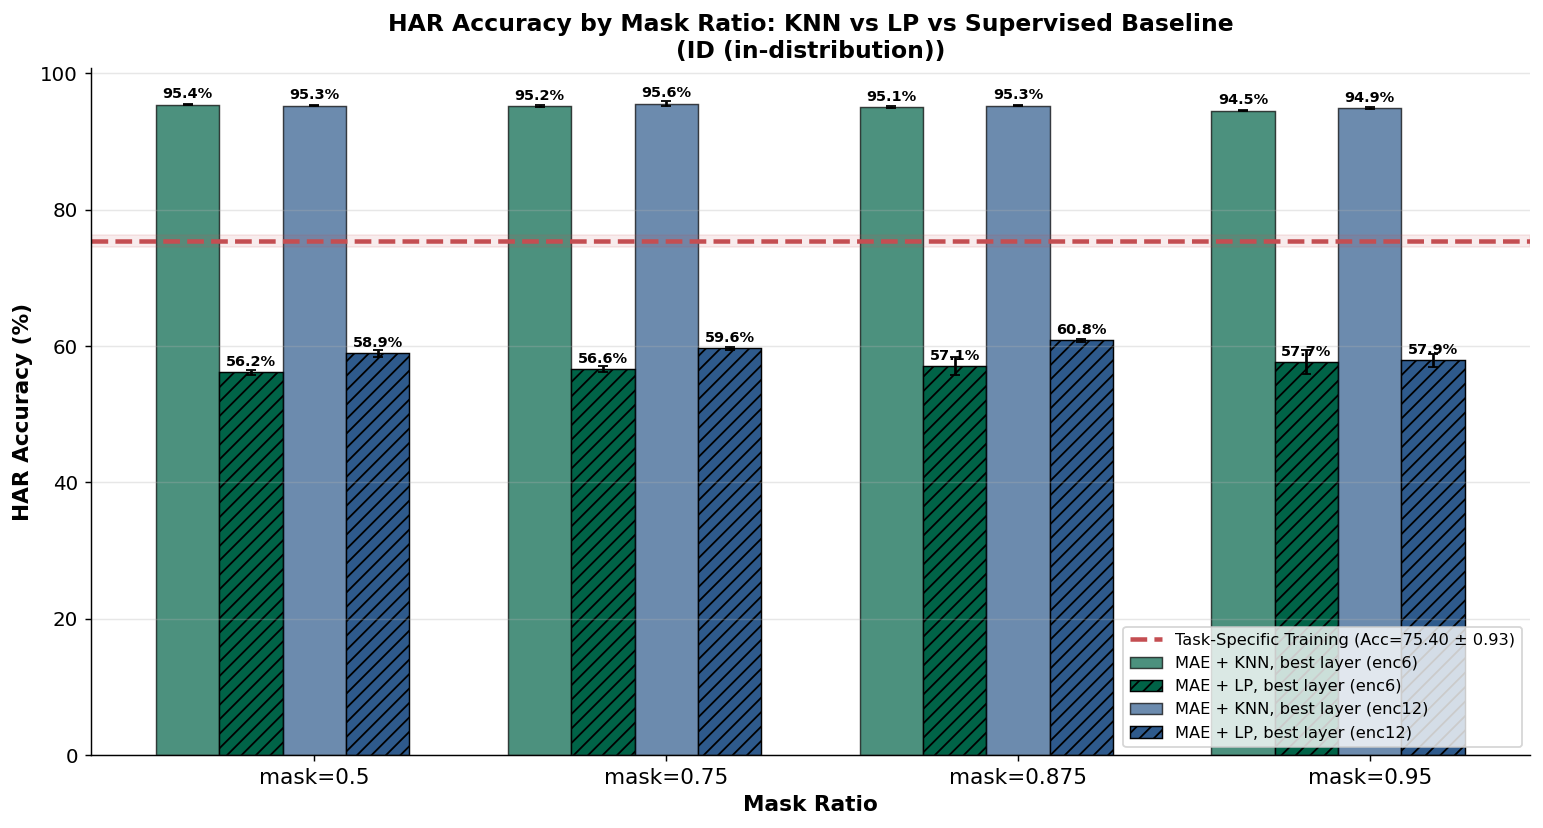

In [60]:
# ============================================================
# COMPARE HAR ACCURACY ACROSS MASK RATIOS -- REAL KNN vs REAL LP
# ============================================================
# Same fix as the mask-strategy version: pulls independent KNN-only and LP-only series
# via best_layer_across_seeds(protocols=(...,)) instead of best_layer_tables (which already
# collapsed KNN/LP down to "whichever won" and can't be un-mixed after the fact).
# Uses ratio_enc6_groups / ratio_groups directly (raw groups from Section A0/A's loading cell).

BASELINE_ACC = 75.40
BASELINE_STD = 0.93
SPLIT_TO_PLOT = "test_id"

assert 'ratio_enc6_groups' in globals() and ratio_enc6_groups, "Run Section A0's loading cell first."
assert 'ratio_groups' in globals() and ratio_groups, "Run Section A's loading cell first."

ratio_order = [0.5, 0.75, 0.875, 0.95]                        # <<< CHANGED: numeric ratios, not strategy names
ratio_display_labels = [f"mask={r}" for r in ratio_order]     # <<< CHANGED: x-tick text (group KEYS in ratio_*_groups are the raw float, not "mask={k}")

def _fixed_protocol_series(groups, protocol, split):
    means, stds, layers = [], [], []
    for r in ratio_order:                                      # <<< CHANGED: iterate ratio_order (floats), not strategy_order (strings)
        runs = groups.get(r, [])                                # <<< CHANGED: lookup key is the float itself
        best = best_layer_across_seeds(runs, protocols=(protocol,))
        b = best.get(split)
        if b is None:
            means.append(np.nan); stds.append(np.nan); layers.append(None)
        else:
            means.append(b["mean_acc"] * 100)
            stds.append(b["std_acc"] * 100)
            layers.append(b["layer"])
    return np.array(means), np.array(stds), layers

acc6_knn,  std6_knn,  layer6_knn  = _fixed_protocol_series(ratio_enc6_groups, "knn", SPLIT_TO_PLOT)  # <<< CHANGED: groups var
acc6_lp,   std6_lp,   layer6_lp   = _fixed_protocol_series(ratio_enc6_groups, "lp",  SPLIT_TO_PLOT)  # <<< CHANGED: groups var
acc12_knn, std12_knn, layer12_knn = _fixed_protocol_series(ratio_groups,      "knn", SPLIT_TO_PLOT)  # <<< CHANGED: groups var
acc12_lp,  std12_lp,  layer12_lp  = _fixed_protocol_series(ratio_groups,      "lp",  SPLIT_TO_PLOT)  # <<< CHANGED: groups var

x = np.arange(len(ratio_order))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 6.5))

bars6_knn  = ax.bar(x - width*2, acc6_knn,  width, yerr=std6_knn,  capsize=3,
                     label="MAE + KNN, best layer (enc6)",  color="#006347", alpha=0.7,
                     edgecolor="black", linewidth=0.8)
bars6_lp   = ax.bar(x - width,   acc6_lp,   width, yerr=std6_lp,   capsize=3,
                     label="MAE + LP, best layer (enc6)",   color="#006347", alpha=1.0,
                     edgecolor="black", linewidth=0.8, hatch="///")
bars12_knn = ax.bar(x,           acc12_knn, width, yerr=std12_knn, capsize=3,
                     label="MAE + KNN, best layer (enc12)", color="#2E5A8C", alpha=0.7,
                     edgecolor="black", linewidth=0.8)
bars12_lp  = ax.bar(x + width,   acc12_lp,  width, yerr=std12_lp,  capsize=3,
                     label="MAE + LP, best layer (enc12)",  color="#2E5A8C", alpha=1.0,
                     edgecolor="black", linewidth=0.8, hatch="///")

ax.axhline(BASELINE_ACC, color="#C44E52", linestyle="--", linewidth=2.5,
           label=f"Task-Specific Training (Acc={BASELINE_ACC:.2f} ± {BASELINE_STD:.2f})")
ax.axhspan(BASELINE_ACC - BASELINE_STD, BASELINE_ACC + BASELINE_STD, color="#C44E52", alpha=0.10)

for bars in [bars6_knn, bars6_lp, bars12_knn, bars12_lp]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}%",
                    ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(ratio_display_labels, fontsize=12)         # <<< CHANGED: was strategy_order
ax.set_xlabel("Mask Ratio", fontsize=12, fontweight="bold")   # <<< CHANGED: was "Mask Strategy"
ax.set_ylabel("HAR Accuracy (%)", fontsize=12, fontweight="bold")
ax.set_title(f"HAR Accuracy by Mask Ratio: KNN vs LP vs Supervised Baseline\n"  # <<< CHANGED: title text
             f"({SPLIT_LABELS.get(SPLIT_TO_PLOT, SPLIT_TO_PLOT)})", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3, axis="y")

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, max(ymax, BASELINE_ACC + BASELINE_STD + 12))
plt.tight_layout()
plt.show()

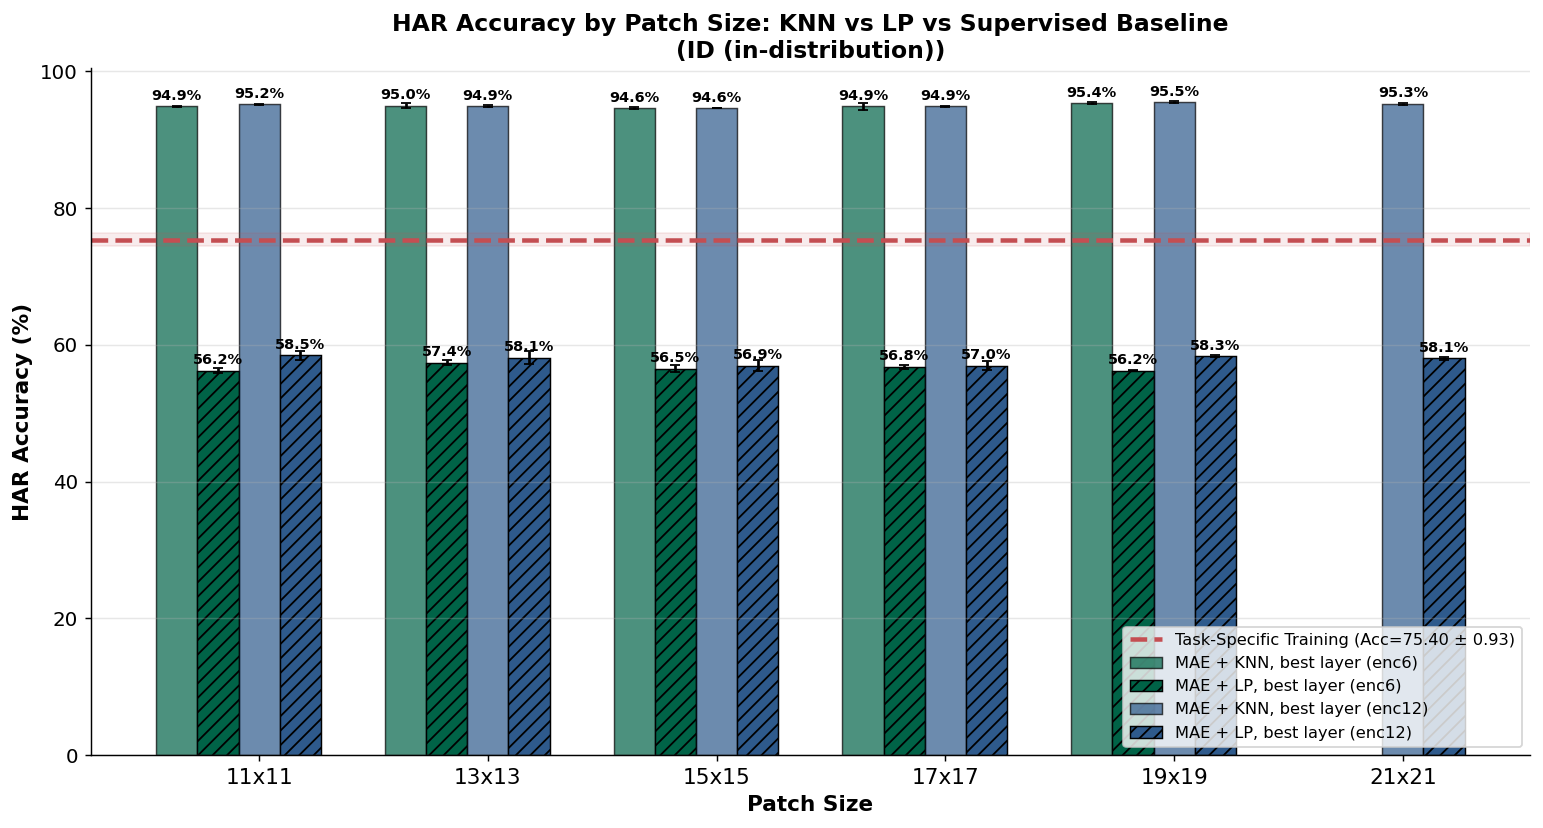

In [61]:
# ============================================================
# COMPARE HAR ACCURACY ACROSS PATCH SIZES -- REAL KNN vs REAL LP
# ============================================================
# Same fix as the mask-ratio/mask-strategy versions: pulls independent KNN-only and LP-only
# series via best_layer_across_seeds(protocols=(...,)) instead of best_layer_tables.
# Uses patch_groups / patch_enc12_groups directly (raw groups from Section C/E's loading cell).

BASELINE_ACC = 75.40
BASELINE_STD = 0.93
SPLIT_TO_PLOT = "test_id"

assert 'patch_groups' in globals() and patch_groups, "Run Section C's loading cell first."
assert 'patch_enc12_groups' in globals() and patch_enc12_groups, "Run Section E's loading cell first."

# <<< CHANGED: patch sizes, union of both C (enc6) and E (enc12) so both series line up on
# the same x-axis. Per your real audit, enc6 only goes to 19x19 while enc12 goes to 21x21 --
# any group missing a size just comes back NaN below and won't draw a bar for it, no error.
patch_order = [11, 13, 15, 17, 19, 21]
patch_display_labels = [f"{p}x{p}" for p in patch_order]

def _fixed_protocol_series(groups, protocol, split):
    means, stds, layers = [], [], []
    for p in patch_order:                                       # <<< CHANGED: iterate patch_order (ints), not ratio_order
        runs = groups.get(p, [])                                 # <<< CHANGED: lookup key is the int patch_h itself
        best = best_layer_across_seeds(runs, protocols=(protocol,))
        b = best.get(split)
        if b is None:
            means.append(np.nan); stds.append(np.nan); layers.append(None)
        else:
            means.append(b["mean_acc"] * 100)
            stds.append(b["std_acc"] * 100)
            layers.append(b["layer"])
    return np.array(means), np.array(stds), layers

acc6_knn,  std6_knn,  layer6_knn  = _fixed_protocol_series(patch_groups,       "knn", SPLIT_TO_PLOT)  # <<< CHANGED: groups var
acc6_lp,   std6_lp,   layer6_lp   = _fixed_protocol_series(patch_groups,       "lp",  SPLIT_TO_PLOT)  # <<< CHANGED: groups var
acc12_knn, std12_knn, layer12_knn = _fixed_protocol_series(patch_enc12_groups, "knn", SPLIT_TO_PLOT)  # <<< CHANGED: groups var
acc12_lp,  std12_lp,  layer12_lp  = _fixed_protocol_series(patch_enc12_groups, "lp",  SPLIT_TO_PLOT)  # <<< CHANGED: groups var

x = np.arange(len(patch_order))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 6.5))

bars6_knn  = ax.bar(x - width*2, acc6_knn,  width, yerr=std6_knn,  capsize=3,
                     label="MAE + KNN, best layer (enc6)",  color="#006347", alpha=0.7,
                     edgecolor="black", linewidth=0.8)
bars6_lp   = ax.bar(x - width,   acc6_lp,   width, yerr=std6_lp,   capsize=3,
                     label="MAE + LP, best layer (enc6)",   color="#006347", alpha=1.0,
                     edgecolor="black", linewidth=0.8, hatch="///")
bars12_knn = ax.bar(x,           acc12_knn, width, yerr=std12_knn, capsize=3,
                     label="MAE + KNN, best layer (enc12)", color="#2E5A8C", alpha=0.7,
                     edgecolor="black", linewidth=0.8)
bars12_lp  = ax.bar(x + width,   acc12_lp,  width, yerr=std12_lp,  capsize=3,
                     label="MAE + LP, best layer (enc12)",  color="#2E5A8C", alpha=1.0,
                     edgecolor="black", linewidth=0.8, hatch="///")

ax.axhline(BASELINE_ACC, color="#C44E52", linestyle="--", linewidth=2.5,
           label=f"Task-Specific Training (Acc={BASELINE_ACC:.2f} ± {BASELINE_STD:.2f})")
ax.axhspan(BASELINE_ACC - BASELINE_STD, BASELINE_ACC + BASELINE_STD, color="#C44E52", alpha=0.10)

for bars in [bars6_knn, bars6_lp, bars12_knn, bars12_lp]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}%",
                    ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(patch_display_labels, fontsize=12)          # <<< CHANGED: was ratio_display_labels
ax.set_xlabel("Patch Size", fontsize=12, fontweight="bold")    # <<< CHANGED: was "Mask Ratio"
ax.set_ylabel("HAR Accuracy (%)", fontsize=12, fontweight="bold")
ax.set_title(f"HAR Accuracy by Patch Size: KNN vs LP vs Supervised Baseline\n"  # <<< CHANGED: title text
             f"({SPLIT_LABELS.get(SPLIT_TO_PLOT, SPLIT_TO_PLOT)})", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3, axis="y")

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, max(ymax, BASELINE_ACC + BASELINE_STD + 12))
plt.tight_layout()
plt.show()

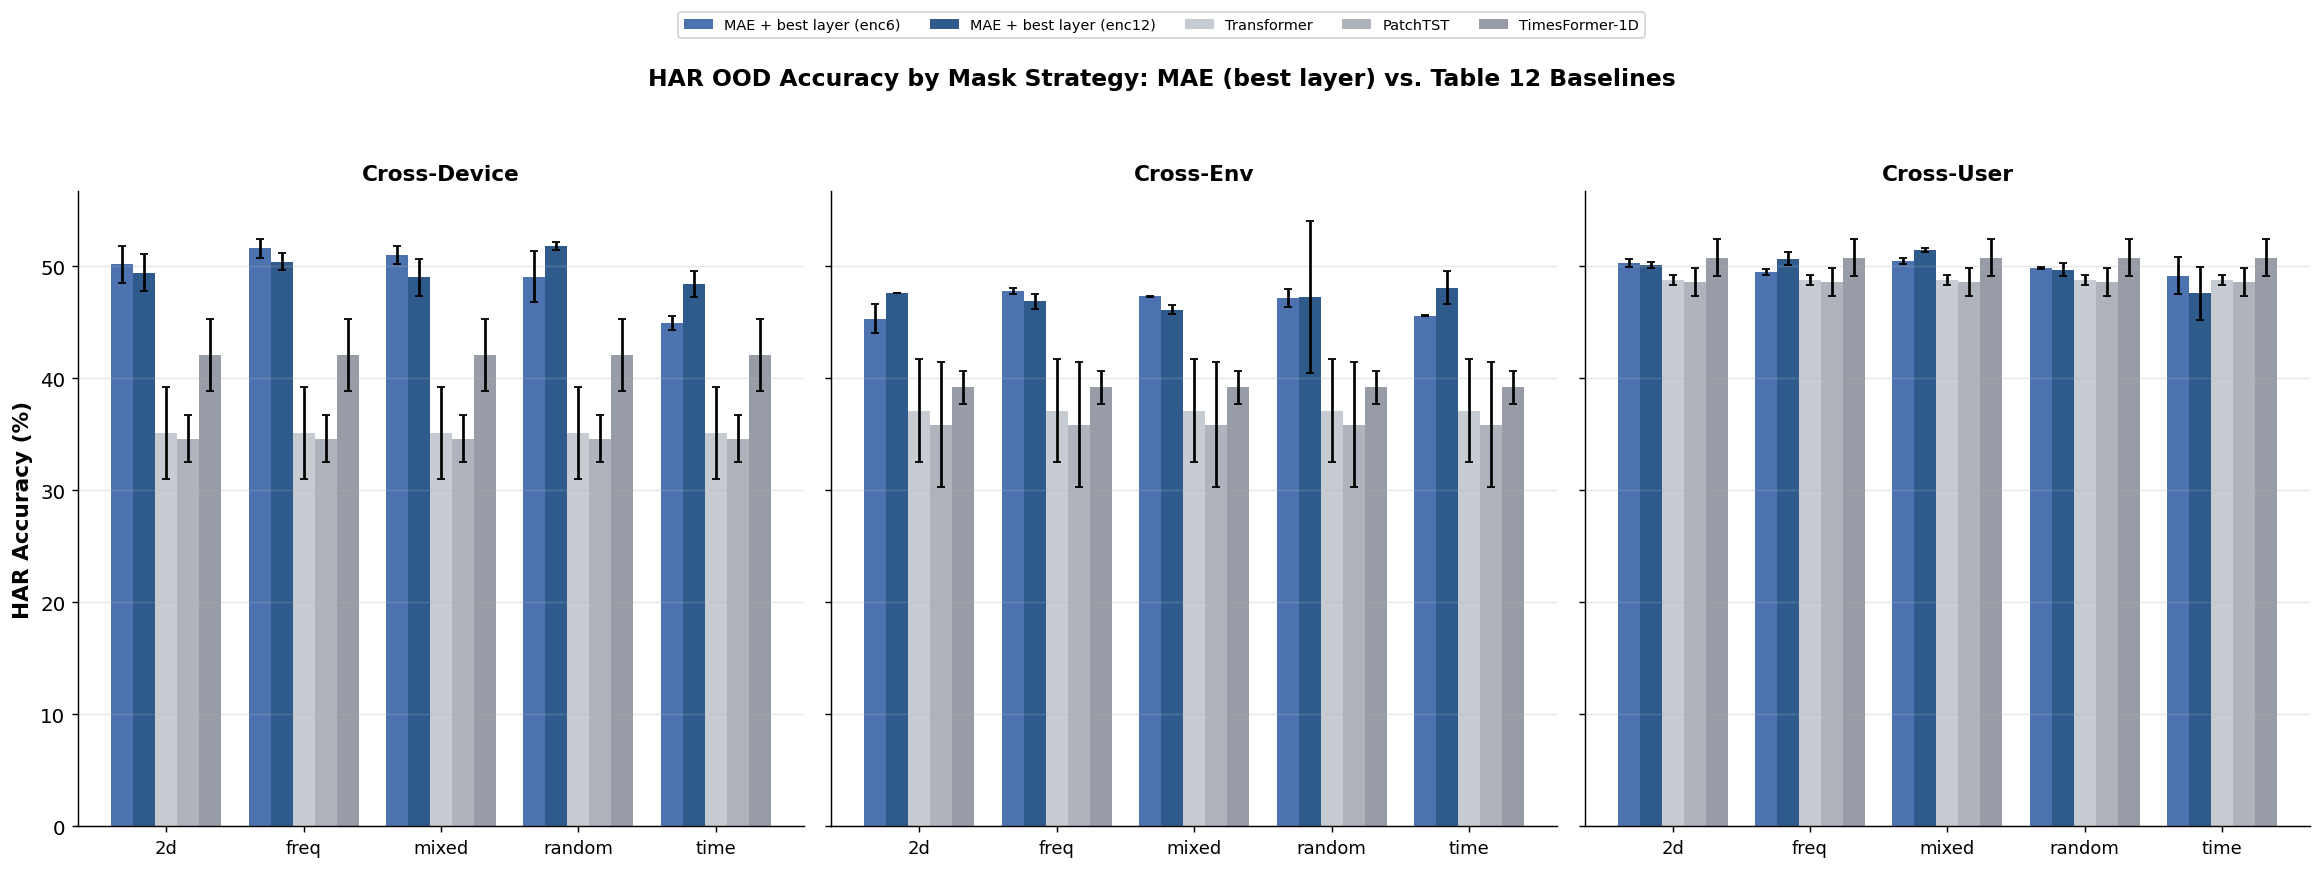

In [62]:
# ============================================================
# HAR OOD ACCURACY BY MASK STRATEGY vs. TABLE 12 BASELINES
# ============================================================
# 3 panels: test_cross_device / test_cross_env / test_cross_user
# Baseline (transformer / patchtst / timesformer1d, from Table 12) shown as bars,
# repeated at every mask-strategy x position so it's a live reference in each panel.
# Uses best_layer_tables from Section H and TABLE12_BASELINE from Section G --
# run both of those cells first.

OOD_SPLITS = ["test_cross_device", "test_cross_env", "test_cross_user"]

df_b = best_layer_tables.get("B: mask strategy (enc6)")
df_d = best_layer_tables.get("D: mask strategy (enc12)")
assert df_b is not None and df_d is not None, "Run Section H's table-building cell first."
assert "TABLE12_BASELINE" in globals(), "Run Section G's baseline cell first."

strategy_order = ["2d", "freq", "mixed", "random", "time"]

def _extract(df, split):
    sub = df[df.split == split].set_index("group_label").reindex(strategy_order)
    return sub["mean_acc"] * 100, sub["std_acc"] * 100, sub["protocol"], sub["layer"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

x = np.arange(len(strategy_order))
n_bars = 5  # MAE-enc6, MAE-enc12, Transformer, PatchTST, TimesFormer-1D
width = 0.8 / n_bars

mae_colors = {"enc6": "#4C72B0", "enc12": "#2E5A8C"}
baseline_colors = {"transformer": "#B0B7C0", "patchtst": "#8C93A0", "timesformer1d": "#6B7280"}
baseline_display = {"transformer": "Transformer", "patchtst": "PatchTST", "timesformer1d": "TimesFormer-1D"}

def _label_bars(ax, bars, values):  # <<< CHANGED: new helper -- numeric data labels instead of protocol/layer text
    for bar, v in zip(bars, values):
        if pd.notna(v):
            ax.annotate(f"{v:.1f}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                        textcoords="offset points", xytext=(0, 2), ha="center",
                        fontsize=6, rotation=90)

for ax, split in zip(axes, OOD_SPLITS):
    acc6, std6, proto6, layer6 = _extract(df_b, split)
    acc12, std12, proto12, layer12 = _extract(df_d, split)

    # bar 1: MAE enc6 best layer
    b1 = ax.bar(x + (0 - (n_bars-1)/2)*width, acc6, width, yerr=std6, capsize=2,
                color=mae_colors["enc6"], label="MAE + best layer (enc6)" if ax is axes[0] else None)
    # bar 2: MAE enc12 best layer
    b2 = ax.bar(x + (1 - (n_bars-1)/2)*width, acc12, width, yerr=std12, capsize=2,
                color=mae_colors["enc12"], label="MAE + best layer (enc12)" if ax is axes[0] else None)

    # bars 3-5: baseline models, broadcast to every strategy x-position (baseline doesn't
    # depend on mask strategy -- this repeats the same value at each tick as a live reference)
    baseline_bars = {}
    baseline_vals = {}
    for i, model_key in enumerate(["transformer", "patchtst", "timesformer1d"]):
        acc_mean, acc_std = TABLE12_BASELINE[model_key][split]["acc"]
        vals = np.full(len(strategy_order), acc_mean * 100)
        stds = np.full(len(strategy_order), acc_std * 100)
        bars = ax.bar(x + (2 + i - (n_bars-1)/2)*width, vals, width, yerr=stds, capsize=2,
                       color=baseline_colors[model_key], alpha=0.7,
                       label=baseline_display[model_key] if ax is axes[0] else None)
        baseline_bars[model_key] = bars
        baseline_vals[model_key] = vals

    # # numeric data labels on every bar (MAE + baseline)                    # <<< CHANGED: block replaces the old protocol/layer annotate loops
    # _label_bars(ax, b1, acc6)
    # _label_bars(ax, b2, acc12)
    # for model_key in ["transformer", "patchtst", "timesformer1d"]:
    #     _label_bars(ax, baseline_bars[model_key], baseline_vals[model_key])

    ax.set_xticks(x)
    ax.set_xticklabels(strategy_order, fontsize=10)
    ax.set_title(SPLIT_LABELS.get(split, split), fontsize=12, fontweight="bold")
    ax.grid(alpha=0.3, axis="y")

axes[0].set_ylabel("HAR Accuracy (%)", fontsize=12, fontweight="bold")
fig.suptitle("HAR OOD Accuracy by Mask Strategy: MAE (best layer) vs. Table 12 Baselines",
             fontsize=13, fontweight="bold", y=1.04)
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 1.12), ncol=5, fontsize=8)
fig.tight_layout()
plt.show()

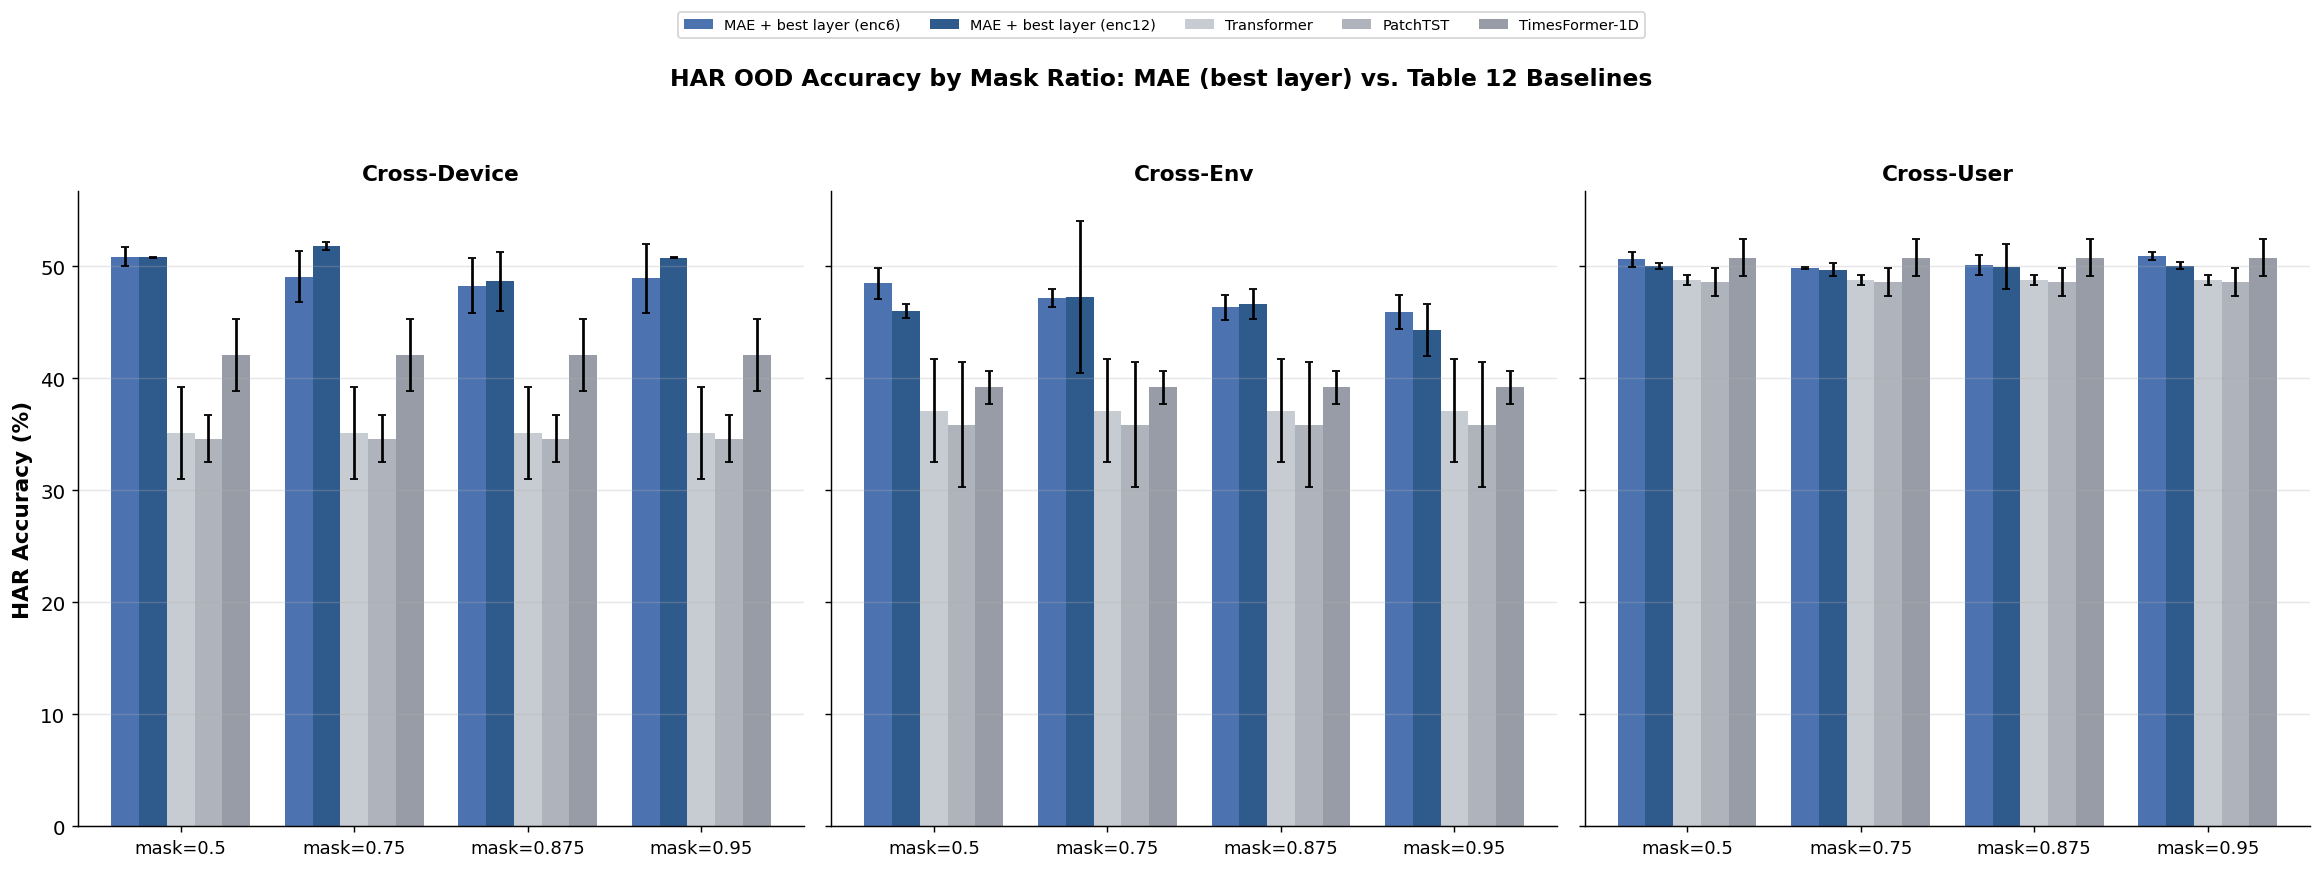

In [63]:
# ============================================================
# HAR OOD ACCURACY BY MASK STRATEGY vs. TABLE 12 BASELINES
# ============================================================
# 3 panels: test_cross_device / test_cross_env / test_cross_user
# Baseline (transformer / patchtst / timesformer1d, from Table 12) shown as bars,
# repeated at every mask-strategy x position so it's a live reference in each panel.
# Uses best_layer_tables from Section H and TABLE12_BASELINE from Section G --
# run both of those cells first.

OOD_SPLITS = ["test_cross_device", "test_cross_env", "test_cross_user"]

df_b = best_layer_tables.get("A0: mask ratio (enc6)")
df_d = best_layer_tables.get("A: mask ratio (enc12)")
assert df_b is not None and df_d is not None, "Run Section H's table-building cell first."
assert "TABLE12_BASELINE" in globals(), "Run Section G's baseline cell first."

strategy_order = ["mask=0.5", "mask=0.75", "mask=0.875", "mask=0.95"]
strategy_labels = [r.replace("mask=", "") for r in strategy_order]

def _extract(df, split):
    sub = df[df.split == split].set_index("group_label").reindex(strategy_order)
    return sub["mean_acc"] * 100, sub["std_acc"] * 100, sub["protocol"], sub["layer"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

x = np.arange(len(strategy_order))
n_bars = 5  # MAE-enc6, MAE-enc12, Transformer, PatchTST, TimesFormer-1D
width = 0.8 / n_bars

mae_colors = {"enc6": "#4C72B0", "enc12": "#2E5A8C"}
baseline_colors = {"transformer": "#B0B7C0", "patchtst": "#8C93A0", "timesformer1d": "#6B7280"}
baseline_display = {"transformer": "Transformer", "patchtst": "PatchTST", "timesformer1d": "TimesFormer-1D"}

def _label_bars(ax, bars, values):  # <<< CHANGED: new helper -- numeric data labels instead of protocol/layer text
    for bar, v in zip(bars, values):
        if pd.notna(v):
            ax.annotate(f"{v:.1f}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                        textcoords="offset points", xytext=(0, 2), ha="center",
                        fontsize=6, rotation=90)

for ax, split in zip(axes, OOD_SPLITS):
    acc6, std6, proto6, layer6 = _extract(df_b, split)
    acc12, std12, proto12, layer12 = _extract(df_d, split)

    # bar 1: MAE enc6 best layer
    b1 = ax.bar(x + (0 - (n_bars-1)/2)*width, acc6, width, yerr=std6, capsize=2,
                color=mae_colors["enc6"], label="MAE + best layer (enc6)" if ax is axes[0] else None)
    # bar 2: MAE enc12 best layer
    b2 = ax.bar(x + (1 - (n_bars-1)/2)*width, acc12, width, yerr=std12, capsize=2,
                color=mae_colors["enc12"], label="MAE + best layer (enc12)" if ax is axes[0] else None)

    # bars 3-5: baseline models, broadcast to every strategy x-position (baseline doesn't
    # depend on mask strategy -- this repeats the same value at each tick as a live reference)
    baseline_bars = {}
    baseline_vals = {}
    for i, model_key in enumerate(["transformer", "patchtst", "timesformer1d"]):
        acc_mean, acc_std = TABLE12_BASELINE[model_key][split]["acc"]
        vals = np.full(len(strategy_order), acc_mean * 100)
        stds = np.full(len(strategy_order), acc_std * 100)
        bars = ax.bar(x + (2 + i - (n_bars-1)/2)*width, vals, width, yerr=stds, capsize=2,
                       color=baseline_colors[model_key], alpha=0.7,
                       label=baseline_display[model_key] if ax is axes[0] else None)
        baseline_bars[model_key] = bars
        baseline_vals[model_key] = vals

    # # numeric data labels on every bar (MAE + baseline)                    # <<< CHANGED: block replaces the old protocol/layer annotate loops
    # _label_bars(ax, b1, acc6)
    # _label_bars(ax, b2, acc12)
    # for model_key in ["transformer", "patchtst", "timesformer1d"]:
    #     _label_bars(ax, baseline_bars[model_key], baseline_vals[model_key])

    ax.set_xticks(x)
    ax.set_xticklabels(strategy_order, fontsize=10)
    ax.set_title(SPLIT_LABELS.get(split, split), fontsize=12, fontweight="bold")
    ax.grid(alpha=0.3, axis="y")

axes[0].set_ylabel("HAR Accuracy (%)", fontsize=12, fontweight="bold")
fig.suptitle("HAR OOD Accuracy by Mask Ratio: MAE (best layer) vs. Table 12 Baselines",
             fontsize=13, fontweight="bold", y=1.04)
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 1.12), ncol=5, fontsize=8)
fig.tight_layout()
plt.show()

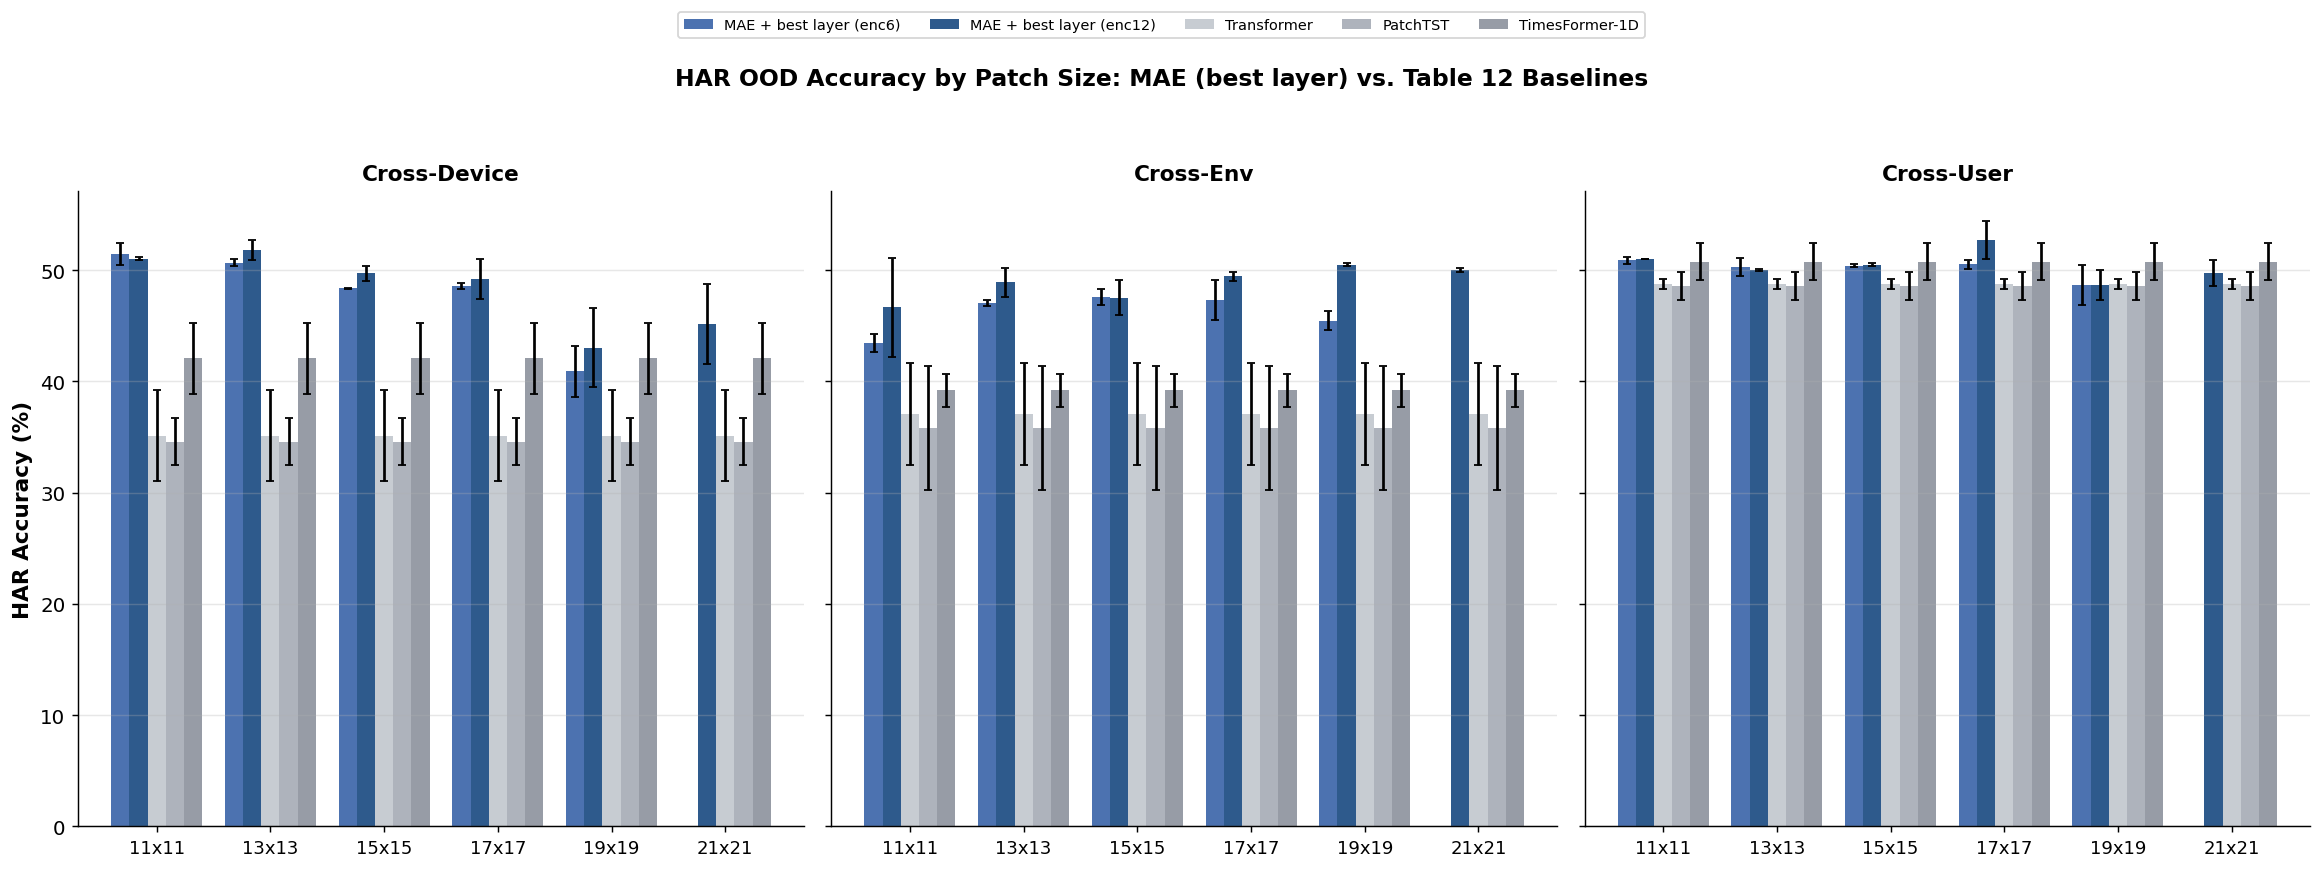

In [64]:
# ============================================================
# HAR OOD ACCURACY BY MASK STRATEGY vs. TABLE 12 BASELINES
# ============================================================
# 3 panels: test_cross_device / test_cross_env / test_cross_user
# Baseline (transformer / patchtst / timesformer1d, from Table 12) shown as bars,
# repeated at every mask-strategy x position so it's a live reference in each panel.
# Uses best_layer_tables from Section H and TABLE12_BASELINE from Section G --
# run both of those cells first.

OOD_SPLITS = ["test_cross_device", "test_cross_env", "test_cross_user"]

df_b = best_layer_tables.get("C: patch size (enc6)")
df_d = best_layer_tables.get("E: patch size (enc12)")
assert df_b is not None and df_d is not None, "Run Section H's table-building cell first."
assert "TABLE12_BASELINE" in globals(), "Run Section G's baseline cell first."

strategy_order = ["11x11", "13x13", "15x15", "17x17", "19x19", "21x21"]
strategy_labels = strategy_order

def _extract(df, split):
    sub = df[df.split == split].set_index("group_label").reindex(strategy_order)
    return sub["mean_acc"] * 100, sub["std_acc"] * 100, sub["protocol"], sub["layer"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

x = np.arange(len(strategy_order))
n_bars = 5  # MAE-enc6, MAE-enc12, Transformer, PatchTST, TimesFormer-1D
width = 0.8 / n_bars

mae_colors = {"enc6": "#4C72B0", "enc12": "#2E5A8C"}
baseline_colors = {"transformer": "#B0B7C0", "patchtst": "#8C93A0", "timesformer1d": "#6B7280"}
baseline_display = {"transformer": "Transformer", "patchtst": "PatchTST", "timesformer1d": "TimesFormer-1D"}

def _label_bars(ax, bars, values):  # <<< CHANGED: new helper -- numeric data labels instead of protocol/layer text
    for bar, v in zip(bars, values):
        if pd.notna(v):
            ax.annotate(f"{v:.1f}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                        textcoords="offset points", xytext=(0, 2), ha="center",
                        fontsize=6, rotation=90)

for ax, split in zip(axes, OOD_SPLITS):
    acc6, std6, proto6, layer6 = _extract(df_b, split)
    acc12, std12, proto12, layer12 = _extract(df_d, split)

    # bar 1: MAE enc6 best layer
    b1 = ax.bar(x + (0 - (n_bars-1)/2)*width, acc6, width, yerr=std6, capsize=2,
                color=mae_colors["enc6"], label="MAE + best layer (enc6)" if ax is axes[0] else None)
    # bar 2: MAE enc12 best layer
    b2 = ax.bar(x + (1 - (n_bars-1)/2)*width, acc12, width, yerr=std12, capsize=2,
                color=mae_colors["enc12"], label="MAE + best layer (enc12)" if ax is axes[0] else None)

    # bars 3-5: baseline models, broadcast to every strategy x-position (baseline doesn't
    # depend on mask strategy -- this repeats the same value at each tick as a live reference)
    baseline_bars = {}
    baseline_vals = {}
    for i, model_key in enumerate(["transformer", "patchtst", "timesformer1d"]):
        acc_mean, acc_std = TABLE12_BASELINE[model_key][split]["acc"]
        vals = np.full(len(strategy_order), acc_mean * 100)
        stds = np.full(len(strategy_order), acc_std * 100)
        bars = ax.bar(x + (2 + i - (n_bars-1)/2)*width, vals, width, yerr=stds, capsize=2,
                       color=baseline_colors[model_key], alpha=0.7,
                       label=baseline_display[model_key] if ax is axes[0] else None)
        baseline_bars[model_key] = bars
        baseline_vals[model_key] = vals

    # # numeric data labels on every bar (MAE + baseline)                    # <<< CHANGED: block replaces the old protocol/layer annotate loops
    # _label_bars(ax, b1, acc6)
    # _label_bars(ax, b2, acc12)
    # for model_key in ["transformer", "patchtst", "timesformer1d"]:
    #     _label_bars(ax, baseline_bars[model_key], baseline_vals[model_key])

    ax.set_xticks(x)
    ax.set_xticklabels(strategy_order, fontsize=10)
    ax.set_title(SPLIT_LABELS.get(split, split), fontsize=12, fontweight="bold")
    ax.grid(alpha=0.3, axis="y")

axes[0].set_ylabel("HAR Accuracy (%)", fontsize=12, fontweight="bold")
fig.suptitle("HAR OOD Accuracy by Patch Size: MAE (best layer) vs. Table 12 Baselines",
             fontsize=13, fontweight="bold", y=1.04)
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 1.12), ncol=5, fontsize=8)
fig.tight_layout()
plt.show()

In [65]:
# ============================================================
# CHECK: confirm every loaded file is actually HAR (no HID contamination)
# ============================================================
# Two checks:
#   1. Scan RESULTS_DIR directly and classify every *.json by its exp-name prefix
#      (independent of any filter -- this is the ground truth check).
#   2. Re-check whatever's currently sitting in your loaded groups (ratio_groups,
#      strategy_groups, etc.) in the kernel, in case they were loaded before the
#      task_prefix guard was added to load_matching_results.

from collections import defaultdict

# --- Check 1: raw directory scan ---------------------------------------
all_json = sorted(RESULTS_DIR.rglob("*.json"))
task_counts = defaultdict(int)
hid_files = []

for fp in all_json:
    try:
        data = json.loads(fp.read_text())
    except (json.JSONDecodeError, UnicodeDecodeError):
        task_counts["parse_failed"] += 1
        continue
    exp = data.get("exp", "")
    if exp.startswith("mae_har"):
        task_counts["mae_har"] += 1
    elif exp.startswith("mae_hid"):
        task_counts["mae_hid"] += 1
        hid_files.append((fp, exp))
    else:
        task_counts["other/unrecognized"] += 1

print("=== Directory-wide classification ===")
for task, n in sorted(task_counts.items(), key=lambda kv: -kv[1]):
    print(f"  {task:<20} {n}")

if hid_files:
    print(f"\n[!] {len(hid_files)} HID file(s) found under RESULTS_DIR (this is expected if "
          f"RESULTS_DIR is a shared parent dir -- they just need to NOT end up in your groups):")
    for fp, exp in hid_files[:10]:
        print(f"    {fp.relative_to(RESULTS_DIR)}  (exp={exp})")
    if len(hid_files) > 10:
        print(f"    ... and {len(hid_files) - 10} more")

# --- Check 2: whatever's currently loaded in your section groups -------
print("\n=== Currently loaded groups -- checking for HID contamination ===")
group_vars = ["ratio_enc6_groups", "ratio_groups", "strategy_groups",
              "strategy_enc12_groups", "patch_groups", "patch_enc12_groups"]

any_contaminated = False
for var_name in group_vars:
    groups = globals().get(var_name)
    if not groups:
        print(f"  {var_name:<24} not loaded")
        continue
    bad = []
    for key, runs in groups.items():
        for r in runs:
            exp = r.get("exp", "")
            if not exp.startswith("mae_har"):
                bad.append(exp)
    status = f"[!] {len(bad)} non-HAR file(s): {bad}" if bad else "OK -- all mae_har"
    if bad:
        any_contaminated = True
    print(f"  {var_name:<24} {status}")

if not any_contaminated and any(globals().get(v) for v in group_vars):
    print("\nNo contamination found in any currently loaded group.")

=== Directory-wide classification ===
  other/unrecognized   218
  mae_har              70
  mae_hid              33

[!] 33 HID file(s) found under RESULTS_DIR (this is expected if RESULTS_DIR is a shared parent dir -- they just need to NOT end up in your groups):
    mae_hid/mae_hid_ep150_mask0.5_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128.json  (exp=mae_hid_ep150_mask0.5_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128)
    mae_hid/mae_hid_ep150_mask0.5_strategyrandom_ph29pw25_seed43_enc12_dim128_bs128.json  (exp=mae_hid_ep150_mask0.5_strategyrandom_ph29pw25_seed43_enc12_dim128_bs128)
    mae_hid/mae_hid_ep150_mask0.75_strategy2d_ph29pw25_seed42_enc12_dim128_bs128.json  (exp=mae_hid_ep150_mask0.75_strategy2d_ph29pw25_seed42_enc12_dim128_bs128)
    mae_hid/mae_hid_ep150_mask0.75_strategy2d_ph29pw25_seed43_enc12_dim128_bs128.json  (exp=mae_hid_ep150_mask0.75_strategy2d_ph29pw25_seed43_enc12_dim128_bs128)
    mae_hid/mae_hid_ep150_mask0.75_strategyfreq_ph29pw25_seed42_enc12_dim1

In [66]:
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Reuse the same probe capacity ordering everywhere.
PROBE_CAPACITY = [
    ("KNN",       "knn_acc"),
    ("LP",        "lp_acc"),
    ("MLP",       "mlp_acc"),
    ("Attentive", "attn_acc"),
]

PROBE_COLORS = {
    "test_id":           "tab:blue",
    "test_cross_device": "tab:orange",
    "test_cross_env":    "tab:green",
    "test_cross_user":   "tab:red",
}

PROBE_METRIC = {
    "KNN":       "knn_acc",
    "LP":        "lp_acc",
    "MLP":       "mlp_acc",
    "Attentive": "attn_acc",
}


def get_metric_safe(r, ckpt, layer, split, metric):
    """Safely fetch r['evals'][ckpt][layer][split][metric].
    Returns None if any key along that path is missing."""
    try:
        return r["evals"][ckpt][layer][split][metric]
    except KeyError:
        return None


def parse_epoch_from_ckpt(ckpt_key):
    """Extract an integer epoch from a key like 'epoch_150' or 'ckpt_150'."""
    m = re.search(r"(\d+)", ckpt_key)
    return int(m.group(1)) if m else None


def aggregate_over_runs(runs, metric_fn):
    """Apply metric_fn(run) -> float over all runs, return (mean, std, n_used).
    Runs for which metric_fn returns None are skipped.
    """
    vals = []
    for r in runs:
        v = metric_fn(r)
        if v is not None and not (isinstance(v, float) and np.isnan(v)):
            vals.append(v)
    if not vals:
        return np.nan, np.nan, 0
    return float(np.mean(vals)), float(np.std(vals)), len(vals)


def align_layer_key(available_layers, target_layer_id):
    """Given the list of layer keys available for a run, return the key whose
    numeric id equals target_layer_id, or None if absent.
    """
    for lk in available_layers:
        m = re.search(r"(\d+)", lk)
        if m and int(m.group(1)) == target_layer_id:
            return lk
    return None

In [67]:
import os, sys, json, re, copy, random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

sys.path.insert(0, '/home/zhuzih19/csi-project/csi-fall-detection')

import config
from data.dataset import MultiTaskDataset, load_and_normalize_csi
from models.mae import MAE
from models.mae_v2 import MAEv2

# Reuse every helper already defined in the training script.
# Path-typed constants are aliased on import and then wrapped in Path()
# so that `RESULTS_DIR / "..."` and `CKPT_DIR / "..."` work everywhere
# downstream, even though the training script defined them as plain strings.
from train.train_mae_har import (
    DATA_ROOT,
    META_PATH as _META_PATH_STR,
    SPLITS_DIR as _SPLITS_DIR_STR,
    RESULTS_DIR as _RESULTS_DIR_STR,
    CKPT_DIR as _CKPT_DIR_STR,
    OOD_SPLITS, RAW_IMG_H, RAW_IMG_W, ENCODER_HEADS,
    compute_padded_size, pad_csi,
    load_split,
    extract_sequence_embeddings, get_sequence_features,
    attentive_probe_eval, AttentiveProbe,
    knn_eval, linear_probe_eval, mlp_probe_eval,
    make_activation,
)

META_PATH   = Path(_META_PATH_STR)
SPLITS_DIR  = Path(_SPLITS_DIR_STR)
RESULTS_DIR = Path(_RESULTS_DIR_STR)
CKPT_DIR    = Path(_CKPT_DIR_STR)

TEST_SPLITS = ["test_id", "test_cross_device", "test_cross_env", "test_cross_user"]
SPLIT_LABELS = {
    "test_id": "ID (in-distribution)",
    "test_cross_device": "Cross-Device",
    "test_cross_env": "Cross-Env",
    "test_cross_user": "Cross-User",
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ATTN_PROBE_EPOCHS = 50
ATTN_HEAD_DROPOUT = 0.1
ATTN_FF_ACTIVATION = "gelu"
ATTN_NUM_HEADS = 4

In [68]:
meta = pd.read_csv(META_PATH)

with open(f"{SPLITS_DIR}/train_id.json") as f:
    train_ids = set(json.load(f))

train_df = meta[meta["id"].isin(train_ids)].reset_index(drop=True)
label_map = {l: i for i, l in enumerate(sorted(train_df["label"].unique(), key=str))}
num_classes = len(label_map)
print(f"label_map: {label_map}  num_classes: {num_classes}")

label_map: {'jumping': 0, 'running': 1, 'seated-breathing': 2, 'walking': 3, 'wavinghand': 4}  num_classes: 5


In [69]:
def build_model_from_args(args):
    """Reconstruct the exact MAE/MAEv2 the training script built, from the
    serialized `args` dict inside a results JSON. Uses padded_h/padded_w that
    the training script saved alongside args."""
    padded_h = args["padded_h"]
    padded_w = args["padded_w"]

    if args["mask_strategy"] == "random":
        model = MAE(
            in_channels=1, img_h=padded_h, img_w=padded_w,
            patch_h=args["patch_h"], patch_w=args["patch_w"],
            encoder_dim=args["encoder_dim"],
            encoder_ff_dim=args["encoder_dim"] * 4,
            encoder_heads=ENCODER_HEADS,
            encoder_depth=args["encoder_depth"],
            decoder_dim=args["decoder_dim"],
            decoder_heads=2, decoder_depth=2,
            mask_ratio=args["mask_ratio"],
        )
    else:
        model = MAEv2(
            in_channels=1, img_h=padded_h, img_w=padded_w,
            patch_h=args["patch_h"], patch_w=args["patch_w"],
            encoder_dim=args["encoder_dim"],
            encoder_ff_dim=args["encoder_dim"] * 4,
            encoder_heads=ENCODER_HEADS,
            encoder_depth=args["encoder_depth"],
            decoder_dim=args["decoder_dim"],
            decoder_heads=2, decoder_depth=2,
            mask_ratio=args["mask_ratio"],
            mask_strategy=args["mask_strategy"],
        )
    return model, padded_h, padded_w


def load_trained_model(json_path):
    """Return (model, padded_h, padded_w, loaded_epoch, loaded_loss, args, exp_name)."""
    json_path = Path(json_path)
    data = json.loads(json_path.read_text())
    args = data["args"]
    exp_name = data["exp"]

    model, padded_h, padded_w = build_model_from_args(args)

    ckpt_path = Path(CKPT_DIR) / f"{exp_name}_best.pt"
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(ckpt["model_state"])
    model.to(DEVICE).eval()

    return model, padded_h, padded_w, ckpt.get("epoch"), ckpt.get("loss"), args, exp_name

In [70]:
def build_loaders(args, batch_size=None):
    """Reconstruct train_id + all test_* loaders exactly the way the training
    script did. MultiTaskDataset.__getitem__ returns (csi, label), so the
    loader yields 2-tuples."""
    bs = batch_size or args["batch_size"]

    train_ds = MultiTaskDataset(train_df, DATA_ROOT, "Multitask", label_map=label_map)
    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=False, num_workers=4)

    test_loaders = {}
    for s in TEST_SPLITS:
        ds = load_split(s, meta, label_map)
        test_loaders[s] = DataLoader(ds, batch_size=bs, shuffle=False, num_workers=4)
    return train_loader, test_loaders

In [71]:
@torch.no_grad()
def extract_seq_feats_all_layers(model, loader, layers, padded_h, padded_w, device=DEVICE):
    """
    Returns (feats_by_layer, labels) where
        feats_by_layer[L] is a CPU tensor of shape [N_samples, N_tokens, D]
        labels          is a CPU tensor of shape [N_samples]
    """
    model.eval()
    feats_by_layer = {L: [] for L in layers}
    labels = []

    for csi, y in loader:
        csi = pad_csi(csi.to(device), padded_h, padded_w)
        for L in layers:
            seq = extract_sequence_embeddings(model, csi, L)  # [B, N, D]
            feats_by_layer[L].append(seq.detach().float().cpu())
        labels.append(y.cpu())

    feats_by_layer = {L: torch.cat(v, dim=0) for L, v in feats_by_layer.items()}
    labels = torch.cat(labels, dim=0)
    return feats_by_layer, labels

In [72]:
def run_attn_probe_for_json(json_path,
                            layers=None,
                            probe_epochs=ATTN_PROBE_EPOCHS,
                            num_heads=ATTN_NUM_HEADS,
                            dropout=ATTN_HEAD_DROPOUT,
                            ff_activation=ATTN_FF_ACTIVATION,
                            ckpt_label=None):
    """
    Loads the checkpoint referenced by `json_path`, extracts unpooled patch-token
    sequences at every requested layer, trains the two attentive probes on train_id
    for each layer, evaluates on all four test splits, and writes the results back
    into evals[ckpt_label]['layer_{L}'][split]['attn_light_acc' | 'attn_heavy_acc' |
    'attn_light_f1' | 'attn_heavy_f1'].

    ckpt_label defaults to the LAST existing key in evals (i.e. the same checkpoint
    slot the training loop used last). Pass an explicit string such as 'epoch_300'
    to target a specific slot -- it will be created if missing, but the normal path
    is to align it with the training script's f'epoch_{epoch}' naming.
    """
    json_path = Path(json_path)
    model, padded_h, padded_w, loaded_epoch, loaded_loss, args, exp_name = \
        load_trained_model(json_path)

    depth = args["encoder_depth"]
    if layers is None:
        layers = [l for l in (1, 3, 6, 9, 12) if l <= depth] or [depth]
    print(f"Config: {exp_name}")
    print(f"Loaded checkpoint: epoch={loaded_epoch}, loss={loaded_loss}")
    print(f"Evaluating attentive probes at layers: {layers}")

    train_loader, test_loaders = build_loaders(args)

    print("[attn] extracting train_id sequence features ...")
    train_feats_by_layer, train_labels = extract_seq_feats_all_layers(
        model, train_loader, layers, padded_h, padded_w)

    test_feats_by_layer = {L: {} for L in layers}
    test_labels_by_split = {}
    for split, loader in test_loaders.items():
        print(f"[attn] extracting {split} sequence features ...")
        f_by_L, y = extract_seq_feats_all_layers(
            model, loader, layers, padded_h, padded_w)
        test_labels_by_split[split] = y
        for L in layers:
            test_feats_by_layer[L][split] = f_by_L[L]

    # Figure out which evals slot to write into
    data = json.loads(json_path.read_text())
    if ckpt_label is None:
        existing = list(data["evals"].keys())
        if not existing:
            raise ValueError(
                f"{json_path.name} has no evals entries -- nothing to attach to. "
                f"Pass ckpt_label explicitly if you want a new slot.")
        ckpt_label = sorted(
            existing,
            key=lambda k: int(re.search(r"\d+", k).group()))[-1]
    print(f"Writing into evals['{ckpt_label}']")

    # Train + evaluate
    for L in layers:
        layer_key = f"layer_{L}"
        data["evals"].setdefault(ckpt_label, {})
        data["evals"][ckpt_label].setdefault(layer_key, {})

        for split in TEST_SPLITS:
            tr_f = train_feats_by_layer[L]
            tr_y = train_labels
            ev_f = test_feats_by_layer[L][split]
            ev_y = test_labels_by_split[split]

            print(f"  Layer {L:>2}  {split:<20}", end=" ")
            light_acc, light_f1 = attentive_probe_eval(
                tr_f, tr_y, ev_f, ev_y,
                num_classes, DEVICE,
                epochs=probe_epochs, heavyweight=False,
                num_heads=num_heads, dropout=dropout,
                ff_activation=ff_activation,
            )
            heavy_acc, heavy_f1 = attentive_probe_eval(
                tr_f, tr_y, ev_f, ev_y,
                num_classes, DEVICE,
                epochs=probe_epochs, heavyweight=True,
                num_heads=num_heads, dropout=dropout,
                ff_activation=ff_activation,
            )
            print(f"AttnLight={light_acc*100:.1f}%  AttnHeavy={heavy_acc*100:.1f}%")

            cell = data["evals"][ckpt_label][layer_key].setdefault(split, {})
            cell["attn_light_acc"] = light_acc
            cell["attn_light_f1"] = light_f1
            cell["attn_heavy_acc"] = heavy_acc
            cell["attn_heavy_f1"] = heavy_f1

    json_path.write_text(json.dumps(data, indent=2))
    print(f"\nUpdated in place: {json_path}")
    return data

In [73]:
def run_attn_probe_batch(result_dir, glob_pattern="mae_har_*.json",
                         layers=None, skip_existing=True):
    """
    Iterate over every matching JSON, run attentive probing, and write back.
    If skip_existing=True (default), skip any file that already contains
    'attn_light_acc' in its deepest checkpoint slot -- avoids re-running
    expensive probes on files that are already processed.
    """
    result_dir = Path(result_dir)
    for fp in sorted(result_dir.glob(glob_pattern)):
        try:
            data = json.loads(fp.read_text())
            existing = list(data.get("evals", {}).keys())
            if skip_existing and existing:
                last_ckpt = sorted(
                    existing,
                    key=lambda k: int(re.search(r"\d+", k).group()))[-1]
                probe_sample = next(iter(data["evals"][last_ckpt].values()))
                probe_split = next(iter(probe_sample.values()))
                if "attn_light_acc" in probe_split:
                    print(f"[skip] {fp.name} (attn_* already present)")
                    continue
            run_attn_probe_for_json(fp, layers=layers)
        except Exception as e:
            print(f"[FAIL] {fp.name}: {type(e).__name__}: {e}")

In [74]:
def load_matching_results(directory, filters, debug=False, task_prefix="mae_har"):
    results = []
    candidates = sorted(Path(directory).rglob("*.json"))
    if debug:
        print(f"[debug] found {len(candidates)} .json files under {directory}")
    for fp in candidates:
        try:
            data = json.loads(fp.read_text())
        except (json.JSONDecodeError, UnicodeDecodeError) as e:
            if debug:
                print(f"[skip] {fp.name}: parse error {e}")
            continue
        exp_name = data.get("exp", "")
        if task_prefix is not None and not exp_name.startswith(task_prefix):
            continue
        args = data.get("args")
        if args is None:
            continue
        ok = True
        for key, expected in filters.items():
            if expected is None:
                continue
            actual = args.get(key)
            if actual is None:
                ok = False; break
            if isinstance(expected, float):
                if not np.isclose(float(actual), expected):
                    ok = False; break
            elif isinstance(expected, int):
                if int(actual) != expected:
                    ok = False; break
            else:
                if str(actual) != str(expected):
                    ok = False; break
        if ok:
            results.append(data)
    return results


def group_by(results, key_fn):
    groups = defaultdict(list)
    for r in results:
        groups[key_fn(r)].append(r)
    return dict(groups)


def get_layers(result):
    first_ckpt = next(iter(result["evals"].values()))
    layers = list(first_ckpt.keys())
    layers.sort(key=lambda x: int(re.search(r"\d+", x).group()))
    return layers


def get_checkpoints(result):
    ckpts = list(result["evals"].keys())
    ckpts.sort(key=lambda x: int(re.search(r"\d+", x).group()))
    return ckpts


def get_metric_safe(r, ckpt, layer, split, metric):
    try:
        return r["evals"][ckpt][layer][split][metric]
    except KeyError:
        return None

In [75]:
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 130,
})


def plot_final_accuracy_by_group(groups, outdir, filename, title, metric="lp_acc", layer=None,
                                 colors=None, group_label_fmt="{k}"):
    keys = sorted(groups.keys(), key=str)
    x = np.arange(len(TEST_SPLITS))
    width = 0.8 / len(keys)

    fig, ax = plt.subplots(figsize=(9, 5))
    bar_groups = []
    for i, key in enumerate(keys):
        runs = groups[key]
        target_layer = layer or get_layers(runs[0])[-1]
        means, stds = [], []
        for split in TEST_SPLITS:
            vals = []
            for r in runs:
                final_ckpt = get_checkpoints(r)[-1]
                v = get_metric_safe(r, final_ckpt, target_layer, split, metric)
                if v is None:
                    continue
                vals.append(v)
            if not vals:
                means.append(0.0); stds.append(0.0)
            else:
                means.append(np.mean(vals)); stds.append(np.std(vals))
        color = colors.get(key) if colors else None
        label = group_label_fmt.format(k=key) + f" (n={len(runs)})"
        bars = ax.bar(x + i * width, means, width, yerr=stds, capsize=3,
                      label=label, color=color)
        bar_groups.append((bars, means, stds))

    ax.set_xticks(x + width * (len(keys) - 1) / 2)
    ax.set_xticklabels([SPLIT_LABELS[s] for s in TEST_SPLITS])
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

    tallest = max(m + s for _, means, stds in bar_groups for m, s in zip(means, stds))
    ax.set_ylim(top=tallest * 1.15)
    offset = tallest * 0.02
    for bars, means, stds in bar_groups:
        for bar, m, s in zip(bars, means, stds):
            ax.text(bar.get_x() + bar.get_width() / 2, m + s + offset,
                    f"{m:.3f}", ha="center", va="bottom", fontsize=8)
    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")
    plt.show()


def print_summary_table(groups, layer=None, metric="lp_acc", group_label_fmt="{k}"):
    print(f"\n=== Summary: {metric} (mean +/- std across runs) ===")
    header = f"{'group':<14}" + "".join(f"{SPLIT_LABELS[s]:>20}" for s in TEST_SPLITS)
    print(header)
    for key in sorted(groups.keys(), key=str):
        runs = groups[key]
        target_layer = layer or get_layers(runs[0])[-1]
        row = f"{group_label_fmt.format(k=key):<14}"
        for split in TEST_SPLITS:
            vals = []
            for r in runs:
                v = get_metric_safe(r, get_checkpoints(r)[-1], target_layer, split, metric)
                if v is not None:
                    vals.append(v)
            if not vals:
                row += f"{'N/A':>14}      "
            else:
                row += f"{np.mean(vals):>14.4f} +/- {np.std(vals):<4.3f}"
        print(row)


def plot_layer_probing(result, outdir, filename, checkpoint=None, title_suffix="",
                       metrics=("knn_acc", "lp_acc", "knn_f1", "lp_f1"),
                       styles=None):
    ckpts = get_checkpoints(result)
    checkpoint = checkpoint or ckpts[-1]
    layers = get_layers(result)
    layer_ids = [int(re.search(r"\d+", l).group()) for l in layers]

    if styles is None:
        styles = {
            "knn_acc":         ("o", "tab:blue",   "-"),
            "lp_acc":          ("s", "tab:orange", "-"),
            "knn_f1":          ("o", "tab:blue",   "--"),
            "lp_f1":           ("s", "tab:orange", "--"),
            "mlp_acc":         ("v", "tab:purple", "-"),
            "attn_light_acc":  ("^", "tab:green",  "-"),
            "attn_heavy_acc":  ("D", "tab:red",    "-"),
        }

    fig, axes = plt.subplots(1, len(TEST_SPLITS),
                             figsize=(5 * len(TEST_SPLITS), 4.5), sharey=True)
    for ax, split in zip(axes, TEST_SPLITS):
        for m in metrics:
            vals = [get_metric_safe(result, checkpoint, l, split, m) for l in layers]
            if all(v is None for v in vals):
                continue
            marker, color, ls = styles.get(m, ("o", None, "-"))
            ax.plot(layer_ids, vals, marker=marker, linestyle=ls,
                    color=color, label=m)
        ax.set_title(SPLIT_LABELS[split])
        ax.set_xlabel("Encoder Layer")
        ax.set_xticks(layer_ids)
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("Accuracy / F1")
    axes[0].legend(fontsize=9)
    fig.suptitle(f"Layer-wise Probing @ {checkpoint}{title_suffix}")
    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")
    plt.show()


def plot_probe_family_comparison(groups, outdir, filename, layer=None,
                                 metrics=("lp_acc", "knn_acc", "mlp_acc",
                                          "attn_light_acc", "attn_heavy_acc")):
    keys = sorted(groups.keys(), key=str)
    n_splits, n_keys, n_metrics = len(TEST_SPLITS), len(keys), len(metrics)
    width = 0.8 / (n_keys * n_metrics)
    fig, axes = plt.subplots(1, n_splits, figsize=(5 * n_splits, 4.5), sharey=True)
    x = np.arange(n_keys)
    for ax, split in zip(axes, TEST_SPLITS):
        for mi, m in enumerate(metrics):
            means = []
            for k in keys:
                runs = groups[k]
                target_layer = layer or get_layers(runs[0])[-1]
                vals = [v for r in runs
                        if (v := get_metric_safe(r, get_checkpoints(r)[-1],
                                                 target_layer, split, m)) is not None]
                means.append(np.mean(vals) if vals else 0.0)
            ax.bar(x + mi * width, means, width, label=m)
        ax.set_xticks(x + width * (n_metrics - 1) / 2)
        ax.set_xticklabels([f"{k}" for k in keys], rotation=20)
        ax.set_title(SPLIT_LABELS[split])
        ax.grid(axis="y", alpha=0.3)
    axes[0].set_ylabel("Accuracy")
    axes[0].legend(fontsize=8)
    fig.suptitle("Probe family comparison (lp / knn / mlp / attn-light / attn-heavy)")
    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")
    plt.show()

In [76]:
from pathlib import Path
print("RESULTS_DIR =", RESULTS_DIR)
print("exists:", RESULTS_DIR.exists())
if RESULTS_DIR.exists():
    print("contents:", sorted(p.name for p in RESULTS_DIR.iterdir())[:20])

RESULTS_DIR = /home/zhuzih19/csi-project/csi-fall-detection/results/mae_har
exists: True
contents: ['finetune_mae_har_ep300_mask0.75_enc6_dim128_bs128_ep50.json', 'finetune_mae_har_ep300_mask0.75_strategy2d_ph29pw25_seed42_enc12_dim128_bs128_ep50.json', 'mae_har_ep300_mask0.5_strategyrandom_enc6_dim128_bs128.json', 'mae_har_ep300_mask0.5_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128.json', 'mae_har_ep300_mask0.5_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128.json', 'mae_har_ep300_mask0.5_strategyrandom_ph29pw25_seed43_enc12_dim128_bs128.json', 'mae_har_ep300_mask0.5_strategyrandom_ph29pw25_seed43_enc6_dim128_bs128.json', 'mae_har_ep300_mask0.625_strategyrandom_enc6_dim128_bs128.json', 'mae_har_ep300_mask0.75_enc6_dim128_bs128.json', 'mae_har_ep300_mask0.75_strategy2d_ph29pw25_seed42_enc12_dim128_bs128.json', 'mae_har_ep300_mask0.75_strategy2d_ph29pw25_seed42_enc6_dim128_bs128.json', 'mae_har_ep300_mask0.75_strategy2d_ph29pw25_seed43_enc12_dim128_bs128.json', 'mae_har_ep300_mask0.

In [77]:
from pathlib import Path

FIG_DIR = Path("/home/zhuzih19/csi-project/csi-fall-detection/figs")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# RESULTS_DIR already includes 'mae_har' -- do NOT append it again.
RESULTS_DIR = Path(RESULTS_DIR)
CKPT_DIR    = Path(CKPT_DIR)

print("RESULTS_DIR =", RESULTS_DIR)
print("CKPT_DIR    =", CKPT_DIR)

# ---- 1) Single-file attentive probing --------------------------------
fp = RESULTS_DIR / "mae_har_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128.json"
print("fp =", fp)
print("exists:", fp.exists())
assert fp.exists(), f"JSON not found: {fp}"

run_attn_probe_for_json(fp, layers=(1, 3, 6, 9, 12))

# ---- 2) (Optional) batch over every enc12 file -----------------------
# run_attn_probe_batch(RESULTS_DIR, glob_pattern="mae_har_*_enc12_*.json")

# ---- 3) Load, group, and plot ----------------------------------------
RATIO_FILTERS = {
    "mask_strategy": "random",
    "encoder_depth": 12,
    "patch_h": 29,
    "patch_w": 25,
}
ratio_results = load_matching_results(RESULTS_DIR, RATIO_FILTERS)
ratio_groups = group_by(ratio_results, key_fn=lambda r: r["args"]["mask_ratio"])
print({k: len(v) for k, v in ratio_groups.items()})

for metric in ("attn_light_acc", "attn_heavy_acc", "attn_light_f1", "attn_heavy_f1"):
    plot_final_accuracy_by_group(
        ratio_groups, FIG_DIR, f"ratio_bar_{metric}_enc12.png",
        title=f"Final-Epoch {metric} by Mask Ratio (deepest layer, enc12)",
        metric=metric, colors=None, group_label_fmt="mask={k}",
    )
    print_summary_table(ratio_groups, metric=metric, group_label_fmt="mask={k}")

plot_probe_family_comparison(ratio_groups, FIG_DIR, "ratio_probe_family_enc12.png")

for ratio, runs in sorted(ratio_groups.items()):
    rep = runs[0]
    plot_layer_probing(
        rep, FIG_DIR, f"ratio_layer_enc12_probing_with_attn_mask{ratio}.png",
        title_suffix=f" (mask={ratio}, seed={rep['args'].get('seed')}, enc12)",
        metrics=("lp_acc", "knn_acc", "mlp_acc", "attn_light_acc", "attn_heavy_acc"),
    )

RESULTS_DIR = /home/zhuzih19/csi-project/csi-fall-detection/results/mae_har
CKPT_DIR    = /home/zhuzih19/csi-project/csi-fall-detection/checkpoints/mae_har
fp = /home/zhuzih19/csi-project/csi-fall-detection/results/mae_har/mae_har_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128.json
exists: True
Config: mae_har_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128
Loaded checkpoint: epoch=276, loss=0.11601507703640632
Evaluating attentive probes at layers: (1, 3, 6, 9, 12)
[attn] extracting train_id sequence features ...
[attn] extracting test_id sequence features ...


KeyboardInterrupt: 

In [78]:
# ----------------------------------------------------------------------
# Figure 2: OOD accuracy vs. training epoch (LP vs. MLP, cross-device)
# Aggregated over ALL HAR runs (mean +/- std across runs at each epoch).
# ----------------------------------------------------------------------
# We align runs by EPOCH NUMBER, not by checkpoint index, so runs with
# different checkpoint sets still line up correctly. For each epoch we
# average across every run that has that epoch.
# ----------------------------------------------------------------------

def collect_epoch_curves(runs, split="test_cross_device",
                         probes=("LP", "MLP"),
                         layer_id=12):
    """Build {probe_label: {epoch: (mean, std, n)}} across runs."""
    curves = {p: defaultdict(list) for p in probes}

    for r in runs:
        layers = get_layers(r)
        if not layers:
            continue
        target_layer = align_layer_key(layers, layer_id)
        if target_layer is None:
            continue  # this run has no layer_12, skip it

        for ckpt in get_checkpoints(r):
            epoch = parse_epoch_from_ckpt(ckpt)
            if epoch is None:
                continue
            for probe_label in probes:
                metric_key = PROBE_METRIC.get(probe_label)
                if metric_key is None:
                    continue
                v = get_metric_safe(r, ckpt, target_layer, split, metric_key)
                if v is not None:
                    curves[probe_label][epoch].append(v)

    # Reduce lists to (mean, std, n).
    out = {}
    for probe_label, epoch_lists in curves.items():
        out[probe_label] = {
            ep: (float(np.mean(vs)), float(np.std(vs)), len(vs))
            for ep, vs in epoch_lists.items()
        }
    return out


def plot_ood_vs_epoch(runs, outdir, filename,
                      split="test_cross_device",
                      probes=("LP", "MLP"),
                      layer_id=12,
                      title="OOD accuracy vs. training epoch"):
    if not runs:
        print("[skip] plot_ood_vs_epoch: empty runs list.")
        return

    curves = collect_epoch_curves(runs, split=split, probes=probes, layer_id=layer_id)
    if not any(curves[p] for p in probes):
        print("[skip] plot_ood_vs_epoch: no epoch data for any probe.")
        return

    fig, ax = plt.subplots(figsize=(7, 5))
    for probe_label in probes:
        ep_map = curves.get(probe_label, {})
        if not ep_map:
            print(f"[skip] plot_ood_vs_epoch: no data for probe={probe_label}.")
            continue
        epochs = sorted(ep_map.keys())
        y_mean = np.array([ep_map[ep][0] for ep in epochs])
        y_std  = np.array([ep_map[ep][1] for ep in epochs])
        ax.errorbar(
            epochs, y_mean, yerr=y_std,
            marker="o", linewidth=2, capsize=4,
            label=probe_label,
        )

    ax.set_xlabel("Training epoch")
    ax.set_ylabel(f"{SPLIT_LABELS.get(split, split)} accuracy")
    ax.set_title(
        title + f"\n(aggregated over n={len(runs)} HAR runs, layer_{layer_id}, mean +/- std)",
        fontsize=10,
    )
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")
    plt.show()


plot_ood_vs_epoch(
    CAPACITY_RESULTS,
    FIG_DIR,
    "ood_vs_epoch_lp_vs_mlp_cross_device.png",
    split="test_cross_device",
    probes=("LP", "MLP"),
    layer_id=12,
    title="OOD accuracy vs. training epoch (LP vs. MLP, cross-device)",
)

NameError: name 'CAPACITY_RESULTS' is not defined

In [ ]:
r = CAPACITY_RESULTS[0]
final_ckpt = get_checkpoints(r)[-1]
layer = get_layers(r)[-1]  # 用最深层，log 里显示这层通常都有算
entry = r["evals"][final_ckpt][layer]["test_id"]
print(sorted(entry.keys()))
print(entry)

['centroid_cos_sim', 'centroid_l2_dist', 'knn_acc', 'knn_f1', 'lp_acc', 'lp_f1', 'mlp_acc', 'mlp_f1']
{'knn_acc': 0.958279013633728, 'knn_f1': 0.9580191504780081, 'lp_acc': 0.5758365988731384, 'lp_f1': 0.4858125676197775, 'mlp_acc': 0.9439374208450317, 'mlp_f1': 0.943117691215676, 'centroid_l2_dist': 0.2954810559749603, 'centroid_cos_sim': 0.9980602264404297}


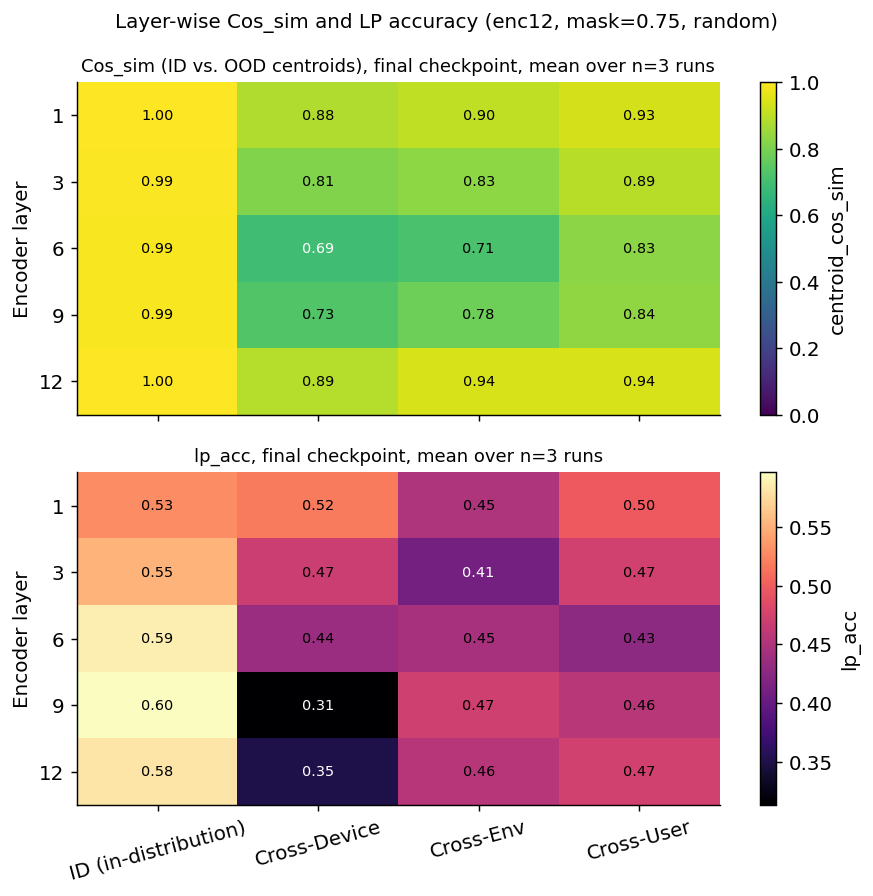

In [ ]:
# ----------------------------------------------------------------------
# Figure 3: Layer-wise Cos_sim (top) and accuracy (bottom)
# Aggregated over ALL HAR runs (mean across runs).
# ----------------------------------------------------------------------
# Rows: encoder layer (aligned by numeric id, e.g. 1, 3, 6, 9, 12).
# Cols: test split.
# Top panel: Cos_sim between ID and OOD class-conditional centroids.
# Bottom panel: a chosen accuracy metric (default LP acc), same layout,
# so you can see that direction alignment does not imply discriminability.
# ----------------------------------------------------------------------

def collect_layer_split_matrices(runs, cos_metric="cos_sim", acc_metric="lp_acc",
                                 split_order=("test_id", "test_cross_device",
                                              "test_cross_env", "test_cross_user")):
    layer_ids = set()
    for r in runs:
        for lk in get_layers(r):
            m = re.search(r"(\d+)", lk)
            if m:
                layer_ids.add(int(m.group(1)))
    layer_ids = sorted(layer_ids)
    n_layers = len(layer_ids)
    n_splits = len(split_order)

    cos_acc  = np.zeros((n_layers, n_splits))
    acc_acc  = np.zeros((n_layers, n_splits))
    n_cos    = np.zeros((n_layers, n_splits), dtype=int)   
    n_acc    = np.zeros((n_layers, n_splits), dtype=int)   
    for r in runs:
        ckpts = get_checkpoints(r)
        if not ckpts:
            continue
        final_ckpt = ckpts[-1]
        available = get_layers(r)

        for i, lid in enumerate(layer_ids):
            lk = align_layer_key(available, lid)
            if lk is None:
                continue
            for j, split in enumerate(split_order):
                v_cos = get_metric_safe(r, final_ckpt, lk, split, cos_metric)
                v_acc = get_metric_safe(r, final_ckpt, lk, split, acc_metric)
                if v_cos is not None:                       
                    cos_acc[i, j] += v_cos
                    n_cos[i, j] += 1
                if v_acc is not None:
                    acc_acc[i, j] += v_acc
                    n_acc[i, j] += 1

    with np.errstate(invalid="ignore", divide="ignore"):
        cos_mat = np.where(n_cos > 0, cos_acc / n_cos, np.nan)   
        acc_mat = np.where(n_acc > 0, acc_acc / n_acc, np.nan)

    return layer_ids, cos_mat, acc_mat, (n_cos, n_acc)  


def plot_layer_cos_sim_heatmap(runs, outdir, filename,
                               cos_metric="centroid_cos_sim",
                               acc_metric="lp_acc",
                               split_order=("test_id", "test_cross_device",
                                            "test_cross_env", "test_cross_user"),
                               title="Layer-wise Cos_sim and accuracy"):
    if not runs:
        print("[skip] plot_layer_cos_sim_heatmap: empty runs list.")
        return

    layer_ids, cos_mat, acc_mat, n_mat = collect_layer_split_matrices(
        runs, cos_metric=cos_metric, acc_metric=acc_metric, split_order=split_order,
    )
    if cos_mat.size == 0:
        print("[skip] plot_layer_cos_sim_heatmap: no data.")
        return

    fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

    # ----- Top panel: Cos_sim -----
    im0 = axes[0].imshow(cos_mat, aspect="auto", cmap="viridis", vmin=0.0, vmax=1.0)
    axes[0].set_yticks(range(len(layer_ids)))
    axes[0].set_yticklabels(layer_ids)
    axes[0].set_ylabel("Encoder layer")
    axes[0].set_title(
        f"Cos_sim (ID vs. OOD centroids), final checkpoint, mean over n={len(runs)} runs",
        fontsize=10,
    )
    for i in range(len(layer_ids)):
        for j in range(len(split_order)):
            if not np.isnan(cos_mat[i, j]):
                axes[0].text(
                    j, i, f"{cos_mat[i, j]:.2f}",
                    ha="center", va="center", fontsize=8,
                    color="white" if cos_mat[i, j] < 0.7 else "black",
                )
    fig.colorbar(im0, ax=axes[0], label="centroid_cos_sim")

    # ----- Bottom panel: accuracy -----
    im1 = axes[1].imshow(acc_mat, aspect="auto", cmap="magma")
    axes[1].set_xticks(range(len(split_order)))
    axes[1].set_xticklabels([SPLIT_LABELS.get(s, s) for s in split_order], rotation=15)
    axes[1].set_yticks(range(len(layer_ids)))
    axes[1].set_yticklabels(layer_ids)
    axes[1].set_ylabel("Encoder layer")
    axes[1].set_title(f"{acc_metric}, final checkpoint, mean over n={len(runs)} runs",
                      fontsize=10)
    for i in range(len(layer_ids)):
        for j in range(len(split_order)):
            if not np.isnan(acc_mat[i, j]):
                axes[1].text(
                    j, i, f"{acc_mat[i, j]:.2f}",
                    ha="center", va="center", fontsize=8,
                    color="white" if acc_mat[i, j] < np.nanmax(acc_mat) * 0.7 else "black",
                )
    fig.colorbar(im1, ax=axes[1], label=acc_metric)

    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")
    plt.show()


plot_layer_cos_sim_heatmap(
    CAPACITY_RESULTS,
    FIG_DIR,
    "layer_cos_sim_and_acc_heatmap.png",
    cos_metric="centroid_cos_sim",
    acc_metric="lp_acc",
    title="Layer-wise Cos_sim and LP accuracy (enc12, mask=0.75, random)",
)

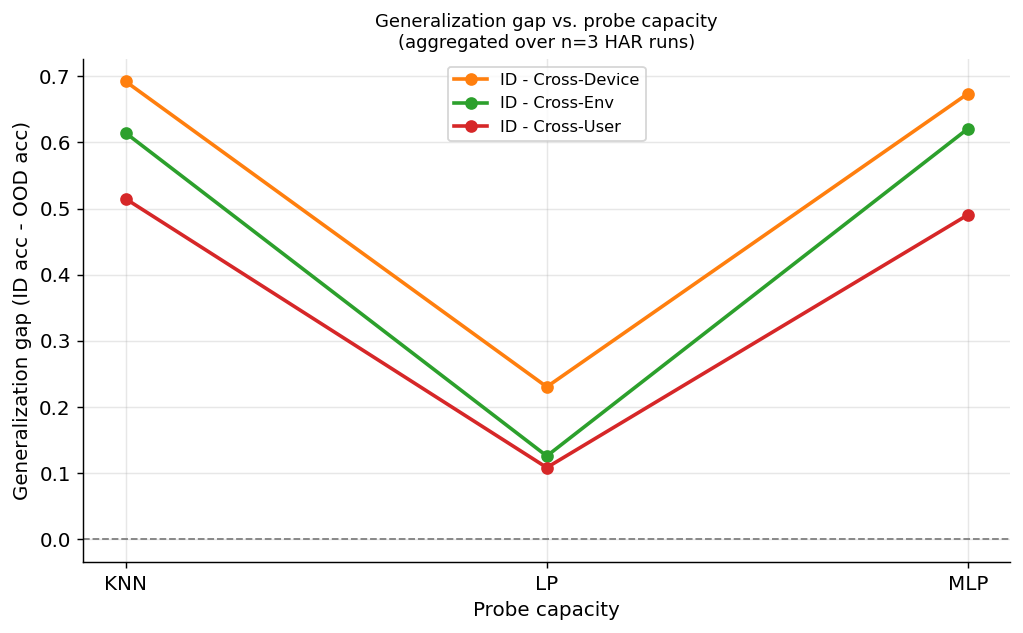

In [ ]:
def plot_capacity_generalization_gap(runs, outdir, filename,
                                      title="Generalization gap vs. probe capacity"):
    """ID accuracy minus each OOD split's accuracy, vs. probe capacity.
    Makes the capacity-generalization trade-off visually explicit rather
    than requiring the reader to mentally subtract two lines."""
    rows = collect_capacity_rows(runs)  # reuse the function from Figure 1
    if not rows:
        print("[skip] plot_capacity_generalization_gap: no probe metrics found.")
        return

    probe_labels = [p[0] for p in rows]
    x = np.arange(len(probe_labels))
    id_means = np.array([row[1]["test_id"][0] for row in rows])

    fig, ax = plt.subplots(figsize=(8, 5))
    for split in [s for s in TEST_SPLITS if s != "test_id"]:
        ood_means = np.array([row[1][split][0] for row in rows])
        gap = id_means - ood_means
        ax.plot(x, gap, marker="o", linewidth=2,
                label=f"ID - {SPLIT_LABELS.get(split, split)}",
                color=PROBE_COLORS.get(split))

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(probe_labels)
    ax.set_xlabel("Probe capacity")
    ax.set_ylabel("Generalization gap (ID acc - OOD acc)")
    ax.set_title(title + f"\n(aggregated over n={len(runs)} HAR runs)", fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")
    plt.show()


plot_capacity_generalization_gap(
    CAPACITY_RESULTS, FIG_DIR, "capacity_generalization_gap.png",
)

## Notes / caveats

- **Sample size (n) matters.** Every bar chart / table shows `n` per group in the legend or row
  label. If a group shows `n=1` where you expect `n=2` (missing seed), or `n=3` where you expect
  `n=2` (a stray unseeded run got picked up by the filter), treat that group's numbers as
  provisional -- re-check `RATIO_FILTERS` / `STRATEGY_FILTERS` and the underlying files before
  drawing conclusions.
- **`DEBUG=True`** in either config cell prints a per-file `[match]` / `[skip: reason]` line, which
  is the fastest way to find out why a file was excluded (wrong `mask_ratio`, missing `patch_h`,
  wrong `encoder_depth`, etc.).
- The **enc12 layer-probing job (Section A)** may still be running -- ratios/seeds with fewer
  runs than expected likely just haven't finished yet, not necessarily a data problem.